# AI Destekli Fraud & Anomali Tespiti: Case Çalışması

**Veri seti:** IEEE-CIS Fraud Detection (Kaggle). Kullanılan dosyalar `train_transaction.csv` ve `train_identity.csv`

# ADIM 1: Veri Yükleme ve Hazırlık

In [ ]:
import re, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

# >>> CSV dosyalarının bulunduğu klasör <<<
DATA_DIR = Path("data/raw")
OUT_DIR = Path("artifacts"); OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET, KEY, TIME = "isFraud", "TransactionID", "TransactionDT"

BLUE, ORANGE, INK, INK2 = "#2a78d6", "#eb6834", "black", "gray"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True})

## 1.1 Veri yükleme ve birleştirme

**Yaklaşım:**
- Birleştirme **left join** ile yapılıyor. Böylece tüm işlemler korunuyor; identity bilgisi yalnızca eşleşen satırlarda dolu oluyor. Inner join kullanılsaydı işlemlerin yaklaşık %76'sı kaybolurdu.
- Birleştirmeden önce anahtarın tekilliği kontrol ediliyor. Birleştirme `validate="one_to_one"` ile güvenceye alınıyor.
- `has_identity` bayrağı ekleniyor, çünkü identity kaydının varlığı başlı başına bir kriter.
- Tipler küçültülüyor: float64 → float32, int64 → int8/16/32, object → category. Bu sayede bellek kullanımı yaklaşık yarıya iniyor.

In [2]:
tx  = pd.read_csv(DATA_DIR / "train_transaction.csv")
idn = pd.read_csv(DATA_DIR / "train_identity.csv")

key_checks = pd.Series({
    "transaction satır × kolon": f"{tx.shape[0]:,} × {tx.shape[1]}",
    "identity satır × kolon": f"{idn.shape[0]:,} × {idn.shape[1]}",
    "transaction TransactionID tekil mi": tx[KEY].is_unique,
    "identity TransactionID tekil mi": idn[KEY].is_unique,
    "transaction'da karşılığı olmayan identity kaydı": int((~idn[KEY].isin(tx[KEY])).sum()),
    "identity bilgisi olan işlem oranı (%)": round(tx[KEY].isin(idn[KEY]).mean() * 100, 2),
}, name="değer")
display(key_checks.to_frame())

,değer
transaction satır × kolon,"590,540 × 394"
identity satır × kolon,"144,233 × 41"
transaction TransactionID tekil mi,True
identity TransactionID tekil mi,True
transaction'da karşılığı olmayan identity kaydı,0
identity bilgisi olan işlem oranı (%),24.42


In [3]:
def optimize_dtypes(df):
    for c in df.columns:
        s = df[c]
        if s.dtype == "float64":
            df[c] = s.astype("float32")
        elif s.dtype == "int64" and c not in (KEY, TIME):
            df[c] = pd.to_numeric(s, downcast="integer")
        elif s.dtype == "object":
            df[c] = s.astype("category")
    return df

df = tx.merge(idn, on=KEY, how="left", validate="one_to_one")
df["has_identity"] = df[KEY].isin(idn[KEY]).astype("int8")
mem_before = df.memory_usage(deep=True).sum() / 1e9
df = optimize_dtypes(df)
mem_after = df.memory_usage(deep=True).sum() / 1e9
del tx, idn

print(f"Birleşik veri: {df.shape[0]:,} satır × {df.shape[1]} kolon")
print(f"Bellek: {mem_before:.2f} GB → {mem_after:.2f} GB")
display(df[TARGET].value_counts().rename_axis("isFraud").to_frame("adet")
        .assign(oran_pct=lambda t: (t["adet"] / t["adet"].sum() * 100).round(2)))
display(df.head())

Birleşik veri: 590,540 satır × 435 kolon
Bellek: 2.69 GB → 0.97 GB


,adet,oran_pct
isFraud,,
0,569877,96.5
1,20663,3.5


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,...,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,has_identity
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M,1


**Bulgular: Birleştirme**
- `TransactionID` her iki tabloda da tekil. Identity tablosundaki her kaydın transaction tablosunda karşılığı var, birleştirme bire bir.
- İşlemlerin yalnızca **%24,4'ünde** identity bilgisi var. Bu bilgi `has_identity` bayrağı olarak tutuldu.
- Sonuç tablo **590.540 × 435** (434 orijinal kolon ve `has_identity`). Tipler küçültüldükten sonra bellekte yaklaşık 1,1 GB yer tutuyor.
- Hedef değişkende **20.663 fraud var (%3,50)**. Sınıflar ciddi dengesiz; bu yüzden ileride accuracy yerine ROC-AUC ve PR-AUC kullanılmalı.

## 1.2 Eksik veri analizi

Eksik veri dört açıdan inceleniyor:
1. Kolon bazında eksik oranı
2. Kolon grubu bazında eksik oranı (card, addr, C, D, M, V, identity …)
3. **Eksiklik blokları:** aynı satırlarda birlikte eksik olan kolonlar
4. **Eksikliğin fraud ile ilişkisi:** kolon eksikken ve doluyken fraud oranı

In [4]:
def feature_group(col):
    if col in (KEY, TARGET, TIME, "TransactionAmt", "ProductCD", "has_identity"):
        return col
    if col.startswith("id_") or col.startswith("Device"):
        return "identity"
    m = re.match(r"^(card|addr|dist|C|D|M|V)\d+$", col)
    if m:
        return m.group(1)
    if col.endswith("emaildomain"):
        return "emaildomain"
    return "other"

miss_mask = df.isna()
y = df[TARGET].to_numpy()
miss = pd.DataFrame({
    "column": df.columns,
    "group": [feature_group(c) for c in df.columns],
    "missing_count": miss_mask.sum().values,
    "missing_pct": (miss_mask.mean() * 100).round(2).values,
})
miss["fraud_rate_if_missing"] = [round(y[m].mean() * 100, 2) if m.any() else np.nan
                                 for m in (miss_mask[c].to_numpy() for c in df.columns)]
miss["fraud_rate_if_present"] = [round(y[~m].mean() * 100, 2) if (~m).any() else np.nan
                                 for m in (miss_mask[c].to_numpy() for c in df.columns)]
miss["missing_band"] = pd.cut(miss.missing_pct, [-0.01, 0, 20, 50, 90, 100],
                              labels=["0%", "0-20%", "20-50%", "50-90%", "90-100%"])
miss = miss.sort_values("missing_pct", ascending=False).reset_index(drop=True)

print(f"Toplam hücre bazında eksik oranı : %{miss_mask.values.mean()*100:.2f}")
print(f"Hiç eksik değeri olmayan satır    : {(~miss_mask.any(axis=1)).sum()}")
print(f"Hiç eksik değeri olmayan kolon    : {(miss.missing_pct == 0).sum()} / {df.shape[1]}")
display(miss.missing_band.value_counts().reindex(["0%", "0-20%", "20-50%", "50-90%", "90-100%"])
        .rename_axis("eksik oranı").to_frame("kolon sayısı"))
print("En çok eksik olan 15 kolon:")
display(miss.head(15)[["column", "group", "missing_count", "missing_pct"]])

Toplam hücre bazında eksik oranı : %44.97
Hiç eksik değeri olmayan satır    : 0
Hiç eksik değeri olmayan kolon    : 53 / 435


,kolon sayısı
eksik oranı,
0%,53
0-20%,130
20-50%,38
50-90%,202
90-100%,12


En çok eksik olan 15 kolon:


,column,group,missing_count,missing_pct
0,id_24,identity,585793,99.20
1,id_07,identity,585385,99.13
2,id_26,identity,585377,99.13
3,id_21,identity,585381,99.13
4,id_25,identity,585408,99.13
5,id_08,identity,585385,99.13
6,id_22,identity,585371,99.12
7,id_27,identity,585371,99.12
8,id_23,identity,585371,99.12
9,dist2,dist,552913,93.63


,group,n_columns,mean_missing_pct,min_missing_pct,max_missing_pct
0,identity,40,84.48,75.58,99.20
1,dist,2,76.64,59.65,93.63
2,D,15,58.15,0.21,93.41
3,M,9,49.92,28.68,59.35
4,emaildomain,2,46.37,15.99,76.75
5,V,339,43.04,0.00,86.12
6,addr,2,11.13,11.13,11.13
7,card,6,0.51,0.00,1.51
8,C,14,0.00,0.00,0.00
9,ProductCD,1,0.00,0.00,0.00


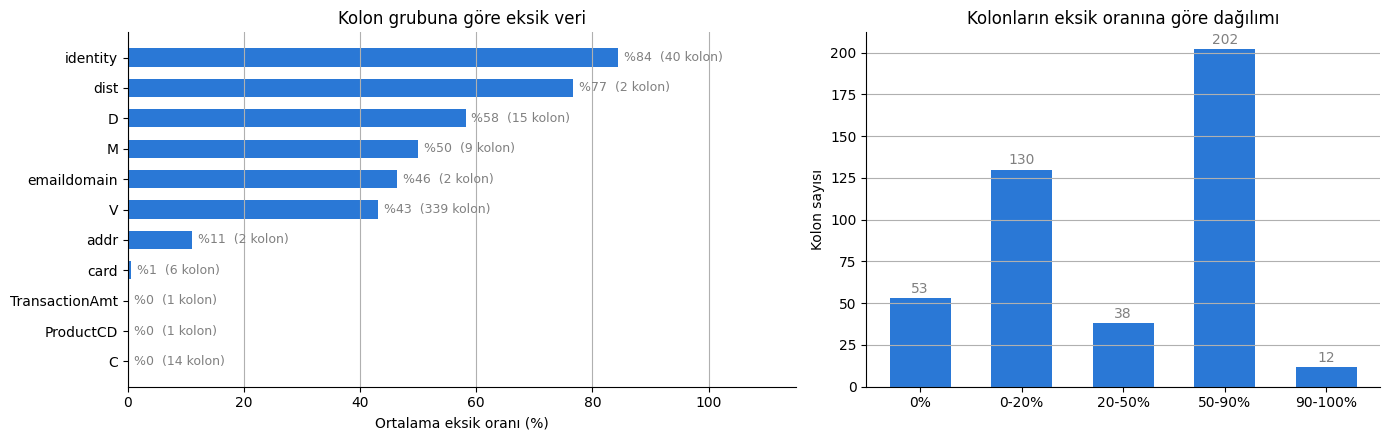

In [5]:
miss_grp = (miss.groupby("group")
            .agg(n_columns=("column", "count"), mean_missing_pct=("missing_pct", "mean"),
                 min_missing_pct=("missing_pct", "min"), max_missing_pct=("missing_pct", "max"))
            .round(2).sort_values("mean_missing_pct", ascending=False).reset_index())
display(miss_grp)

g = miss_grp[~miss_grp.group.isin([KEY, TARGET, TIME, "has_identity"])].sort_values("mean_missing_pct")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), gridspec_kw={"width_ratios": [1.3, 1]})
ax = axes[0]
ax.barh(g.group, g.mean_missing_pct, color=BLUE, height=.6)
for yy, v, n in zip(g.group, g.mean_missing_pct, g.n_columns):
    ax.text(v + 1, yy, f"%{v:.0f}  ({n} kolon)", va="center", color=INK2, fontsize=9)
ax.set_xlim(0, 115); ax.set_xlabel("Ortalama eksik oranı (%)"); ax.grid(axis="y", visible=False)
ax.set_title("Kolon grubuna göre eksik veri")

band = miss.missing_band.value_counts().reindex(["0%", "0-20%", "20-50%", "50-90%", "90-100%"])
ax = axes[1]
ax.bar(band.index, band.values, color=BLUE, width=.6)
for x, v in zip(band.index, band.values):
    ax.text(x, v + 3, str(v), ha="center", color=INK2)
ax.set_ylabel("Kolon sayısı"); ax.grid(axis="x", visible=False)
ax.set_title("Kolonların eksik oranına göre dağılımı")
plt.tight_layout(); plt.show()

**Bulgular: Eksik veri seviyesi**
- Tüm hücrelerin **%45'i eksik** ve **hiçbir satır tam dolu değil**. Bu yüzden satır silmek bir seçenek değil.
- Kolonların eksik oranına göre dağılımı: 0% → 53, 0–20% → 130, 20–50% → 38, **50–90% → 202**, 90–100% → 12.
- Grup bazında ortalama eksik oranı: **identity %84**, dist %77, D %58, M %50, emaildomain %46, V %43, addr %11, card %1. C, TransactionAmt ve ProductCD tam dolu.
- identity grubunun eksikliği yapısal: işlemlerin %76'sında identity kaydı hiç yok. Bu eksiklik "rastgele" değil, sistematik.

In [6]:
# Eksiklik blokları: eksiklik maskesi birebir aynı olan kolonları grupla
mm = miss_mask.loc[:, miss_mask.any()]
blocks = {}
for c in mm.columns:
    blocks.setdefault(np.packbits(mm[c].to_numpy()).tobytes(), []).append(c)
patterns = pd.DataFrame([
    dict(n_columns=len(cols), missing_pct=round(mm[cols[0]].mean() * 100, 2),
         columns=", ".join(cols if len(cols) <= 10 else cols[:5] + ["..."] + cols[-3:]))
    for cols in sorted(blocks.values(), key=len, reverse=True) if len(cols) >= 2
])
print(f"En az 2 kolondan oluşan eksiklik bloğu sayısı: {len(patterns)}")
print(f"Bu bloklarda yer alan toplam kolon sayısı     : {patterns.n_columns.sum()}")
display(patterns.head(15))

En az 2 kolondan oluşan eksiklik bloğu sayısı: 26
Bu bloklarda yer alan toplam kolon sayısı     : 371


,n_columns,missing_pct,columns
0,46,77.91,"V217, V218, V219, V223, V224, ..., V276, V277, V278"
1,43,0.05,"V95, V96, V97, V98, V99, ..., V135, V136, V137"
2,32,0.00,"V279, V280, V284, V285, V286, ..., V319, V320, V321"
3,31,76.36,"V167, V168, V172, V173, V176, ..., V214, V215, V216"
4,23,12.88,"V12, V13, V14, V15, V16, ..., V32, V33, V34"
5,22,13.06,"V53, V54, V55, V56, V57, ..., V72, V73, V74"
6,20,15.10,"V75, V76, V77, V78, V79, ..., V92, V93, V94"
7,19,76.32,"V169, V170, V171, V174, V175, ..., V208, V209, V210"
8,18,28.61,"V35, V36, V37, V38, V39, ..., V50, V51, V52"
9,18,86.12,"V138, V139, V140, V141, V142, ..., V161, V162, V163"


**Bulgular: Eksiklik blokları**
- Kolonlar **26 blok** hâlinde, birebir aynı satırlarda eksik. Örneğin V217–V278 arasındaki 46 kolon her zaman birlikte eksik (%77,9). V95–V137 arasındaki 43 kolon ise neredeyse hiç eksik değil.
- Bu yapı, V kolonlarının farklı veri kaynaklarından ya da farklı işlem tiplerinden geldiğini gösteriyor.
- **Sonuç:** Her blok için tek bir "eksik mi" göstergesi yeterli. Ayrıca bloklar Adım 2'de boyut indirgeme (PCA veya bloktan temsilci kolon seçimi) için doğal birer gruplama sunuyor.

,column,missing_pct,fraud_rate_if_missing,fraud_rate_if_present,diff_pts
0,addr2,11.13,11.78,2.46,9.32
1,addr1,11.13,11.78,2.46,9.32
2,M6,28.68,7.07,2.06,5.01
3,M1,45.91,5.28,1.99,3.29
4,M3,45.91,5.28,1.99,3.29
5,M2,45.91,5.28,1.99,3.29
6,D11,47.29,5.21,1.96,3.25
7,V1,47.29,5.21,1.96,3.25
8,D13,89.51,2.62,11.04,-8.42
9,D14,89.47,2.55,11.60,-9.05


Identity kaydı var mı? → fraud oranı (%)


,n,fraud_rate
has_identity,,
0,446307,2.09
1,144233,7.85


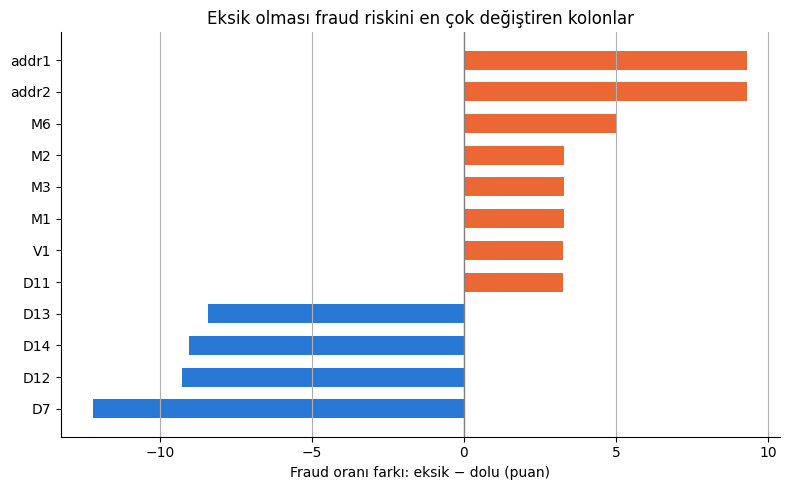

In [7]:
m = miss[(miss.missing_pct > 1) & (miss.missing_pct < 99)].copy()
m["diff_pts"] = m.fraud_rate_if_missing - m.fraud_rate_if_present
top = pd.concat([m.nlargest(8, "diff_pts"), m.nsmallest(4, "diff_pts")]).sort_values("diff_pts")
display(top[["column", "missing_pct", "fraud_rate_if_missing", "fraud_rate_if_present", "diff_pts"]]
        .sort_values("diff_pts", ascending=False).reset_index(drop=True))

hi = df.groupby("has_identity")[TARGET].agg(n="count", fraud_rate="mean")
hi["fraud_rate"] = (hi.fraud_rate * 100).round(2)
print("Identity kaydı var mı? → fraud oranı (%)"); display(hi)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top.column, top.diff_pts, color=[ORANGE if v > 0 else BLUE for v in top.diff_pts], height=.6)
ax.axvline(0, color=INK2, linewidth=1); ax.grid(axis="y", visible=False)
ax.set_xlabel("Fraud oranı farkı: eksik − dolu (puan)")
ax.set_title("Eksik olması fraud riskini en çok değiştiren kolonlar")
plt.tight_layout(); plt.show()

**Bulgular: Eksiklik bilgi taşıyor**
- `addr1/addr2` eksikse fraud oranı **%11,8**, doluysa **%2,5**. Yani adresin eksik olması riski yaklaşık 5 kat artırıyor.
- `D7`'de durum tersine: eksikse fraud oranı **%2,7**, doluysa **%14,9**. D12 ve D14'te de benzer bir tablo var.
- Identity kaydı olan işlemlerde fraud oranı **%7,8**, olmayanlarda **%2,1**.
- **Sonuç:** Eksik değerleri doldurmadan (impute) önce ilgili kolonlar ya da bloklar için **missing indicator** özellikleri eklenmeli; aksi hâlde güçlü bir sinyal kaybolur. LightGBM ve XGBoost gibi ağaç modelleri NaN değerlerle doğrudan çalışabiliyor. Isolation Forest gibi anomali modelleri ise doldurma gerektiriyor.

## 1.3 Kolon tiplerinin otomatik belirlenmesi

Tip belirleme **iki aşamalı**:

1. **Veriden otomatik çıkarım:** dtype, tekil değer sayısı, tam sayı olup olmama ve monotonluk kontrol edilerek her kolon aşağıdaki tiplerden birine atanıyor:

   | Tip | Kural |
   |---|---|
   | constant | 1 veya daha az tekil değer |
   | identifier | Her satırda tekil, tam sayı |
   | timestamp | Monoton artan, satırların yarısından fazlasında tekil |
   | binary | 2 tekil değer |
   | categorical | Metin veya category dtype |
   | numeric_discrete | Tam sayı, 20 veya daha az tekil değer |
   | numeric_integer | Tam sayı, çok sayıda tekil değer |
   | numeric_continuous | Ondalıklı |

2. **Domain düzeltmesi:** Kaggle dokümantasyonunda kategorik olarak tanımlanan ama sayıyla kodlanmış alanlar (card1-6, addr1-2, id_12-38) kategorik olarak işaretleniyor. Örneğin `card1` tam sayı görünüyor ama bir kart kodu; büyüklük karşılaştırması anlamsız.

In [8]:
DOMAIN_CATEGORICAL = (["ProductCD", "addr1", "addr2", "P_emaildomain", "R_emaildomain", "DeviceType", "DeviceInfo"]
                      + [f"card{i}" for i in range(1, 7)] + [f"M{i}" for i in range(1, 10)]
                      + [f"id_{i}" for i in range(12, 39)])

def infer_column_types(df, discrete_max=20):
    rows, n = [], len(df)
    for c in df.columns:
        s = df[c]; nn = s.dropna(); nunique = int(nn.nunique())
        is_num = pd.api.types.is_numeric_dtype(s)
        int_like = bool(is_num and len(nn) and np.all(np.mod(nn.to_numpy(dtype="float64"), 1) == 0))
        if nunique <= 1:                     auto, reason = "constant", "<=1 tekil değer"
        elif c == KEY or (nunique == n and int_like): auto, reason = "identifier", "her satırda tekil"
        elif c == TIME or (int_like and nn.is_monotonic_increasing and nunique > .5 * n):
                                             auto, reason = "timestamp", "monoton artan, yüksek tekillik"
        elif nunique == 2:                   auto, reason = "binary", "2 tekil değer"
        elif not is_num:                     auto, reason = "categorical", "metin/kategori dtype"
        elif int_like and nunique <= discrete_max: auto, reason = "numeric_discrete", f"tam sayı, <= {discrete_max} tekil"
        elif int_like:                       auto, reason = "numeric_integer", "tam sayı, çok tekil değer"
        else:                                auto, reason = "numeric_continuous", "ondalıklı"
        final = auto
        if c == TARGET:
            final, reason = "target", "hedef değişken"
        elif c in DOMAIN_CATEGORICAL and auto != "constant":
            if auto != "categorical":
                reason += " → domain: kategorik kod"
            final = "binary" if auto == "binary" else "categorical"
        rows.append(dict(column=c, group=feature_group(c), dtype=str(s.dtype), auto_type=auto,
                         final_type=final, n_unique=nunique, reason=reason))
    return pd.DataFrame(rows)

types = infer_column_types(df)
display(types.final_type.value_counts().rename_axis("final_type").to_frame("kolon sayısı"))
print("Grup × tip dağılımı:")
display(pd.crosstab(types.group, types.final_type))

,kolon sayısı
final_type,
numeric_integer,163
numeric_discrete,132
numeric_continuous,80
categorical,31
binary,26
identifier,1
target,1
timestamp,1


Grup × tip dağılımı:


final_type,binary,categorical,identifier,numeric_continuous,numeric_discrete,numeric_integer,target,timestamp
group,,,,,,,,
C,0,0,0,0,0,14,0,0
D,0,0,0,2,0,13,0,0
M,8,1,0,0,0,0,0,0
ProductCD,0,1,0,0,0,0,0,0
TransactionAmt,0,0,0,1,0,0,0,0
TransactionDT,0,0,0,0,0,0,0,1
TransactionID,0,0,1,0,0,0,0,0
V,7,0,0,76,131,125,0,0
addr,0,2,0,0,0,0,0,0


Domain bilgisiyle düzeltilen kolon sayısı: 18


,column,dtype,auto_type,final_type,n_unique,reason
0,card1,int16,numeric_integer,categorical,13553,"tam sayı, çok tekil değer → domain: kategorik kod"
1,card2,float32,numeric_integer,categorical,500,"tam sayı, çok tekil değer → domain: kategorik kod"
2,card3,float32,numeric_integer,categorical,114,"tam sayı, çok tekil değer → domain: kategorik kod"
3,card5,float32,numeric_integer,categorical,119,"tam sayı, çok tekil değer → domain: kategorik kod"
4,addr1,float32,numeric_integer,categorical,332,"tam sayı, çok tekil değer → domain: kategorik kod"
5,addr2,float32,numeric_integer,categorical,74,"tam sayı, çok tekil değer → domain: kategorik kod"
6,id_13,float32,numeric_integer,categorical,54,"tam sayı, çok tekil değer → domain: kategorik kod"
7,id_14,float32,numeric_integer,categorical,25,"tam sayı, çok tekil değer → domain: kategorik kod"
8,id_17,float32,numeric_integer,categorical,104,"tam sayı, çok tekil değer → domain: kategorik kod"
9,id_18,float32,numeric_discrete,categorical,18,"tam sayı, <= 20 tekil → domain: kategorik kod"


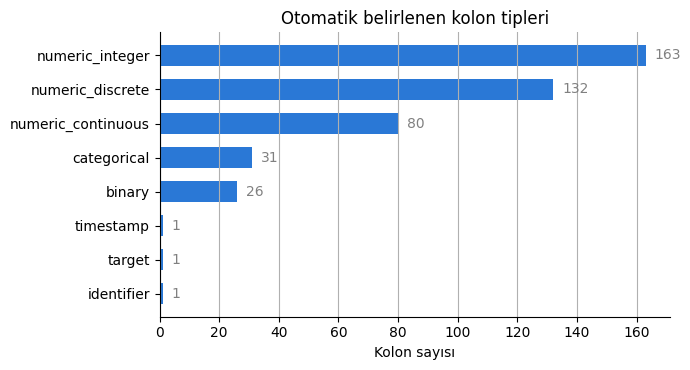

In [9]:
changed = types[(types.auto_type != types.final_type) & (types.column != TARGET)]
print(f"Domain bilgisiyle düzeltilen kolon sayısı: {len(changed)}")
display(changed[["column", "dtype", "auto_type", "final_type", "n_unique", "reason"]].reset_index(drop=True))

t = types.final_type.value_counts().sort_values()
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.barh(t.index, t.values, color=BLUE, height=.6)
for yy, v in zip(t.index, t.values):
    ax.text(v + 3, yy, str(v), va="center", color=INK2)
ax.set_xlabel("Kolon sayısı"); ax.grid(axis="y", visible=False)
ax.set_title("Otomatik belirlenen kolon tipleri")
plt.tight_layout(); plt.show()

**Bulgular: Kolon tipleri**
- Nihai dağılım: numeric_integer 163, numeric_discrete 132, numeric_continuous 80, **categorical 31**, binary 26, identifier / timestamp / target 1'er.
- Domain düzeltmesi **18 kolonu** etkiledi: card1-3, card5, addr1-2 ve 12 identity kolonu. Bu kolonlar sayısal model girdisi gibi değil, kategori olarak işlenmeli.
- M kolonlarının çoğu ve 7 V kolonu binary. C kolonlarının tamamı tam sayı; isimlerinden de anlaşıldığı gibi sayaç niteliğindeler.
- `TransactionDT` mutlak bir tarih değil, bir referans noktasından itibaren geçen saniye. Bu nedenle ondan **gün ve saat** türetilebilir.

## 1.4 Veri kalitesi analizi

Kontroller:
- **Tekillik:** tekrarlayan ID'ler ve tekrarlayan satırlar
- **Geçerlilik:** tutar sıfır veya negatif mi, aykırı tutarlar var mı, gün farklarında negatif değer var mı, kod alanlarında negatif değer var mı
- **Bilgi içeriği:** sabit veya yarı sabit kolonlar, birebir aynı içeriğe sahip kolonlar
- **Tutarlılık:** kategorilerde harf ya da boşluk farkı, sürüm numarası gömülü değerler
- **Zaman bütünlüğü:** kayıtların sırası, boş gün olup olmadığı, günlük hacim
- **Kolon kalite skoru:** tamlık × (1 − sorun cezası)

In [10]:
feats = [c for c in df.columns if c not in (KEY, TARGET, TIME, "has_identity")]
quality = {
    "Tekrarlayan TransactionID": int(df[KEY].duplicated().sum()),
    "ID hariç tamamen aynı satır": int(df.drop(columns=[KEY]).duplicated().sum()),
    "TransactionAmt <= 0": int((df.TransactionAmt <= 0).sum()),
    "TransactionAmt > 10.000 $": int((df.TransactionAmt > 10_000).sum()),
}
display(pd.Series(quality, name="adet").to_frame())

issues = []
for c in feats:
    s = df[c].dropna()
    if s.empty:
        issues.append((c, "all_missing", "Tamamen boş")); continue
    top = s.value_counts(normalize=True).iloc[0]
    if s.nunique() <= 1:
        issues.append((c, "constant", "Tek değer"))
    elif top >= 0.99:
        issues.append((c, "quasi_constant", f"En sık değerin payı (dolu satırlarda): %{top*100:.1f}"))

# birebir aynı kolonlar (hash ile ön eleme + equals ile doğrulama)
seen = {}
for c in feats:
    h = pd.util.hash_pandas_object(df[c], index=False).sum()
    if h in seen and df[c].equals(df[seen[h]]):
        issues.append((c, "duplicate_column", f"{seen[h]} ile birebir aynı"))
    else:
        seen.setdefault(h, c)

for c in [c for c in df.columns if re.fullmatch(r"D\d+", c)]:
    k = int((df[c] < 0).sum())
    if k:
        issues.append((c, "negative_values", f"{k} negatif değer (gün farkı için beklenmez)"))
for c in ["card1", "card2", "card3", "card5", "addr1", "addr2"]:
    if (df[c] < 0).any():
        issues.append((c, "negative_values", "Kod alanında negatif değer"))

for c in types.query("final_type=='categorical' and dtype=='category'").column:
    vals = pd.Series(df[c].dropna().unique()).astype(str)
    k = int(len(vals) - vals.str.lower().str.strip().str.replace(r"\s+", " ", regex=True).nunique())
    if k:
        issues.append((c, "inconsistent_text", f"{k} değer yalnızca harf/boşluk farkıyla tekrarlanıyor"))
for c in ["id_30", "id_31", "DeviceInfo"]:
    v = df[c].dropna().astype(str)
    issues.append((c, "embedded_version",
                   f"Sürüm/model numarası içeren değer oranı: %{v.str.contains(r'[0-9]').mean()*100:.0f} → marka/aile çıkarılmalı"))

issues = pd.DataFrame(issues, columns=["column", "issue", "detail"])
display(issues.issue.value_counts().rename_axis("sorun").to_frame("kolon sayısı"))
display(issues)

,adet
Tekrarlayan TransactionID,0
ID hariç tamamen aynı satır,3
TransactionAmt <= 0,0
TransactionAmt > 10.000 $,2


,kolon sayısı
sorun,
quasi_constant,30
negative_values,6
embedded_version,3
inconsistent_text,1


,column,issue,detail
0,addr2,quasi_constant,En sık değerin payı (dolu satırlarda): %99.2
1,C3,quasi_constant,En sık değerin payı (dolu satırlarda): %99.6
2,M1,quasi_constant,En sık değerin payı (dolu satırlarda): %100.0
3,V1,quasi_constant,En sık değerin payı (dolu satırlarda): %100.0
4,V14,quasi_constant,En sık değerin payı (dolu satırlarda): %100.0
5,V27,quasi_constant,En sık değerin payı (dolu satırlarda): %99.9
6,V28,quasi_constant,En sık değerin payı (dolu satırlarda): %99.9
7,V41,quasi_constant,En sık değerin payı (dolu satırlarda): %99.9
8,V65,quasi_constant,En sık değerin payı (dolu satırlarda): %100.0
9,V68,quasi_constant,En sık değerin payı (dolu satırlarda): %99.9


id_30 örnek değerler: ['Windows 10', 'Windows 7', 'iOS 11.2.1', 'iOS 11.1.2', 'Android 7.0', 'Mac OS X 10_12_6', 'Mac OS X 10_11_6', 'iOS 11.3.0']
id_31 örnek değerler: ['chrome 63.0', 'mobile safari 11.0', 'mobile safari generic', 'ie 11.0 for desktop', 'safari generic', 'chrome 62.0', 'chrome 65.0', 'chrome 64.0']
DeviceInfo örnek değerler: ['Windows', 'iOS Device', 'MacOS', 'Trident/7.0', 'rv:11.0', 'rv:57.0', 'SM-J700M Build/MMB29K', 'SM-G610M Build/MMB29K']

Kayıtlar zamana göre sıralı mı : True
Kapsanan gün sayısı            : 182
İşlem olmayan gün sayısı       : 0
Günlük işlem sayısı (min / max): 2,048 / 6,852


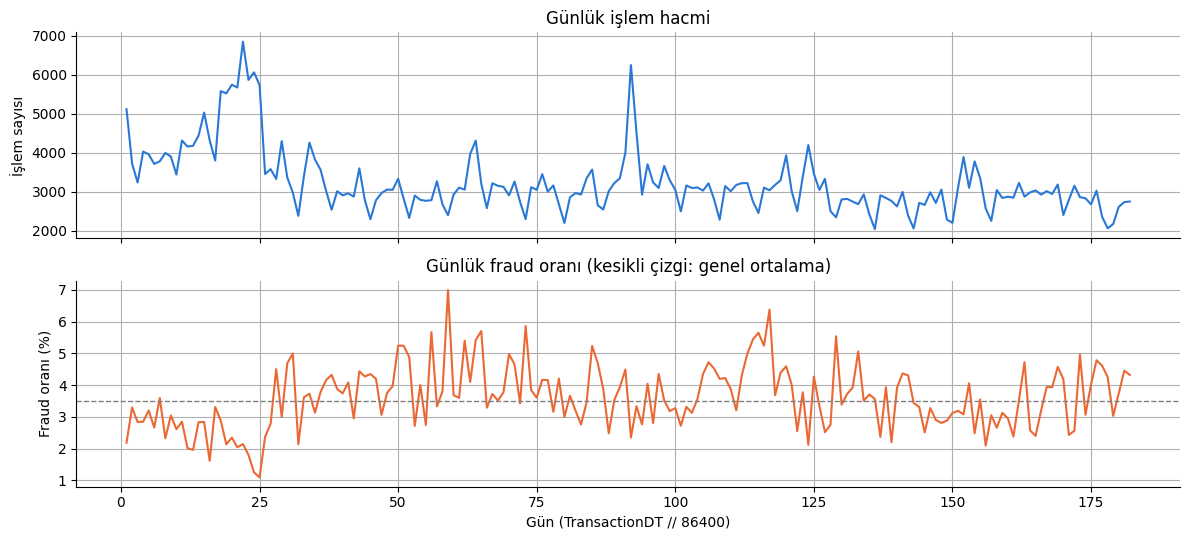

In [11]:
for c in ["id_30", "id_31", "DeviceInfo"]:
    print(f"{c} örnek değerler:", df[c].value_counts().head(8).index.tolist())

day = (df[TIME] // 86400).astype(int)
daily = day.value_counts().sort_index()
print(f"\nKayıtlar zamana göre sıralı mı : {df[TIME].is_monotonic_increasing}")
print(f"Kapsanan gün sayısı            : {daily.index.max() - daily.index.min() + 1}")
print(f"İşlem olmayan gün sayısı       : {daily.index.max() - daily.index.min() + 1 - len(daily)}")
print(f"Günlük işlem sayısı (min / max): {daily.min():,} / {daily.max():,}")

daily_fr = df.groupby(day)[TARGET].mean() * 100
fig, axes = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True)
axes[0].plot(daily.index, daily.values, color=BLUE, linewidth=1.5)
axes[0].set_ylabel("İşlem sayısı"); axes[0].set_title("Günlük işlem hacmi")
axes[1].plot(daily_fr.index, daily_fr.values, color=ORANGE, linewidth=1.5)
axes[1].axhline(df[TARGET].mean() * 100, color=INK2, linestyle="--", linewidth=1)
axes[1].set_ylabel("Fraud oranı (%)"); axes[1].set_xlabel("Gün (TransactionDT // 86400)")
axes[1].set_title("Günlük fraud oranı (kesikli çizgi: genel ortalama)")
plt.tight_layout(); plt.show()

In [12]:
pen = issues.groupby("column").issue.apply(lambda s: min(0.5, 0.25 * len(s)))
completeness = 1 - df[feats].isna().mean()
col_score = (completeness * (1 - pen.reindex(feats).fillna(0))).round(3).rename("quality_score")
print(f"Ortalama kolon kalite skoru : {col_score.mean():.3f}")
print(f"Skoru 0,5'in altındaki kolon: {(col_score < .5).sum()} / {len(col_score)}")
display(col_score.groupby([feature_group(c) for c in col_score.index]).mean().round(3)
        .sort_values().rename_axis("group").to_frame("ortalama kalite skoru"))

Ortalama kolon kalite skoru : 0.530
Skoru 0,5'in altındaki kolon: 217 / 431


,ortalama kalite skoru
group,
identity,0.150
dist,0.234
D,0.378
M,0.486
emaildomain,0.536
V,0.554
addr,0.778
C,0.982
card,0.995


**Bulgular: Veri kalitesi**

| Kontrol | Sonuç |
|---|---|
| Tekrarlayan TransactionID | 0 |
| ID hariç tamamen aynı satır | 3 (önemsiz) |
| TransactionAmt ≤ 0 | 0. 10.000 $ üzeri 2 aykırı işlem var |
| Zaman sırası / kapsam | Kayıtlar sıralı; **182 gün**, boş gün yok, günde 2.048–6.852 işlem |
| Yarı sabit kolon (dolu değerlerin %99'undan fazlası aynı) | **30 kolon**: V1, V14, V107, M1, id_04, id_27 vb. Elenmeye aday |
| Negatif gün farkı | D4, D6, D11, D12, D14, D15 kolonlarında 2–15 kayıt. Hata ya da offset olabilir; 0'a kırpılmalı |
| Harf/boşluk tutarsızlığı | Bulunmadı |
| Sürüm gömülü kategoriler | id_30 (`Windows 10`), id_31 (`chrome 63.0`), DeviceInfo. **Marka ve aile** ayrı çıkarılmalı |

- Ortalama kolon kalite skoru **0,53**; 217 kolonun skoru 0,5'in altında. Skoru düşüren ana etken eksik veri.
- **Zamansal örüntü:** İlk yaklaşık 25 günde işlem hacmi belirgin şekilde yüksek (günde 4.000–6.850), fraud oranı ise ortalamanın altında (%1–3,5). Bu dönem muhtemelen bir tatil ya da kampanya dönemi. Sonrasında fraud oranı %2–7 arasında dalgalanıyor. Bu **drift** nedeniyle model **zamana göre** doğrulanmalı; rastgele bölme, gerçekçi olmayan derecede iyimser sonuç verir.

## 1.5 Kolon dağılımları

- **Sayısal kolonlar:** merkezi eğilim, yüzdelikler, çarpıklık (skew), basıklık (kurtosis), sıfır oranı, IQR yöntemine göre aykırı değer oranı, fraud ve normal işlemlerde medyan
- **Kategorik kolonlar:** en sık değer ve payı, entropi, nadir değer sayısı, kategoriye göre fraud oranı

In [13]:
num_cols = types[types.final_type.str.startswith("numeric")].column
rows = []
for c in num_cols:
    s = df[c].dropna().astype("float64")
    if s.empty: continue
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    out = ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).mean() if iqr > 0 else 0.0
    sub = df.loc[df[c].notna(), [c, TARGET]]
    rows.append(dict(column=c, group=feature_group(c), count=len(s), mean=s.mean(), std=s.std(),
                     min=s.min(), p25=q1, median=s.median(), p75=q3, p99=s.quantile(.99), max=s.max(),
                     zero_pct=(s == 0).mean() * 100, skew=s.skew(), kurtosis=s.kurt(),
                     iqr_outlier_pct=out * 100,
                     median_legit=sub.loc[sub[TARGET] == 0, c].median(),
                     median_fraud=sub.loc[sub[TARGET] == 1, c].median()))
num_dist = pd.DataFrame(rows).round(3)

print(f"|skew| > 5 olan sayısal kolon: {(num_dist['skew'].abs() > 5).sum()} / {len(num_dist)}")
print("Seçili kolonlar:")
display(num_dist[num_dist.column.isin(["TransactionAmt", "dist1", "C1", "C13", "D1", "D15"])]
        .set_index("column")[["median", "p99", "max", "skew", "iqr_outlier_pct", "median_legit", "median_fraud"]])

nd = num_dist.dropna(subset=["median_legit", "median_fraud"]).copy()
nd["median_diff_ratio"] = (nd.median_fraud - nd.median_legit).abs() / (nd[["median_fraud", "median_legit"]].abs().max(axis=1) + 1e-9)
print("Fraud ve normal işlemlerde medyanı en çok farklılaşan sayısal kolonlar (C ve D grupları):")
display(nd[nd.group.isin(["C", "D", "dist"])].sort_values("median_diff_ratio", ascending=False)
        .head(10)[["column", "median_legit", "median_fraud", "count"]].reset_index(drop=True))

|skew| > 5 olan sayısal kolon: 271 / 375
Seçili kolonlar:


,median,p99,max,skew,iqr_outlier_pct,median_legit,median_fraud
column,,,,,,,
TransactionAmt,68.769,1104.0,31937.391,14.374,11.258,68.5,75.0
dist1,8.000,2040.0,10286.000,5.108,16.780,8.0,10.0
C1,1.000,164.0,4685.000,23.958,10.081,1.0,2.0
C13,3.000,578.0,2918.000,8.986,12.807,3.0,1.0
D1,3.000,602.0,640.000,1.805,12.589,4.0,0.0
D15,52.000,635.0,879.000,0.957,0.026,56.0,1.0


Fraud ve normal işlemlerde medyanı en çok farklılaşan sayısal kolonlar (C ve D grupları):


,column,median_legit,median_fraud,count
0,C8,0.000,1.000,590540
1,D5,10.000,0.000,280699
2,D1,4.000,0.000,589271
3,C10,0.000,1.000,590540
4,C9,1.000,0.000,590540
5,C4,0.000,1.000,590540
6,D10,18.000,0.000,514518
7,D15,56.000,1.000,501427
8,D4,28.000,1.000,421618
9,D8,50.583,2.667,74926


,count,mean,std,min,25%,50%,75%,99%,max
isFraud,,,,,,,,,
0,569877.0,134.51,239.40,0.25,43.97,68.5,120.0,1104.0,31937.39
1,20663.0,149.24,232.21,0.29,35.04,75.0,161.0,994.0,5191.00


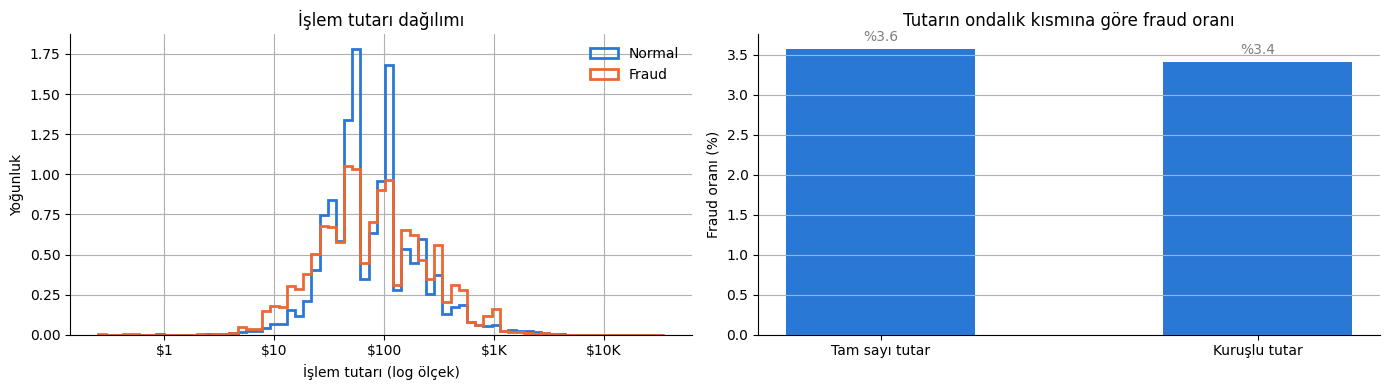

In [14]:
amt = df[["TransactionAmt", TARGET]]
display(amt.groupby(TARGET).TransactionAmt.describe(percentiles=[.25, .5, .75, .99]).round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
bins = np.linspace(np.log10(.25), np.log10(35000), 70)
for lab, col, name in [(0, BLUE, "Normal"), (1, ORANGE, "Fraud")]:
    axes[0].hist(np.log10(df.loc[df[TARGET] == lab, "TransactionAmt"]), bins=bins, density=True,
                 histtype="step", linewidth=2, color=col, label=name)
axes[0].set_xticks([0, 1, 2, 3, 4]); axes[0].set_xticklabels(["$1", "$10", "$100", "$1K", "$10K"])
axes[0].set_xlabel("İşlem tutarı (log ölçek)"); axes[0].set_ylabel("Yoğunluk"); axes[0].legend(frameon=False)
axes[0].set_title("İşlem tutarı dağılımı")

cents = (df.TransactionAmt * 100 % 100).round().astype(int)
dec = df.assign(has_cents=(cents != 0)).groupby("has_cents")[TARGET].mean() * 100
axes[1].bar(["Tam sayı tutar", "Kuruşlu tutar"], dec.values, color=BLUE, width=.5)
for x, v in zip(["Tam sayı tutar", "Kuruşlu tutar"], dec.values):
    axes[1].text(x, v + .1, f"%{v:.1f}", ha="center", color=INK2)
axes[1].set_ylabel("Fraud oranı (%)"); axes[1].grid(axis="x", visible=False)
axes[1].set_title("Tutarın ondalık kısmına göre fraud oranı")
plt.tight_layout(); plt.show()

In [15]:
cat_cols = [c for c in types[types.final_type.isin(["categorical", "binary"])].column if c != TARGET]
rows = []
for c in cat_cols:
    vc = df[c].value_counts(normalize=True)
    if vc.empty: continue
    p = vc.to_numpy(); ent = float(-(p * np.log2(p)).sum())
    rows.append(dict(column=c, group=feature_group(c), n_unique=len(vc), top_value=str(vc.index[0]),
                     top_pct=round(p[0] * 100, 2), entropy_bits=round(ent, 3),
                     rare_values_lt_0_1pct=int((p < .001).sum())))
cat_dist = pd.DataFrame(rows)
display(cat_dist[cat_dist.group.isin(["ProductCD", "card", "emaildomain", "M", "identity"])]
        .query("n_unique <= 100 or column in ['card1','DeviceInfo']").head(25))

def fraud_rate_by(col, top=10):
    g = (df[[col, TARGET]].astype({col: "object"}).fillna({col: "<NA>"})
         .groupby(col)[TARGET].agg(n="count", fraud_rate="mean")
         .sort_values("n", ascending=False).head(top))
    g["fraud_rate"] = (g.fraud_rate * 100).round(2)
    return g

for c in ["P_emaildomain", "M4"]:
    print(f"{c} → fraud oranı (%)"); display(fraud_rate_by(c, 8).T)

,column,group,n_unique,top_value,top_pct,entropy_bits,rare_values_lt_0_1pct
0,ProductCD,ProductCD,5,W,74.45,1.275,0
1,card1,card,13553,7919,2.53,9.968,13385
4,card4,card,4,visa,65.33,1.087,0
6,card6,card,4,debit,74.70,0.817,2
9,P_emaildomain,emaildomain,59,gmail.com,46.03,2.681,35
10,R_emaildomain,emaildomain,60,gmail.com,41.62,2.765,33
11,M1,M,2,T,99.99,0.001,1
12,M2,M,2,T,89.37,0.489,0
13,M3,M,2,T,78.80,0.745,0
14,M4,M,3,M0,63.54,1.310,0


P_emaildomain → fraud oranı (%)


P_emaildomain,gmail.com,yahoo.com,<NA>,hotmail.com,anonymous.com,aol.com,comcast.net,icloud.com
n,228355.00,100934.00,94456.00,45250.0,36998.00,28289.00,7888.00,6267.00
fraud_rate,4.35,2.28,2.95,5.3,2.32,2.18,3.12,3.14


M4 → fraud oranı (%)


M4,<NA>,M0,M2,M1
n,281444.00,196405.00,59865.00,52826.00
fraud_rate,1.86,3.66,11.37,2.71


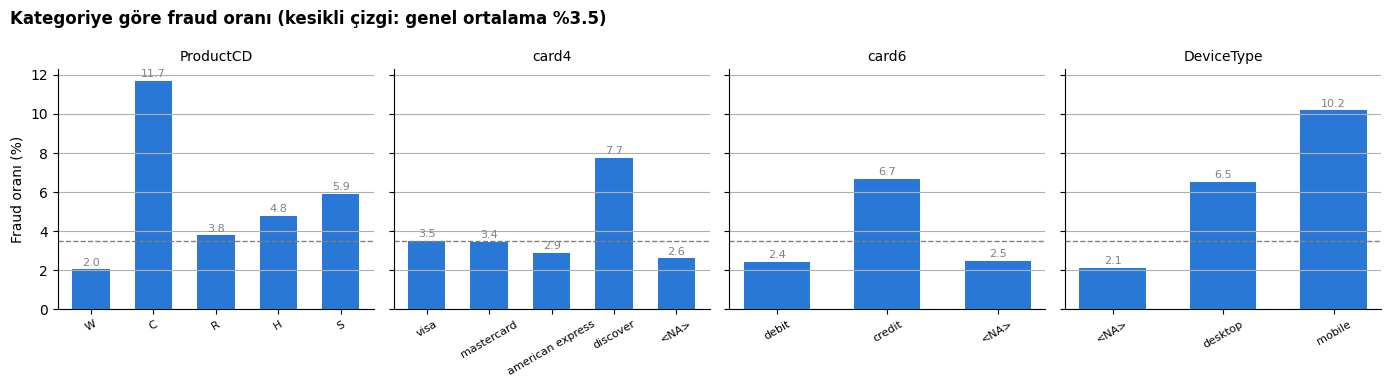

In [16]:
cols = ["ProductCD", "card4", "card6", "DeviceType"]
base = df[TARGET].mean() * 100
fig, axes = plt.subplots(1, 4, figsize=(14, 3.9), sharey=True)
for ax, c in zip(axes, cols):
    d = fraud_rate_by(c).query("n >= 500").reset_index()
    d[c] = d[c].astype(str)
    ax.bar(d[c], d.fraud_rate, color=BLUE, width=.6)
    ax.axhline(base, color=INK2, linestyle="--", linewidth=1)
    for x, v in zip(d[c], d.fraud_rate):
        ax.text(x, v + .2, f"{v:.1f}", ha="center", fontsize=8, color=INK2)
    ax.set_title(c, fontsize=10); ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("Fraud oranı (%)")
fig.suptitle(f"Kategoriye göre fraud oranı (kesikli çizgi: genel ortalama %{base:.1f})", x=.01, ha="left", fontweight="bold")
plt.tight_layout(); plt.show()

**Bulgular: Dağılımlar**

- Sayısal kolonların çoğu dengesiz dağılıyor: değerlerin büyük kısmı küçük, az sayıda çok büyük değer var. Örneğin işlem tutarında ortadaki değer 68,8 USD, ama en büyük tutar 31.937 USD. Bu yüzden tutar ve sayaç kolonlarında logaritma dönüşümü kullanılmalı; uç değerlerden az etkilenen yöntemler tercih edilmeli.
- Fraud işlemlerinin tutarı normal işlemlere göre biraz daha yüksek: ortadaki değer 75 USD (normalde 68,5 USD). Normal işlemler belirli tutarlarda yoğunlaşıyor; fraud işlemleri ise 10–30 USD ve 200–1.000 USD aralıklarında daha sık görülüyor. Tutarın kuruşlu olup olmaması fraud'u ayırt etmede pek işe yaramıyor.
- Bazı gruplarda fraud oranı, genel ortalama olan %3,5'in belirgin şekilde üstünde:
  - C ürünü: %11,7 (W ürününde %2,0)
  - Kredi kartı: %6,7 (banka kartında %2,4)
  - Discover kartı: %7,7
  - Mobil cihaz: %10,2 (masaüstünde %6,5)
  - Hotmail: %5,3, Gmail: %4,4 (Yahoo'da %2,3)
- Fraud işlemleri çoğunlukla yeni kartlardan geliyor. Kartın ilk kullanımından bu yana geçen gün sayısı fraud işlemlerinde genellikle 0–1, normal işlemlerde ise 4–56 gün.

## 1.6 Yüksek cardinality'e sahip alanlar

Eşikler: **100'den fazla** tekil değer → yüksek, **20–100 arası** → orta, 20 veya daha az → düşük.
Her alan için şu bilgiler hesaplanıyor: dağılımın %80'ini kapsamak için gereken değer sayısı, nadir değer sayısı (frekans < %0,1) ve önerilen encoding yöntemi.

,alan sayısı
cardinality,
high,13
low,10
medium,8


,column,group,n_unique,cardinality,values_covering_80pct,rare_values_lt_0_1pct,recommended_encoding
0,card1,card,13553,high,858,13385,frequency + target encoding (zaman bazlı OOF) / nadir → 'Other'
1,DeviceInfo,identity,1786,high,20,1739,frequency + target encoding (zaman bazlı OOF) / nadir → 'Other'
2,id_19,identity,522,high,24,461,frequency + target encoding (zaman bazlı OOF) / nadir → 'Other'
3,card2,card,500,high,51,401,frequency + target encoding (zaman bazlı OOF) / nadir → 'Other'
4,id_21,identity,490,high,43,406,frequency + target encoding (zaman bazlı OOF) / nadir → 'Other'
5,id_20,identity,394,high,27,323,frequency + target encoding (zaman bazlı OOF) / nadir → 'Other'
6,id_25,identity,341,high,37,254,frequency + target encoding (zaman bazlı OOF) / nadir → 'Other'
7,addr1,addr,332,high,22,279,frequency + target encoding (zaman bazlı OOF) / nadir → 'Other'
8,id_33,identity,260,high,13,217,frequency + target encoding (zaman bazlı OOF) / nadir → 'Other'
9,id_31,identity,130,high,15,79,frequency + target encoding (zaman bazlı OOF) / nadir → 'Other'


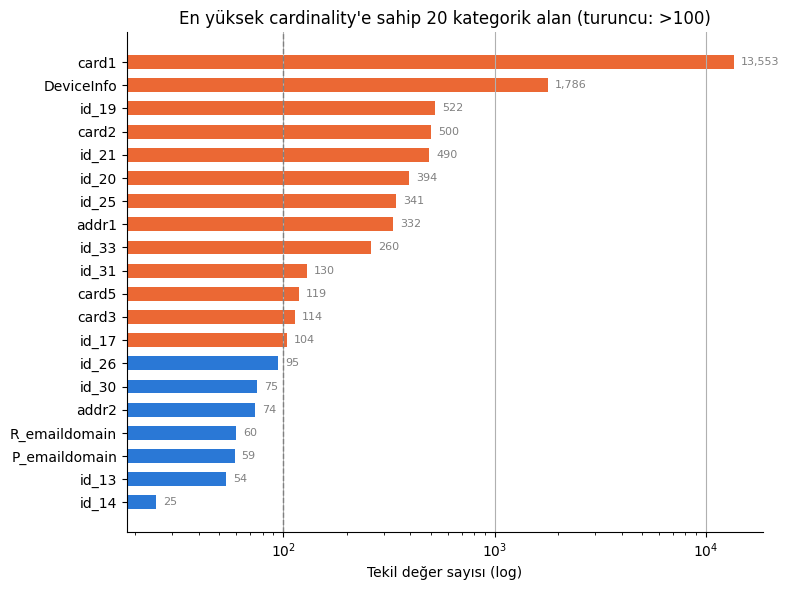

In [17]:
rows = []
for c in types[types.final_type == "categorical"].column:
    vc = df[c].value_counts(normalize=True); n = len(vc)
    level = "high" if n > 100 else "medium" if n > 20 else "low"
    rec = {"high": "frequency + target encoding (zaman bazlı OOF) / nadir → 'Other'",
           "medium": "one-hot (top-k) veya frequency encoding",
           "low": "one-hot / label encoding"}[level]
    rows.append(dict(column=c, group=feature_group(c), n_unique=n, cardinality=level,
                     values_covering_80pct=int((vc.cumsum() < .8).sum() + 1),
                     rare_values_lt_0_1pct=int((vc < .001).sum()), recommended_encoding=rec))
card = pd.DataFrame(rows).sort_values("n_unique", ascending=False).reset_index(drop=True)
display(card.cardinality.value_counts().to_frame("alan sayısı"))
display(card)

c = card.head(20).sort_values("n_unique")
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(c.column, c.n_unique, color=[ORANGE if v == "high" else BLUE for v in c.cardinality], height=.6)
ax.set_xscale("log"); ax.set_xlabel("Tekil değer sayısı (log)"); ax.grid(axis="y", visible=False)
for yy, v in zip(c.column, c.n_unique):
    ax.text(v * 1.08, yy, f"{v:,}", va="center", fontsize=8, color=INK2)
ax.axvline(100, color=INK2, linestyle="--", linewidth=1)
ax.set_title("En yüksek cardinality'e sahip 20 kategorik alan (turuncu: >100)")
plt.tight_layout(); plt.show()

**Bulgular: Cardinality**
- **Yüksek (13 alan):** card1 (13.553), DeviceInfo (1.786), id_19 (522), card2 (500), id_21 (490), id_20 (394), id_25 (341), addr1 (332), id_33 (260), id_31 (130), card5 (119), card3 (114), id_17 (104).
- **Orta (8 alan):** id_26, id_30, addr2, R_emaildomain, P_emaildomain, id_13, id_22, id_14. **Düşük:** 10 alan.
- card1'in uzun bir kuyruğu var: 13.385 değer satırların binde birinden azında geçiyor; dağılımın %80'ini kapsamak için 858 değer gerekiyor. One-hot encoding bu alan için uygun değil.
- **Öneriler:**
  - Yüksek cardinality alanlarına **frequency encoding** ve zamana göre **out-of-fold target encoding** uygulanmalı (sızıntıyı önlemek için); nadir değerler "Other" altında toplanmalı.
  - DeviceInfo, id_30 ve id_31 için önce marka ve aile bilgisi çıkarılmalı (`Windows 10` → `Windows`); bu, cardinality'i büyük ölçüde düşürür.
  - **card1 + addr1 + D1** kombinasyonu bir **kullanıcı kimliği (UID)** adayı. Adım 2–3'te kullanıcı bazlı agregasyonlar ve davranış sapmaları bu kimlik üzerinden hesaplanabilir.

## 1.7 Sonuç ve Adım 2 için çıkarımlar

**Adım 1 özeti:** Transaction ve identity tabloları bire bir ve kayıpsız birleştirildi (590.540 × 435). Veri **yüksek oranda eksik** (%45), **dengesiz** (%3,5 fraud), **çarpık** ve **anonimleştirilmiş**. Bununla birlikte eksiklik örüntüleri, kategoriler ve zaman/gün farkı kolonları güçlü fraud sinyalleri taşıyor.

**Sonraki adımlar (profiling, feature engineering, anomali tespiti) için yapılacaklar:**
1. Missing indicator'lar (blok bazında) ve `has_identity` özellik olarak tutulacak.
2. Yarı sabit 30 kolon elenecek; V blokları PCA ya da korelasyon filtresiyle indirgenecek.
3. TransactionAmt'e log dönüşümü uygulanacak; ondalık kısmı yardımcı özellik olarak tutulacak. TransactionDT'den gün, saat ve haftanın günü türetilecek. Negatif D değerleri 0'a kırpılacak.
4. Yüksek cardinality alanları frequency veya target encoding ile kodlanacak. id_30, id_31 ve DeviceInfo'dan marka/aile bilgisi çıkarılacak.
5. card1 + addr1 + D1 ile **UID** oluşturulacak; kullanıcı bazlı agregasyonlar (ortalama tutar, işlem sıklığı, tutar sapması) hesaplanacak. Bu agregasyonlar context-aware anomali skorlamanın temelini oluşturacak.
6. Doğrulama **zamana göre** bölünecek (örneğin ilk 5 ay eğitim, son ay doğrulama).

# ADIM 2: Data Profiling & Schema Intelligence

Amaç yalnızca veriyi okumak değil, **verinin semantik yapısını** anlamlandırmak: hangi kolon ne anlama geliyor, hangi kolonlar birbirini tekrar ediyor, hangi varlık (kart, kullanıcı, cihaz) nasıl davranıyor.


In [18]:
from scipy import stats
from sklearn.metrics import roc_auc_score, average_precision_score

rng = np.random.default_rng(42)
DAY = (df[TIME] // 86400).astype("int32")

# TransactionDT bir referans noktasından itibaren geçen saniyedir. Toplulukta kabul gören varsayım:
# referans = 2017-12-01 (ilk işlem günü 2 Aralık; ilk 25 gündeki yüksek hacim Aralık tatil sezonu ile uyumlu).
START_DATE = pd.Timestamp("2017-12-01")
df["TransactionDateTime"] = START_DATE + pd.to_timedelta(df[TIME], unit="s")
print("Zaman aralığı:", df.TransactionDateTime.min(), "→", df.TransactionDateTime.max())

Zaman aralığı: 2017-12-02 00:00:00 → 2018-06-01 23:58:51


## 2.1 Numeric / categorical / datetime ayrımı (semantik şema)

Adım 1'deki teknik tip bilgisi (`final_type`) bir **semantik rol** katmanıyla zenginleştiriliyor:

| Rol | Kolonlar | Tür |
|---|---|---|
| identifier | TransactionID | other |
| target | isFraud | other |
| datetime | TransactionDT, TransactionDateTime | datetime |
| timedelta (gün) | D1–D15 (ör. kartın ilk kullanımından beri geçen gün) | datetime |
| amount | TransactionAmt | numeric |
| count | C1–C14 (karta bağlı adres, e-posta vb. sayaçlar) | numeric |
| distance | dist1–dist2 | numeric |
| vesta_numeric | V1–V339 (Vesta'nın ürettiği özellikler) | numeric |
| identity_numeric | id_01–id_11 | numeric |
| categorical | card, addr, email, M, id_12+, Device | categorical |
| binary_flag | 2 değerli alanlar | categorical |

In [19]:
tmap = types.set_index("column").final_type
def semantic_role(c):
    if c == KEY: return "identifier"
    if c == TARGET: return "target"
    if c in (TIME, "TransactionDateTime"): return "datetime"
    if re.fullmatch(r"D\d+", c): return "timedelta (gün)"
    if c == "TransactionAmt": return "amount"
    if re.fullmatch(r"C\d+", c): return "count"
    if c.startswith("dist"): return "distance"
    t = tmap.get(c, "")
    if t == "binary": return "binary_flag"
    if t == "categorical": return "categorical"
    if c.startswith("V"): return "vesta_numeric"
    if c.startswith("id_"): return "identity_numeric"
    return "numeric"

KIND = {"identifier": "other", "target": "other", "datetime": "datetime", "timedelta (gün)": "datetime",
        "categorical": "categorical", "binary_flag": "categorical"}
schema = pd.DataFrame({"column": df.columns})
schema["group"] = schema.column.map(feature_group)
schema["dtype"] = df.dtypes.astype(str).values
schema["semantic_role"] = schema.column.map(semantic_role)
schema["kind"] = schema.semantic_role.map(lambda r: KIND.get(r, "numeric"))
schema["null_ratio"] = df.isna().mean().values.round(4)
schema["n_unique"] = df.nunique().values

display(schema.groupby(["kind", "semantic_role"]).agg(n_columns=("column", "count"),
        mean_null_ratio=("null_ratio", "mean")).round(3))
NUMERIC_COLS = schema.query("kind=='numeric'").column.tolist()
CATEG_COLS = schema.query("kind=='categorical'").column.tolist()
DATETIME_COLS = schema.query("kind=='datetime'").column.tolist()
print(f"numeric: {len(NUMERIC_COLS)} | categorical: {len(CATEG_COLS)} | datetime/timedelta: {len(DATETIME_COLS)}")

n_columns  mean_null_ratio
kind        semantic_role                               
categorical binary_flag              26            0.502
            categorical              31            0.589
datetime    datetime                  2            0.000
            timedelta (gün)          15            0.582
numeric     amount                    1            0.000
            count                    14            0.000
            distance                  2            0.766
            identity_numeric         11            0.847
            vesta_numeric           332            0.436
other       identifier                1            0.000
            target                    1            0.000

numeric: 360 | categorical: 57 | datetime/timedelta: 17


In [20]:
# D kolonları gerçekten "zaman farkı" mı? Kanıt: D1 her gün 1 artıyorsa (DAY - D1) kart bazında sabit kalır.
chk = df.loc[df.D1.notna(), ["card1", "addr1", "D1"]].assign(day=DAY)
chk["D1n"] = chk.day - chk.D1
corr_d1_day = np.corrcoef(chk.day, chk.D1)[0, 1]
stab = chk.groupby(["card1", "addr1", "D1n"]).size()
print(f"corr(DAY, D1) = {corr_d1_day:.3f}")
print(f"(DAY - D1) ile tanımlanan grupların ortalama işlem sayısı: {stab.mean():.2f} (sabit bir 'ilk kullanım günü' olduğunu gösterir)")
ex = chk[chk.card1 == chk.card1.value_counts().index[50]].head(8)
display(ex)

corr(DAY, D1) = 0.074
(DAY - D1) ile tanımlanan grupların ortalama işlem sayısı: 2.63 (sabit bir 'ilk kullanım günü' olduğunu gösterir)


,card1,addr1,D1,day,D1n
14,11839,226.0,0.0,1,1.0
57,11839,204.0,0.0,1,1.0
227,11839,512.0,0.0,1,1.0
905,11839,512.0,148.0,1,-147.0
1261,11839,420.0,395.0,1,-394.0
1274,11839,420.0,395.0,1,-394.0
1282,11839,420.0,395.0,1,-394.0
1852,11839,123.0,335.0,1,-334.0


**Bulgular: Şema**
- 434 kolon üç türe ayrıldı: **360 numeric**, **57 categorical**, **17 datetime/timedelta** (TransactionDT, TransactionDateTime ve D1–D15). ID ve hedef kolonu ayrı tutuldu.
- Zaman aralığı 2017-12-02 → 2018-06-01 (182 gün). Başlangıç tarihi, toplulukta kabul gören bir **varsayım**: 2017-12-01.
- `DAY − D1` (kartın ilk kullanım günü) aynı card1/addr1 için sabit kalıyor; bu gruplar ortalama 2,6 işlem içeriyor. Bu yüzden D1, 2.7'deki kullanıcı (uid) tanımında kullanılıyor.

## 2.2 Null ratio analizi

Adım 1'deki kolon bazlı eksik veri analizi burada **anlam** açısından derinleştiriliyor:
- Null ratio **semantik rol** ve **ürün tipi (ProductCD)** bazında nasıl değişiyor? Bu, eksikliğin yapısal mı yoksa rastgele mi olduğunu gösterir.
- Null ratio **zamanla** değişiyor mu? Değişiyorsa bu, veri toplama sürecinde bir drift olduğuna işaret eder.
- Satır bazında null sayısı ile fraud ilişkisi.

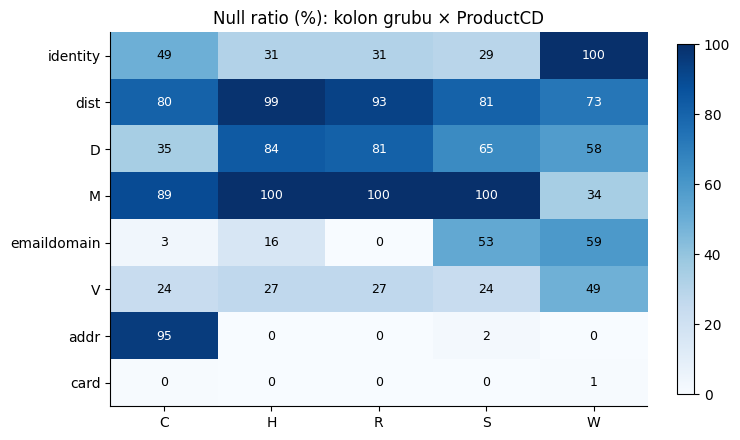

In [21]:
PRODUCT = df.ProductCD.astype(str)
GROUPS = ["identity", "dist", "D", "M", "emaildomain", "V", "addr", "card"]
grp_cols = {g: [c for c in df.columns if feature_group(c) == g] for g in GROUPS}
row_null = {g: df[cols].isna().mean(axis=1) for g, cols in grp_cols.items()}
row_null = pd.DataFrame(row_null)

by_prod = row_null.groupby(PRODUCT).mean().T * 100
fig, ax = plt.subplots(figsize=(7.5, 4.5))
im = ax.imshow(by_prod.values, cmap="Blues", vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(by_prod.shape[1])); ax.set_xticklabels(by_prod.columns)
ax.set_yticks(range(by_prod.shape[0])); ax.set_yticklabels(by_prod.index); ax.grid(False)
for i in range(by_prod.shape[0]):
    for j in range(by_prod.shape[1]):
        v = by_prod.values[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=9, color="white" if v > 60 else INK)
ax.set_title("Null ratio (%): kolon grubu × ProductCD"); plt.colorbar(im, ax=ax, fraction=.03)
plt.tight_layout(); plt.show()

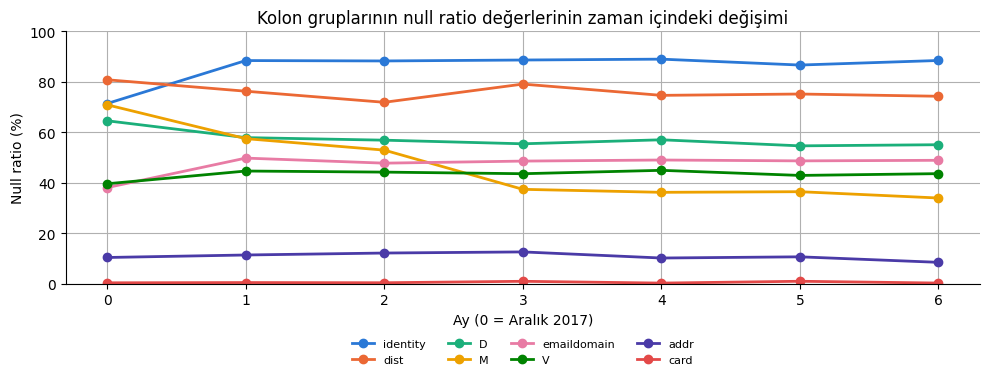

,identity,dist,D,M,emaildomain,V,addr,card
ay,,,,,,,,
0,71.4,80.8,64.5,70.9,38.1,39.6,10.4,0.3
1,88.4,76.3,57.9,57.5,49.8,44.6,11.3,0.4
2,88.3,71.9,56.9,52.9,47.8,44.2,12.1,0.3
3,88.6,79.1,55.4,37.4,48.6,43.6,12.6,0.9
4,89.0,74.6,57.0,36.2,49.0,44.9,10.1,0.2
5,86.7,75.2,54.6,36.4,48.7,42.9,10.6,0.9
6,88.5,74.3,55.1,33.9,48.9,43.6,8.4,0.2


Satır başına null sayısına göre fraud oranı:


,"(0, 150]","(150, 200]","(200, 250]","(250, 300]","(300, 350]"
n,136281.00,3651.0,432320.00,18202.00,86.0
fraud_rate,7.82,10.6,2.09,3.11,9.3


In [22]:
month = (DAY // 30).rename("ay")
by_month = row_null.groupby(month).mean() * 100
fig, ax = plt.subplots(figsize=(10, 4))
palette = [BLUE, ORANGE, "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
for (g, col) in zip(GROUPS, palette):
    ax.plot(by_month.index, by_month[g], marker="o", color=col, linewidth=2, label=g)
ax.set_xlabel("Ay (0 = Aralık 2017)"); ax.set_ylabel("Null ratio (%)"); ax.set_ylim(0, 100)
ax.legend(ncol=4, frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(.5, -.18))
ax.set_title("Kolon gruplarının null ratio değerlerinin zaman içindeki değişimi")
plt.tight_layout(); plt.show()
display(by_month.round(1))

n_null = df.isna().sum(axis=1)
nb = pd.cut(n_null, [0, 150, 200, 250, 300, 350, 450])
t = df.groupby(nb, observed=True)[TARGET].agg(n="count", fraud_rate="mean")
t["fraud_rate"] = (t.fraud_rate * 100).round(2)
print("Satır başına null sayısına göre fraud oranı:"); display(t.T)

**Bulgular: Null ratio**
- Eksiklik zamanla değişiyor. **M** grubunda null oranı Aralık'ta %71 iken Haziran'da %34'e düşüyor; identity grubunda ise %71'den %88'e çıkıyor. Bu, veri toplama sürecinde bir drift olduğunu gösteriyor.
- Eksiklik fraud ile ilişkili. 150'den az null içeren satırlarda (çoğu identity bilgisi olanlar) fraud oranı **%7,8**; 200–250 null içerenlerde **%2,1**.
- **Sonuç:** Eksiklik bilgi taşıyor. Körü körüne doldurmak (impute) yerine `n_missing_row` ve `has_identity` gibi eksiklik sinyalleri feature olarak tutulmalı.

## 2.3 Outlier analizi

Kilit sayısal kolonlarda üç farklı yöntem karşılaştırılıyor:
- **IQR:** `x < Q1 − 1,5·IQR` veya `x > Q3 + 1,5·IQR`
- **Robust z (MAD):** `|x − medyan| / (1,4826·MAD) > 3,5`. Çarpık kolonlarda log1p dönüşümünden sonra uygulanıyor.
- **Yüzdelik:** üst %0,5'lik dilim (`x > p99.5`)

Her yöntem için outlier oranı ve outlier'lar içindeki fraud oranı (lift) hesaplanıyor. Outlier tespitinin fraud'u ne ölçüde yakaladığı bu şekilde görülebiliyor.

In [23]:
OUTLIER_COLS = ["TransactionAmt", "dist1", "C1", "C2", "C5", "C6", "C9", "C13", "C14",
                "D1", "D2", "D4", "D10", "D15", "V258", "V294", "id_01", "id_02"]
base_rate = df[TARGET].mean()
rows, flags = [], {}
for c in OUTLIER_COLS:
    x = df[c].astype("float64"); m = x.notna(); xs = x[m]
    q1, q3 = xs.quantile([.25, .75]); iqr = q3 - q1
    f_iqr = (x < q1 - 1.5 * iqr) | (x > q3 + 1.5 * iqr)
    xt = np.log1p(x.clip(lower=0)) if (xs.min() >= 0 and xs.skew() > 2) else x
    med = xt[m].median(); mad = (xt[m] - med).abs().median() * 1.4826
    f_mad = ((xt - med).abs() / mad > 3.5) if mad > 0 else pd.Series(False, index=x.index)
    f_pct = x > xs.quantile(.995)
    flags[c] = f_iqr
    r = dict(column=c, role=semantic_role(c), non_null_pct=round(m.mean() * 100, 1))
    for name, f in [("iqr", f_iqr), ("mad", f_mad), ("p995", f_pct)]:
        r[f"{name}_outlier_pct"] = round(f.mean() * 100, 2)
        r[f"{name}_fraud_rate"] = round(df.loc[f, TARGET].mean() * 100, 2) if f.any() else np.nan
    rows.append(r)
outl = pd.DataFrame(rows)
for name in ["iqr", "mad", "p995"]:
    outl[f"{name}_lift"] = (outl[f"{name}_fraud_rate"] / (base_rate * 100)).round(2)
display(outl.set_index("column"))

,role,non_null_pct,iqr_outlier_pct,iqr_fraud_rate,mad_outlier_pct,mad_fraud_rate,p995_outlier_pct,p995_fraud_rate,iqr_lift,mad_lift,p995_lift
column,,,,,,,,,,,
TransactionAmt,amount,100.0,11.26,5.07,1.20,2.97,0.50,1.76,1.45,0.85,0.50
dist1,distance,40.3,6.77,3.19,1.15,2.51,0.20,1.85,0.91,0.72,0.53
C1,count,100.0,10.08,8.52,0.00,NaN,0.50,14.73,2.43,NaN,4.21
C2,count,100.0,10.54,8.60,0.00,NaN,0.49,22.80,2.46,NaN,6.52
C5,count,100.0,10.24,0.98,0.00,NaN,0.50,0.82,0.28,NaN,0.23
C6,count,100.0,13.26,6.22,0.00,NaN,0.50,7.40,1.78,NaN,2.11
C9,count,100.0,7.22,2.07,4.16,0.95,0.48,1.05,0.59,0.27,0.30
C13,count,100.0,12.81,2.02,4.50,1.73,0.50,6.32,0.58,0.49,1.81
C14,count,100.0,16.27,3.18,0.00,NaN,0.50,6.91,0.91,NaN,1.97


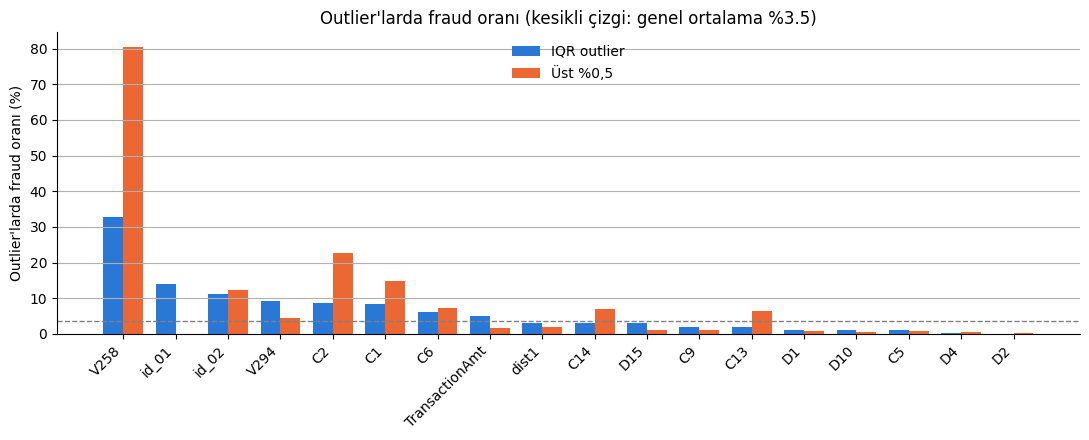

Satır başına kaç kolonda IQR-outlier var? → fraud oranı


,0,1,2,3,4,5,6+
n,263608.00,161766.0,66701.00,29536.00,14403.00,9666.00,44860.00
fraud_rate,1.61,3.8,5.32,6.91,10.79,14.93,3.77


In [24]:
fig, ax = plt.subplots(figsize=(11, 4.5))
o = outl.sort_values("iqr_lift", ascending=False)
x = np.arange(len(o)); w = .38
ax.bar(x - w / 2, o.iqr_fraud_rate, w, color=BLUE, label="IQR outlier")
ax.bar(x + w / 2, o.p995_fraud_rate, w, color=ORANGE, label="Üst %0,5")
ax.axhline(base_rate * 100, color=INK2, linestyle="--", linewidth=1)
ax.set_xticks(x); ax.set_xticklabels(o.column, rotation=45, ha="right")
ax.set_ylabel("Outlier'larda fraud oranı (%)"); ax.legend(frameon=False); ax.grid(axis="x", visible=False)
ax.set_title(f"Outlier'larda fraud oranı (kesikli çizgi: genel ortalama %{base_rate*100:.1f})")
plt.tight_layout(); plt.show()

n_out = pd.DataFrame(flags).sum(axis=1)
t = df.groupby(n_out.clip(upper=6))[TARGET].agg(n="count", fraud_rate="mean")
t["fraud_rate"] = (t.fraud_rate * 100).round(2)
t.index = [f"{i}" if i < 6 else "6+" for i in t.index]
print("Satır başına kaç kolonda IQR-outlier var? → fraud oranı"); display(t.T)

**Bulgular: Outlier**
- **IQR** ağır kuyruklu C kolonlarında satırların %7–16'sını outlier olarak işaretliyor, yani fazla geniş. **MAD** ise sıfır ağırlıklı kolonlarda çöküyor: C kolonlarında %0, D1'de %43. En isabetli yöntem **üst %0,5** kesimi.
- Riskli outlier'lar C kolonlarında. Üst %0,5'te fraud oranı C2'de **%22,8 (lift 6,5)**, C1'de %14,7. Yüksek **tutar** ise riskli değil (lift 0,5).
- Bir satırda outlier olan kolon sayısı arttıkça fraud oranı artıyor: 0 kolonda %1,6, 5 kolonda **%14,9**. Bu, column katmanında tek kolon yerine **birden fazla kolonun birleştirilmesini** destekliyor.

## 2.4 Distribution analizi

- **Şekil sınıflandırması:** her sayısal kolon; *zero-inflated* (değerlerin %50'sinden fazlası 0), *heavy-tailed* (kurtosis > 20), *right-skewed* (skew > 1), *near-symmetric* ve *low-cardinality discrete* (≤ 10 tekil değer) sınıflarından birine atanıyor.
- **Log dönüşümünün etkisi:** dönüşüm öncesi ve sonrası çarpıklık karşılaştırılıyor.
- **Fraud ve normal dağılım farkı:** Kolmogorov–Smirnov (KS) istatistiği hesaplanıyor. KS, iki dağılımın en büyük ayrışmasını ölçer; kolonun ayırt ediciliğini gösterir.

In [25]:
num_dist_ = num_dist.set_index("column")
def shape_class(c):
    r = num_dist_.loc[c]
    nunq = schema.set_index("column").n_unique[c]
    if r["zero_pct"] > 50: return "zero-inflated"
    if nunq <= 10: return "low-card discrete"
    if r["kurtosis"] > 20: return "heavy-tailed"
    if r["skew"] > 1: return "right-skewed"
    if r["skew"] < -1: return "left-skewed"
    return "near-symmetric"
dist_cols = [c for c in NUMERIC_COLS + DATETIME_COLS if c in num_dist_.index]
shape = pd.Series({c: shape_class(c) for c in dist_cols}, name="shape")
display(pd.crosstab(shape, shape.index.map(feature_group)).assign(toplam=lambda t: t.sum(axis=1)))

sk = []
for c in ["TransactionAmt", "C1", "C13", "C14", "dist1", "D1", "D15", "V258"]:
    x = df[c].dropna().astype("float64")
    sk.append(dict(column=c, skew_raw=x.skew(), skew_log1p=np.log1p(x.clip(lower=0)).skew()))
print("Log1p dönüşümünün çarpıklığa etkisi:"); display(pd.DataFrame(sk).set_index("column").round(2))

col_0,C,D,TransactionAmt,V,dist,identity,toplam
shape,,,,,,,
heavy-tailed,7,1,1,74,2,1,86
left-skewed,0,0,0,0,0,2,2
low-card discrete,0,0,0,44,0,0,44
near-symmetric,0,2,0,2,0,1,5
right-skewed,0,7,0,3,0,1,11
zero-inflated,7,5,0,209,0,6,227


Log1p dönüşümünün çarpıklığa etkisi:


,skew_raw,skew_log1p
column,,
TransactionAmt,14.37,0.49
C1,23.96,3.11
C13,8.99,1.36
C14,16.53,2.91
dist1,5.11,1.01
D1,1.81,0.34
D15,0.96,-0.18
V258,17.43,4.96


Fraud ve normal dağılımı en çok ayrışan 15 kolon (KS):


,column,group,ks
0,V258,V,0.463
1,D5,D,0.440
2,V257,V,0.438
3,V265,V,0.417
4,V219,V,0.417
5,V264,V,0.414
6,V218,V,0.412
7,V232,V,0.412
8,V274,V,0.412
9,V246,V,0.405


,count,mean,max
group,,,
V,332,0.167,0.463
D,15,0.220,0.440
C,14,0.230,0.331
identity,11,0.081,0.217
dist,2,0.090,0.111
TransactionAmt,1,0.074,0.074


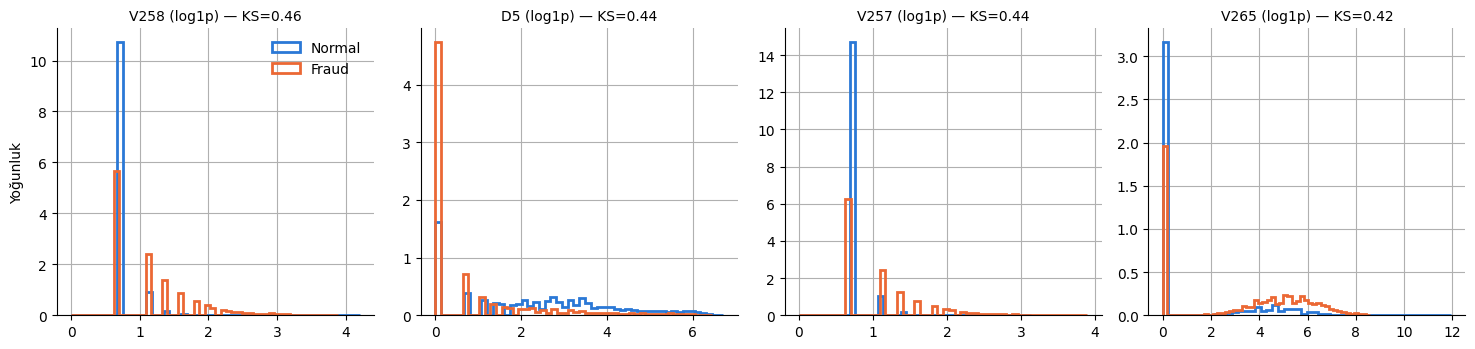

In [26]:
y_all = df[TARGET].to_numpy()
fr_idx = np.where(y_all == 1)[0]
lg_idx = rng.choice(np.where(y_all == 0)[0], 100_000, replace=False)
ks_rows = []
for c in dist_cols:
    a = df[c].to_numpy()[fr_idx]; b = df[c].to_numpy()[lg_idx]
    a = a[~np.isnan(a)]; b = b[~np.isnan(b)]
    if len(a) > 100 and len(b) > 100:
        ks_rows.append(dict(column=c, group=feature_group(c), ks=stats.ks_2samp(a, b).statistic))
ks = pd.DataFrame(ks_rows).sort_values("ks", ascending=False).reset_index(drop=True)
print("Fraud ve normal dağılımı en çok ayrışan 15 kolon (KS):")
display(ks.head(15).round(3))
display(ks.groupby("group").ks.agg(["count", "mean", "max"]).round(3).sort_values("max", ascending=False))

top4 = ks.column.head(4).tolist()
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, c in zip(axes, top4):
    for lab, col, name in [(0, BLUE, "Normal"), (1, ORANGE, "Fraud")]:
        v = df.loc[df[TARGET] == lab, c].dropna().astype("float64")
        v = np.log1p(v.clip(lower=0)) if v.min() >= 0 else v
        ax.hist(v, bins=50, density=True, histtype="step", linewidth=2, color=col, label=name)
    ax.set_title(f"{c} (log1p) — KS={ks.set_index('column').ks[c]:.2f}", fontsize=10)
axes[0].legend(frameon=False); axes[0].set_ylabel("Yoğunluk")
plt.tight_layout(); plt.show()

**Bulgular: Dağılım**
- 375 sayısal kolonun 227'si **zero-inflated** (değerlerin yarısından fazlası 0), 86'sı **heavy-tailed**. Normal dağılım varsayımı geçersiz; robust yöntemler ve log dönüşümü gerekli. Örneğin log1p, tutarın çarpıklığını 14,4'ten 0,5'e indiriyor.
- Fraud ile normal dağılımı en çok ayrışan kolonlar V258 (KS 0,46) ve D5 (0,44). Gruplar arasında V, C ve D öne çıkıyor. Tutar tek başına zayıf (KS 0,07).

## 2.5 Rare categorical combination analizi

Tek tek bakıldığında yaygın olan değerler, **bir araya geldiklerinde** nadir bir kombinasyon oluşturabilir. Örneğin "discover + credit + hotmail + mobile" kombinasyonu.
- Her kombinasyon tanımı için şunlar hesaplanıyor: tekil kombinasyon sayısı, nadir kombinasyonlara düşen satır oranı (≤ 20 kez görülenler) ve nadir ile yaygın kombinasyonlarda fraud oranı.
- Kombinasyonun görülme sıklığına göre fraud oranı eğrisi çiziliyor.

In [27]:
COMBOS = {
    "product×card4×card6": ["ProductCD", "card4", "card6"],
    "card4×card6×P_email": ["card4", "card6", "P_emaildomain"],
    "P_email×R_email": ["P_emaildomain", "R_emaildomain"],
    "product×card×email×device": ["ProductCD", "card4", "card6", "P_emaildomain", "DeviceType"],
    "card1×addr1": ["card1", "addr1"],
    "os×browser×device": ["id_30", "id_31", "DeviceType"],
}
RARE_N = 20
def combo_key(cols):
    k = df[cols[0]].astype(str)
    for c in cols[1:]:
        k = k + "|" + df[c].astype(str)
    return k
combo_freq, rows = {}, []
for name, cols in COMBOS.items():
    key = combo_key(cols)
    cnt = key.map(key.value_counts()); combo_freq[name] = cnt
    rare = cnt <= RARE_N
    rows.append(dict(combination=name, n_combinations=key.nunique(), rare_row_pct=round(rare.mean() * 100, 2),
                     fraud_rate_rare=round(df.loc[rare, TARGET].mean() * 100, 2),
                     fraud_rate_common=round(df.loc[~rare, TARGET].mean() * 100, 2)))
combo_tbl = pd.DataFrame(rows)
combo_tbl["lift_rare"] = (combo_tbl.fraud_rate_rare / (base_rate * 100)).round(2)
display(combo_tbl)

,combination,n_combinations,rare_row_pct,fraud_rate_rare,fraud_rate_common,lift_rare
0,product×card4×card6,46,0.01,14.81,3.50,4.23
1,card4×card6×P_email,408,0.16,6.54,3.49,1.87
2,P_email×R_email,743,0.39,3.31,3.50,0.95
3,product×card×email×device,1734,0.94,4.65,3.49,1.33
4,card1×addr1,39974,21.88,2.98,3.65,0.85
5,os×browser×device,937,0.52,10.91,3.46,3.12


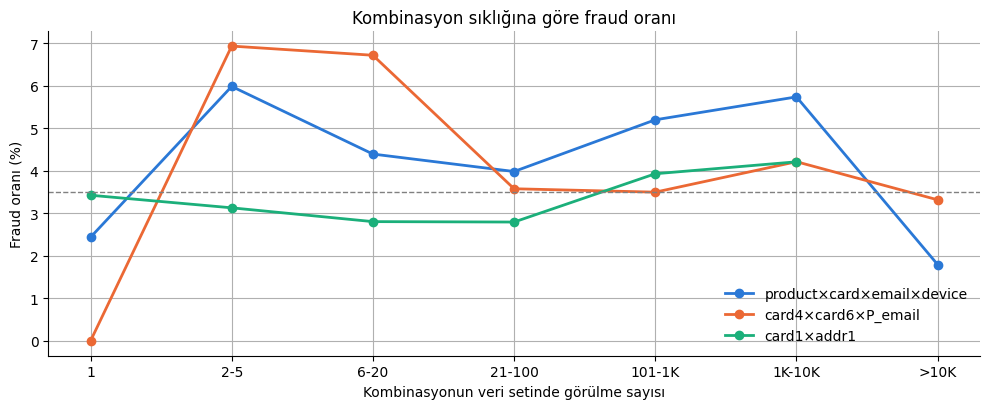

Seyrek (20–300 kez) ama fraud oranı en yüksek 5'li kombinasyonlar:


,n,fraud_rate
R|visa|credit|outlook.com|mobile,33,75.8
C|mastercard|credit|outlook.es|desktop,24,50.0
W|visa|credit|mail.com|nan,46,43.5
C|mastercard|credit|outlook.com|desktop,138,39.1
W|mastercard|credit|mail.com|nan,48,37.5
C|mastercard|credit|icloud.com|mobile,42,33.3
W|discover|credit|comcast.net|nan,91,33.0
S|mastercard|credit|nan|mobile,216,32.9
S|mastercard|credit|nan|nan,66,30.3
H|discover|credit|anonymous.com|mobile,20,30.0


In [28]:
bins = [0, 1, 5, 20, 100, 1000, 10_000, 1e7]
labels = ["1", "2-5", "6-20", "21-100", "101-1K", "1K-10K", ">10K"]
fig, ax = plt.subplots(figsize=(10, 4.2))
for (name, col) in zip(["product×card×email×device", "card4×card6×P_email", "card1×addr1"], [BLUE, ORANGE, "#1baf7a"]):
    b = pd.cut(combo_freq[name], bins, labels=labels)
    fr = df.groupby(b, observed=False)[TARGET].mean() * 100
    ax.plot(labels, fr.reindex(labels).values, marker="o", linewidth=2, color=col, label=name)
ax.axhline(base_rate * 100, color=INK2, linestyle="--", linewidth=1)
ax.set_xlabel("Kombinasyonun veri setinde görülme sayısı"); ax.set_ylabel("Fraud oranı (%)")
ax.legend(frameon=False); ax.set_title("Kombinasyon sıklığına göre fraud oranı")
plt.tight_layout(); plt.show()

key = combo_key(COMBOS["product×card×email×device"])
g = df.groupby(key)[TARGET].agg(n="count", fraud_rate="mean")
g = g[(g.n >= 20) & (g.n <= 300)].sort_values("fraud_rate", ascending=False).head(10)
g["fraud_rate"] = (g.fraud_rate * 100).round(1)
print("Seyrek (20–300 kez) ama fraud oranı en yüksek 5'li kombinasyonlar:")
display(g)

**Bulgular: Nadir kombinasyonlar**
- Tek tek yaygın olan değerler birleşince risk oluşturabiliyor. Nadir `ProductCD × card4 × card6` kombinasyonlarında fraud oranı **%17,1 (lift 4,9)**, nadir `os × browser × device` kombinasyonlarında %10,3 (lift 2,9).
- Örnekler: `R | visa | credit | outlook.com | mobile` kombinasyonunda fraud oranı %76 (33 işlem). C ürününde *kredi kartı + outlook/icloud* örüntüsü tekrar ediyor.
- Ancak her nadir kombinasyon riskli değil. Örneğin `card1 × addr1` için lift 0,8. Kombinasyonlar anlamlı alanlardan seçilmeli.

## 2.6 Kolon ilişkileri

Kolon ilişkileri dört açıdan inceleniyor:
1. **Sayısal korelasyon:** C, D, tutar ve mesafe kolonları arasında Spearman korelasyonu.
2. **V kolonlarında tekrar (redundancy):** Her eksiklik bloğu içinde |r| > 0,95 olan kolonlar açgözlü (greedy) bir yöntemle elenerek temsilci kolonlar seçiliyor.
3. **Fonksiyonel bağımlılık:** A kolonunun değeri B'yi belirliyor mu? Bu, şemanın semantik hiyerarşisini ortaya çıkarır.
4. **Hedefle ilişki:** tek değişkenli ROC-AUC.

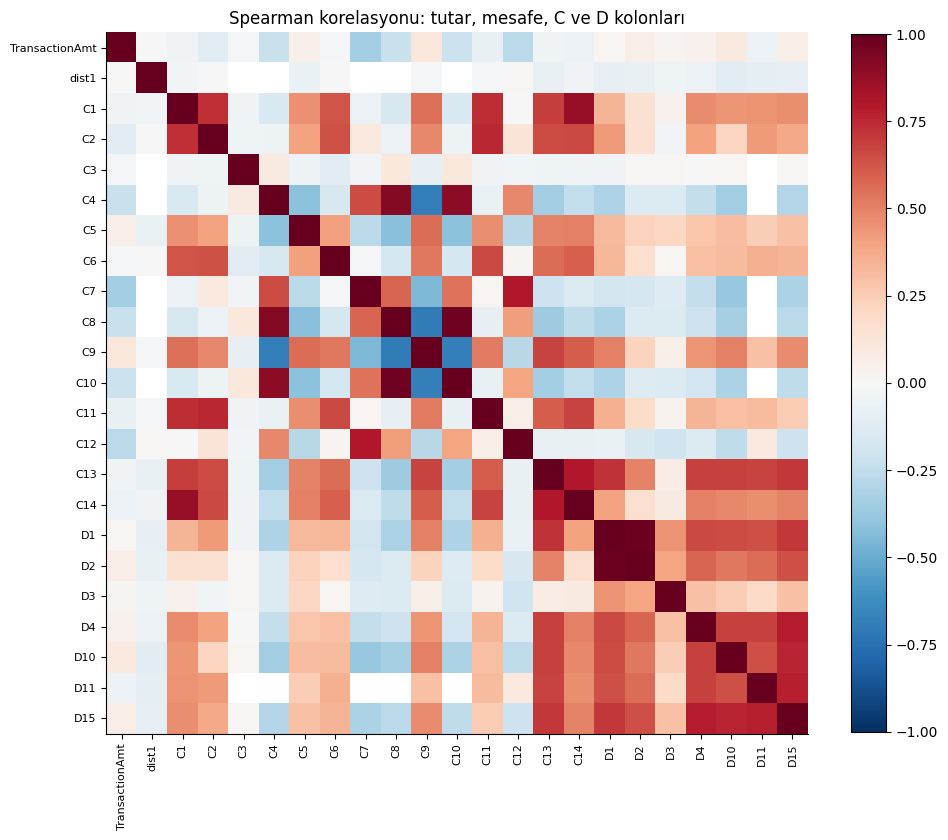

En güçlü 12 ilişki:


spearman
D1  D2      0.980
C8  C10     0.971
C4  C8      0.915
    C10     0.891
C1  C14     0.871
C7  C12     0.804
C13 C14     0.803
D4  D15     0.784
D11 D15     0.773
D10 D15     0.759
C2  C11     0.757
C1  C11     0.737

In [29]:
samp = df.sample(150_000, random_state=42)
rel_cols = ["TransactionAmt", "dist1"] + [f"C{i}" for i in range(1, 15)] + ["D1", "D2", "D3", "D4", "D10", "D11", "D15"]
sp = samp[rel_cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(10, 8.5))
im = ax.imshow(sp.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(rel_cols))); ax.set_xticklabels(rel_cols, rotation=90, fontsize=8)
ax.set_yticks(range(len(rel_cols))); ax.set_yticklabels(rel_cols, fontsize=8); ax.grid(False)
plt.colorbar(im, ax=ax, fraction=.04); ax.set_title("Spearman korelasyonu: tutar, mesafe, C ve D kolonları")
plt.tight_layout(); plt.show()

pairs = sp.where(np.triu(np.ones(sp.shape, bool), 1)).stack().sort_values(key=abs, ascending=False)
print("En güçlü 12 ilişki:"); display(pairs.head(12).round(3).to_frame("spearman"))

In [30]:
v_cols = [c for c in df.columns if re.fullmatch(r"V\d+", c)]
v_blocks = {}
for c in v_cols:
    v_blocks.setdefault(np.packbits(df[c].isna().to_numpy()).tobytes(), []).append(c)
V_REPRESENTATIVES, red_rows = [], []
for cols in v_blocks.values():
    sub = samp[cols].dropna()
    if len(cols) == 1 or len(sub) < 1000:
        V_REPRESENTATIVES += cols; continue
    cm = sub.corr().abs().fillna(0).to_numpy()
    kept = []
    for i in range(len(cols)):
        if all(cm[i, j] <= 0.95 for j in kept):
            kept.append(i)
    V_REPRESENTATIVES += [cols[i] for i in kept]
    red_rows.append(dict(block=f"{cols[0]}…{cols[-1]}", n_columns=len(cols), kept=len(kept)))
print(f"V kolonları: {len(v_cols)} → temsilci: {len(V_REPRESENTATIVES)} (|r| > 0.95 olanlar elendi)")
display(pd.DataFrame(red_rows).sort_values("n_columns", ascending=False).head(10))

V kolonları: 339 → temsilci: 256 (|r| > 0.95 olanlar elendi)


,block,n_columns,kept
10,V217…V278,46,34
5,V95…V137,43,32
12,V279…V321,32,20
8,V167…V216,31,20
1,V12…V34,23,16
3,V53…V74,22,17
4,V75…V94,20,17
9,V169…V210,19,19
2,V35…V52,18,15
6,V138…V163,18,13


In [31]:
def determinism(a, b):
    """A'nın her değeri için B tek bir değer mi alıyor? (satır ağırlıklı oran)"""
    d = df[[a, b]].dropna()
    nun = d.groupby(a, observed=True)[b].nunique()
    w = d[a].value_counts()
    return float((w[nun[nun <= 1].index].sum()) / w.sum())

dep = pd.DataFrame([dict(rule=f"{a} → {b}", determinism_pct=round(determinism(a, b) * 100, 1))
                    for a, b in [("card1", "card4"), ("card1", "card6"), ("card1", "card2"), ("card1", "card5"),
                                 ("addr1", "addr2"), ("P_emaildomain", "R_emaildomain"),
                                 ("DeviceInfo", "DeviceType"), ("id_31", "DeviceType"), ("id_30", "DeviceType")]])
print("Fonksiyonel bağımlılık (A'nın değeri B'yi ne kadar belirliyor):"); display(dep)

y_s = samp[TARGET].to_numpy()
auc_rows = []
for c in NUMERIC_COLS + DATETIME_COLS:
    if c in (TIME, "TransactionDateTime"): continue
    x = samp[c].astype("float64").fillna(-999).to_numpy()
    if np.unique(x).size < 2: continue
    a = roc_auc_score(y_s, x); auc_rows.append(dict(column=c, role=semantic_role(c), auc=max(a, 1 - a)))
auc_tbl = pd.DataFrame(auc_rows).sort_values("auc", ascending=False).reset_index(drop=True)
print("Hedefle tek değişkenli ilişki: en yüksek AUC'ye sahip 15 kolon (NaN = -999):")
display(auc_tbl.head(15).round(3))
display(auc_tbl.groupby("role").auc.agg(["count", "mean", "max"]).round(3).sort_values("max", ascending=False))

Fonksiyonel bağımlılık (A'nın değeri B'yi ne kadar belirliyor):


,rule,determinism_pct
0,card1 → card4,100.0
1,card1 → card6,99.2
2,card1 → card2,97.0
3,card1 → card5,91.6
4,addr1 → addr2,30.8
5,P_emaildomain → R_emaildomain,2.3
6,DeviceInfo → DeviceType,59.6
7,id_31 → DeviceType,61.1
8,id_30 → DeviceType,91.1


Hedefle tek değişkenli ilişki: en yüksek AUC'ye sahip 15 kolon (NaN = -999):


,column,role,auc
0,C4,count,0.694
1,C8,count,0.691
2,V201,vesta_numeric,0.685
3,C10,count,0.685
4,V199,vesta_numeric,0.684
5,V200,vesta_numeric,0.684
6,V168,vesta_numeric,0.683
7,V171,vesta_numeric,0.683
8,V204,vesta_numeric,0.682
9,V170,vesta_numeric,0.682


,count,mean,max
role,,,
count,14,0.630,0.694
vesta_numeric,332,0.590,0.685
identity_numeric,11,0.622,0.671
timedelta (gün),15,0.613,0.640
distance,2,0.577,0.589
amount,1,0.505,0.505


**Bulgular: İlişkiler**
- Güçlü tekrar var: D1–D2 korelasyonu 0,98, C8–C10 0,97, C1–C14 0,87. V kolonları |r| > 0,95 eşiğiyle elenerek 339'dan **256 temsilciye** indirildi.
- Şema hiyerarşisi: card1, card4'ü %100, card6'yı %99, card2'yi %97 oranında belirliyor. Yani **card1 tek bir kart değil, kart tipi/BIN benzeri bir kod**. id_30 (işletim sistemi), DeviceType'ı %91 oranında belirliyor.
- Hedefle tek değişkenli ilişkide en güçlü kolonlar C4 ve C8 (AUC 0,69). Tutarın AUC'si 0,505, yani tek başına bilgi taşımıyor.

## 2.7 Entity davranış örüntüleri

Veride doğrudan bir müşteri kimliği yok. Bu yüzden entity'ler **semantik olarak yeniden kuruluyor**:

| Entity | Tanım | Gerekçe |
|---|---|---|
| `card1` | Kart kodu | Banka/BIN benzeri kod; tek bir kart değil, bir kart grubu |
| `card_full` | card1–card6 | Kartın tüm özelliklerinin birleşimi |
| **`uid`** | card1 + addr1 + **D1n** | D1n = gün − D1 = kartın ilk kullanım günü, kart bazında sabit (bkz. §2.1). Bu yüzden en iyi **kullanıcı/kart** tahmini bu tanım |
| `email` | P_emaildomain | Alıcının e-posta sağlayıcısı |
| `device` | DeviceInfo + id_30 + id_31 + id_33 | Cihaz parmak izi |

Her entity için şunlar inceleniyor: kaç işlem yaptığı, fraud'un entity'ler arasında nasıl yoğunlaştığı ve **fraud'un "yapışkanlığı"**, yani bir entity'nin önceki işlemi fraud ise sonraki işleminin de fraud olma olasılığı.

In [32]:
df["D1n"] = (DAY - df.D1).astype("float32")
ENTITIES = {
    "card1": ["card1"],
    "card_full": ["card1", "card2", "card3", "card4", "card5", "card6"],
    "uid": ["card1", "addr1", "D1n"],
    "email": ["P_emaildomain"],
    "device": ["DeviceInfo", "id_30", "id_31", "id_33"],
}
ent_id = {}
for name, cols in ENTITIES.items():
    ids = df.groupby(cols, dropna=False, observed=True).ngroup()
    if name == "device":
        ids = ids.where(df.DeviceInfo.notna() | df.id_31.notna())
    ent_id[name] = ids
df["uid"] = ent_id["uid"].astype("int64")
df["device_fp"] = ent_id["device"]

rows = []
for name, ids in ent_id.items():
    d = pd.DataFrame({"e": ids, "y": df[TARGET], "t": df[TIME]}).dropna(subset=["e"])
    g = d.groupby("e").y.agg(["size", "sum"])
    multi = g[g["size"] >= 2]
    fr_ent = multi[multi["sum"] > 0]
    d = d.sort_values(["e", "t"])
    prev = d.groupby("e").y.shift()
    rows.append(dict(entity=name, n_entities=len(g), median_tx=g["size"].median(), p99_tx=g["size"].quantile(.99),
                     single_tx_pct=round((g["size"] == 1).mean() * 100, 1),
                     entities_with_fraud_pct=round((g["sum"] > 0).mean() * 100, 2),
                     fraud_share_in_fraud_entities=round((fr_ent["sum"] / fr_ent["size"]).mean() * 100, 1),
                     P_fraud_if_prev_fraud=round(d.y[prev == 1].mean() * 100, 1),
                     P_fraud_if_prev_legit=round(d.y[prev == 0].mean() * 100, 2)))
ent_tbl = pd.DataFrame(rows).set_index("entity")
display(ent_tbl)

,n_entities,median_tx,p99_tx,single_tx_pct,entities_with_fraud_pct,fraud_share_in_fraud_entities,P_fraud_if_prev_fraud,P_fraud_if_prev_legit
entity,,,,,,,,
card1,13553,4.0,786.44,25.4,12.84,18.0,38.5,2.25
card_full,14893,4.0,674.32,27.5,12.27,18.4,38.7,2.24
uid,217850,1.0,20.00,57.5,3.73,61.3,77.0,0.96
email,60,310.0,153176.61,0.0,71.67,4.3,19.0,2.94
device,9699,2.0,198.02,42.7,12.93,40.6,65.8,3.10


uid profili: fraud içeren ve içermeyen kullanıcılar (medyan / ortalama):


fraud,Fraud içeren uid,Normal uid
n_uid,8116.00,209734.000000
median_tx,2.00,1.000000
mean_tx,5.44,2.610000
median_amt,80.18,82.949997
median_amt_cv,0.49,0.340000
median_span_days,0.19,0.000000
mean_devices,2.00,0.400000
mean_emails,1.59,1.060000


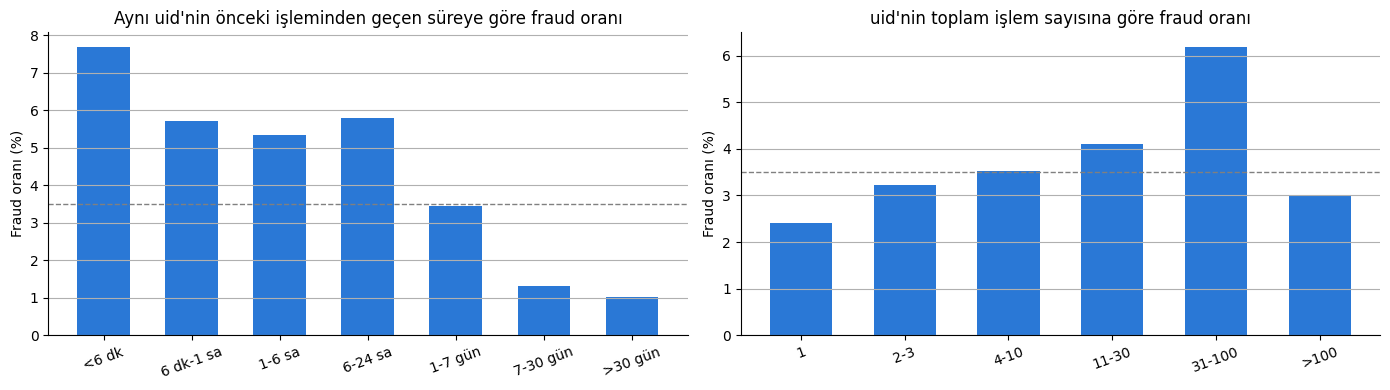

In [33]:
u = df.groupby("uid").agg(n=(TARGET, "size"), fraud=(TARGET, "max"), amt_mean=("TransactionAmt", "mean"),
                          amt_std=("TransactionAmt", "std"), t_min=(TIME, "min"), t_max=(TIME, "max"),
                          n_devices=("device_fp", "nunique"), n_emails=("P_emaildomain", "nunique"))
u["amt_cv"] = u.amt_std / u.amt_mean
u["span_days"] = (u.t_max - u.t_min) / 86400
u["fraud"] = u.fraud.map({0: "Normal uid", 1: "Fraud içeren uid"})
print("uid profili: fraud içeren ve içermeyen kullanıcılar (medyan / ortalama):")
display(u.groupby("fraud").agg(n_uid=("n", "size"), median_tx=("n", "median"), mean_tx=("n", "mean"),
                               median_amt=("amt_mean", "median"), median_amt_cv=("amt_cv", "median"),
                               median_span_days=("span_days", "median"), mean_devices=("n_devices", "mean"),
                               mean_emails=("n_emails", "mean")).round(2).T)

tmp = df[["uid", TIME, TARGET]].sort_values(["uid", TIME])
gap_h = tmp.groupby("uid")[TIME].diff() / 3600
gb = pd.cut(gap_h, [-0.01, 0.1, 1, 6, 24, 24 * 7, 24 * 30, 1e6],
            labels=["<6 dk", "6 dk-1 sa", "1-6 sa", "6-24 sa", "1-7 gün", "7-30 gün", ">30 gün"])
fr_gap = tmp.groupby(gb, observed=False)[TARGET].agg(n="count", fraud_rate="mean")
cnt_b = pd.cut(df.groupby("uid")[TARGET].transform("size"), [0, 1, 3, 10, 30, 100, 1e6],
               labels=["1", "2-3", "4-10", "11-30", "31-100", ">100"])
fr_cnt = df.groupby(cnt_b, observed=False)[TARGET].agg(n="count", fraud_rate="mean")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(fr_gap.index.astype(str), fr_gap.fraud_rate * 100, color=BLUE, width=.6)
axes[0].set_title("Aynı uid'nin önceki işleminden geçen süreye göre fraud oranı")
axes[1].bar(fr_cnt.index.astype(str), fr_cnt.fraud_rate * 100, color=BLUE, width=.6)
axes[1].set_title("uid'nin toplam işlem sayısına göre fraud oranı")
for ax in axes:
    ax.axhline(base_rate * 100, color=INK2, linestyle="--", linewidth=1); ax.set_ylabel("Fraud oranı (%)")
    ax.grid(axis="x", visible=False); ax.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

**Bulgular: Entity davranışı**
- **uid** (card1 + addr1 + D1n) en iyi kullanıcı tahmini: 217.850 uid var ve bunların %57,5'i tek işlemli.
- **Fraud entity düzeyinde yoğunlaşıyor.** uid'lerin yalnızca %3,7'sinde fraud var, ama bu uid'lerdeki işlemlerin **%61'i** fraud. Önceki işlem fraud ise sonrakinin fraud olma olasılığı **%77**; önceki işlem normalse %0,96.
- Fraud içeren uid'ler daha fazla cihaz (ortalama 2,0'a karşı 0,4), daha fazla e-posta (1,6'ya karşı 1,1) ve daha fazla işlem (5,4'e karşı 2,6) kullanıyor. Tutarlarındaki değişkenlik de daha yüksek.
- card1 bir entity olarak çok kaba: önceki işlem fraud ise bu olasılık yalnızca %38,5.

## 2.8 Adım 2 özeti

- Veri **ağır kuyruklu, zero-inflated** ve **eksikliği bilgi taşıyan** bir yapıda. Bu yüzden robust ve rank tabanlı yöntemler kullanılmalı, eksiklik bir sinyal olarak korunmalı.
- C, D ve V kolonlarında yoğun tekrar var. V kolonları 256 temsilciye indirildi.
- **Fraud entity düzeyinde yapışkan.** Bu nedenle kullanıcı (uid) kurgusu ve kullanıcının kendi geçmişine göre sapma, feature engineering ve anomali katmanlarının merkezinde.
- Nadir kategorik kombinasyonlar ve çok kolonlu outlier'lar ek risk sinyalleri.

# ADIM 3: Feature Engineering

Feature'lar dört aileye ayrılıyor. Her biri Adım 4'teki bir anomali katmanını besliyor:

| Aile | Örnek | Hangi sinyali yakalıyor | Kullanıldığı katman |
|---|---|---|---|
| **Temporal** | hour, day_of_week, is_weekend, is_night | Zaman bazlı hareketlilik | Temporal |
| **Entity** | uid_tx_count, uid_avg_amount, amt_zscore_uid, uid_tx_last_24h | Kullanıcı davranışı, işlem sıklığı, işlem sapması | Entity |
| **Relational** | frekanslar, uid_n_devices, device_n_uids, email_match | Varlıklar arası ilişki (paylaşılan cihaz, çoklu e-posta) | Entity / Multivariate |
| **Context** | tutar / ürün medyanı, yeni cihaz, satır null sayısı | İşlemin kendi bağlamına göre olağandışılığı | Column / Multivariate |

**Sızıntı (leakage) önlemi:** Entity feature'ları iki biçimde üretiliyor:
- **Geçmişe dayalı (`_past`):** yalnızca o işlemden **önceki** işlemleri kullanıyor. Gerçek zamanlı skorlama ile birebir uyumlu; anomali katmanlarında bunlar kullanılıyor.
- **Tüm döneme dayalı (`_all`):** case'te örnek olarak verilen `user_avg_amount` ve `user_transaction_count` gibi toplam profiller. Bunlar geleceği de gördüğü için yalnızca batch analizde ve raporlamada kullanılıyor.

In [34]:
FE = pd.DataFrame(index=df.index)
T = df[TIME].to_numpy(dtype="int64")
AMT = df.TransactionAmt.astype("float64")
UID = df.uid.to_numpy()

def past_window_count(groups, t, window):
    """Her işlem için aynı gruptaki son `window` saniyedeki ÖNCEKİ işlem sayısı (vektörize)."""
    order = np.lexsort((t, groups))
    key = groups[order].astype(np.int64) * 10**9 + t[order]
    left = np.searchsorted(key, key - window, side="left")
    first_eq = np.searchsorted(key, key, side="left")  # aynı saniyedeki eş kayıtları sayma
    out = np.empty(len(key), dtype=np.int32); out[order] = first_eq - left
    return out

def auc_strength(x, y=df[TARGET].to_numpy()):
    x = np.asarray(x, dtype="float64"); m = ~np.isnan(x)
    if np.unique(x[m]).size < 2: return np.nan
    a = roc_auc_score(y[m], x[m]); return max(a, 1 - a)

## 3.1 Temporal feature'lar

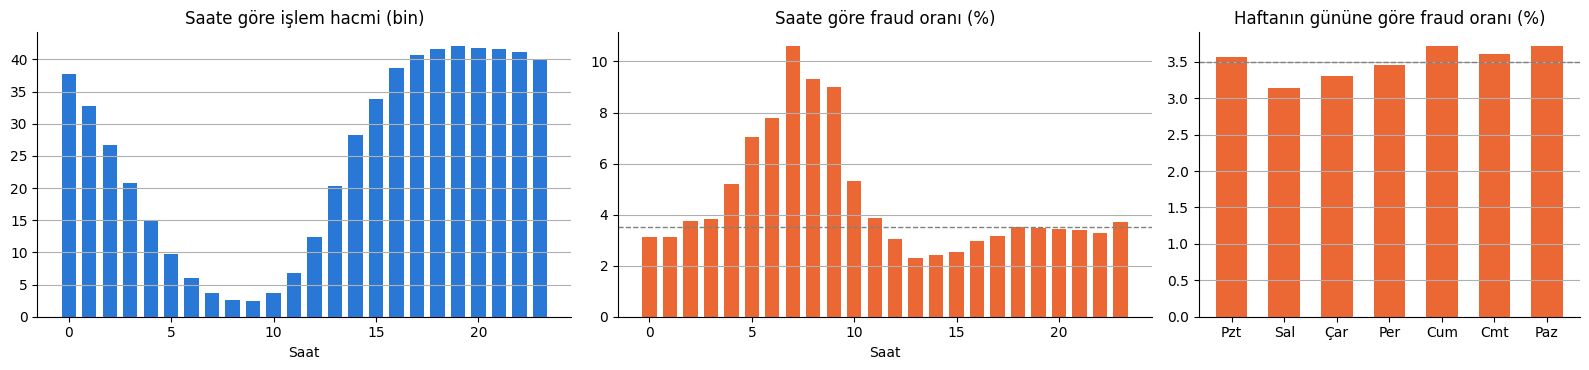

,n,fraud_rate
is_night,,
0,447874,3.39
1,142666,3.83


In [35]:
dt = df.TransactionDateTime
FE["hour"] = dt.dt.hour.astype("int8")
FE["day_of_week"] = dt.dt.dayofweek.astype("int8")
FE["is_weekend"] = (FE.day_of_week >= 5).astype("int8")
FE["is_night"] = FE.hour.between(0, 5).astype("int8")
FE["day_of_month"] = dt.dt.day.astype("int8")
FE["days_since_start"] = DAY
FE["hour_sin"] = np.sin(2 * np.pi * FE.hour / 24).astype("float32")
FE["hour_cos"] = np.cos(2 * np.pi * FE.hour / 24).astype("float32")

hr = df.groupby(FE.hour)[TARGET].agg(n="count", fraud_rate="mean")
dw = df.groupby(FE.day_of_week)[TARGET].agg(n="count", fraud_rate="mean")
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8), gridspec_kw={"width_ratios": [1.4, 1.4, 1]})
axes[0].bar(hr.index, hr.n / 1000, color=BLUE, width=.7); axes[0].set_title("Saate göre işlem hacmi (bin)")
axes[1].bar(hr.index, hr.fraud_rate * 100, color=ORANGE, width=.7); axes[1].set_title("Saate göre fraud oranı (%)")
axes[1].axhline(base_rate * 100, color=INK2, linestyle="--", linewidth=1)
axes[2].bar(["Pzt", "Sal", "Çar", "Per", "Cum", "Cmt", "Paz"], dw.fraud_rate * 100, color=ORANGE, width=.6)
axes[2].axhline(base_rate * 100, color=INK2, linestyle="--", linewidth=1); axes[2].set_title("Haftanın gününe göre fraud oranı (%)")
for ax in axes: ax.grid(axis="x", visible=False)
axes[0].set_xlabel("Saat"); axes[1].set_xlabel("Saat")
plt.tight_layout(); plt.show()
display(df.groupby(FE.is_night)[TARGET].agg(n="count", fraud_rate="mean").assign(fraud_rate=lambda t: (t.fraud_rate*100).round(2)))

## 3.2 Entity feature'lar

In [36]:
g = AMT.groupby(df.uid)
cnt_past = g.cumcount()
csum_past = g.cumsum() - AMT
csq_past = (AMT ** 2).groupby(df.uid).cumsum() - AMT ** 2
mean_past = (csum_past / cnt_past).where(cnt_past > 0)
std_past = np.sqrt((csq_past / cnt_past - mean_past ** 2).clip(lower=0)).where(cnt_past > 1)

FE["uid_tx_count_past"] = cnt_past.astype("int32")
FE["uid_avg_amount_past"] = mean_past.astype("float32")
FE["uid_std_amount_past"] = std_past.astype("float32")
FE["amt_to_uid_avg_past"] = (AMT / mean_past).astype("float32")
FE["amt_zscore_uid_past"] = ((AMT - mean_past) / (std_past + 1)).where(cnt_past >= 2).astype("float32")
FE["uid_secs_since_prev"] = df[TIME].groupby(df.uid).diff().astype("float32")
FE["uid_tx_last_1h"] = past_window_count(UID, T, 3600)
FE["uid_tx_last_24h"] = past_window_count(UID, T, 86400)
FE["uid_tx_last_7d"] = past_window_count(UID, T, 7 * 86400)
FE["uid_age_days"] = ((T - df[TIME].groupby(df.uid).transform("min").to_numpy()) / 86400).astype("float32")
FE["card_age_days"] = df.D1.astype("float32")          # kartın ilk kullanımından beri geçen gün
FE["card1_tx_last_1h"] = past_window_count(df.card1.to_numpy(), T, 3600)

# Tüm dönem profilleri (batch / raporlama)
FE["user_transaction_count"] = g.transform("size").astype("int32")
FE["user_avg_amount"] = g.transform("mean").astype("float32")
FE["user_std_amount"] = g.transform("std").astype("float32")
FE["amt_to_user_avg"] = (AMT / FE.user_avg_amount).astype("float32")
gt = df.groupby("uid")[TIME]
FE["user_active_days"] = ((gt.transform("max") - gt.transform("min")) / 86400).astype("float32")

ENTITY_FEATS = [c for c in FE.columns if c.startswith(("uid_", "amt_to_uid", "amt_zscore", "card_age", "card1_tx", "user_", "amt_to_user"))]
display(FE[ENTITY_FEATS].describe().T.round(2))

,count,mean,std,min,25%,50%,75%,max
uid_tx_count_past,590540.0,6.35,41.55,0.00,0.00,1.00,5.00,1413.00
uid_avg_amount_past,372690.0,126.18,195.47,0.41,49.00,78.97,131.63,21765.72
uid_std_amount_past,280062.0,55.80,116.29,0.00,11.03,27.81,58.34,15257.50
amt_to_uid_avg_past,372690.0,1.22,2.00,0.01,0.63,0.98,1.25,204.00
amt_zscore_uid_past,280062.0,0.45,45.25,-4120.39,-0.82,-0.21,0.72,4014.62
uid_secs_since_prev,372690.0,868078.94,1574759.00,0.00,3568.00,166285.50,1114989.50,15538486.00
uid_tx_last_1h,590540.0,0.45,4.62,0.00,0.00,0.00,0.00,191.00
uid_tx_last_24h,590540.0,1.97,21.46,0.00,0.00,0.00,1.00,880.00
uid_tx_last_7d,590540.0,2.86,27.97,0.00,0.00,0.00,1.00,975.00
uid_age_days,590540.0,23.15,39.52,0.00,0.00,0.58,31.80,181.95


## 3.3 Relational feature'lar

In [37]:
def freq(col):
    s = df[col] if isinstance(col, str) else col
    return s.map(s.value_counts(normalize=True)).astype("float32")

for c in ["card1", "card2", "addr1", "P_emaildomain", "R_emaildomain", "DeviceInfo", "id_31", "uid", "device_fp"]:
    FE[f"{c}_freq"] = freq(c)

FE["uid_n_devices"] = df.groupby("uid").device_fp.transform("nunique").astype("int16")
FE["uid_n_emails"] = df.groupby("uid").P_emaildomain.transform("nunique").astype("int16")
FE["device_n_uids"] = df.groupby("device_fp").uid.transform("nunique").astype("float32")
FE["card1_n_addr1"] = df.groupby("card1").addr1.transform("nunique").astype("int16")
FE["email_n_uids_log"] = np.log1p(df.groupby("P_emaildomain", observed=True).uid.transform("nunique")).astype("float32")
both = df.P_emaildomain.notna() & df.R_emaildomain.notna()
FE["email_match"] = np.where(both, (df.P_emaildomain.astype(str) == df.R_emaildomain.astype(str)).astype(float), np.nan).astype("float32")
FE["is_new_device_for_uid"] = ((df.groupby(["uid", "device_fp"]).cumcount() == 0) & df.device_fp.notna() & (cnt_past > 0)).astype("int8")
FE["is_new_email_for_uid"] = ((df.groupby(["uid", "P_emaildomain"], observed=True).cumcount() == 0) & df.P_emaildomain.notna() & (cnt_past > 0)).astype("int8")
REL_FEATS = [c for c in FE.columns if c.endswith("_freq") or c in
             ["uid_n_devices", "uid_n_emails", "device_n_uids", "card1_n_addr1", "email_n_uids_log", "email_match",
              "is_new_device_for_uid", "is_new_email_for_uid"]]
display(FE[REL_FEATS].describe().T.round(3))

,count,mean,std,min,25%,50%,75%,max
card1_freq,590540.0,0.004,0.006,0.000,0.000,0.002,0.005,0.025
card2_freq,581607.0,0.031,0.031,0.000,0.005,0.017,0.066,0.084
addr1_freq,524834.0,0.043,0.029,0.000,0.016,0.031,0.076,0.088
P_emaildomain_freq,496084.0,0.271,0.184,0.000,0.091,0.203,0.460,0.460
R_emaildomain_freq,137291.0,0.245,0.156,0.000,0.150,0.200,0.416,0.416
DeviceInfo_freq,118666.0,0.205,0.170,0.000,0.016,0.167,0.402,0.402
id_31_freq,140282.0,0.063,0.048,0.000,0.025,0.051,0.096,0.157
uid_freq,590540.0,0.000,0.000,0.000,0.000,0.000,0.000,0.002
device_fp_freq,140581.0,0.007,0.012,0.000,0.000,0.001,0.009,0.045
uid_n_devices,590540.0,1.200,3.842,0.000,0.000,0.000,1.000,45.000


## 3.4 Context feature'lar

In [38]:
FE["amt_log"] = np.log1p(AMT).astype("float32")
FE["amt_cents"] = (np.round(AMT * 1000) % 1000 / 1000).astype("float32")
FE["amt_to_product_median"] = (AMT / AMT.groupby(PRODUCT).transform("median")).astype("float32")
FE["amt_pct_in_product"] = AMT.groupby(PRODUCT).rank(pct=True).astype("float32")
FE["amt_to_hour_median"] = (AMT / AMT.groupby(FE.hour).transform("median")).astype("float32")
FE["amt_pct_in_card6"] = AMT.groupby(df.card6.astype(str)).rank(pct=True).astype("float32")
FE["n_missing_row"] = df.isna().sum(axis=1).astype("int16")
FE["has_identity"] = df.has_identity
FE["os_family"] = df.id_30.astype(str).str.split(" ").str[0].where(df.id_30.notna())
FE["browser_family"] = df.id_31.astype(str).str.replace(r"[\d\.]+", "", regex=True).str.replace("mobile ", "").str.split(" ").str[0].where(df.id_31.notna())
FE["device_brand"] = df.DeviceInfo.astype(str).str.split(r"[ \-_/]").str[0].str.lower().where(df.DeviceInfo.notna())
for c in ["os_family", "browser_family", "device_brand"]:
    print(f"{c}: {df[{'os_family':'id_30','browser_family':'id_31','device_brand':'DeviceInfo'}[c]].nunique()} → {FE[c].nunique()} kategori")
    FE[f"{c}_freq"] = freq(FE[c])
CONTEXT_FEATS = ["amt_log", "amt_cents", "amt_to_product_median", "amt_pct_in_product", "amt_to_hour_median",
                 "amt_pct_in_card6", "n_missing_row", "has_identity", "os_family_freq", "browser_family_freq", "device_brand_freq"]
display(FE[CONTEXT_FEATS].describe().T.round(3))

os_family: 75 → 7 kategori
browser_family: 130 → 39 kategori
device_brand: 1786 → 618 kategori


,count,mean,std,min,25%,50%,75%,max
amt_log,590540.0,4.383,0.937,0.224,3.791,4.245,4.836,10.372
amt_cents,590540.0,0.379,0.434,0.000,0.000,0.000,0.950,0.999
amt_to_product_median,590540.0,1.814,3.039,0.008,0.624,1.000,1.839,406.846
amt_pct_in_product,590540.0,0.500,0.288,0.000,0.255,0.493,0.748,1.000
amt_to_hour_median,590540.0,1.922,3.403,0.004,0.622,1.000,1.889,515.535
amt_pct_in_card6,590540.0,0.500,0.289,0.000,0.253,0.484,0.760,1.000
n_missing_row,590540.0,196.387,49.434,24.000,209.000,212.000,230.000,341.000
has_identity,590540.0,0.244,0.430,0.000,0.000,0.000,0.000,1.000
os_family_freq,77565.0,0.327,0.148,0.000,0.175,0.255,0.474,0.474
browser_family_freq,140282.0,0.374,0.197,0.000,0.266,0.542,0.542,0.542


,count,mean,std,min,25%,50%,75%,max
amt_log,590540.0,4.383,0.937,0.224,3.791,4.245,4.836,10.372
amt_cents,590540.0,0.379,0.434,0.000,0.000,0.000,0.950,0.999
amt_to_product_median,590540.0,1.814,3.039,0.008,0.624,1.000,1.839,406.846
amt_pct_in_product,590540.0,0.500,0.288,0.000,0.255,0.493,0.748,1.000
amt_to_hour_median,590540.0,1.922,3.403,0.004,0.622,1.000,1.889,515.535
amt_pct_in_card6,588969.0,0.500,0.289,0.000,0.253,0.484,0.760,1.000
n_missing_row,590540.0,196.387,49.434,24.000,209.000,212.000,230.000,341.000
has_identity,590540.0,0.244,0.430,0.000,0.000,0.000,0.000,1.000
os_family_freq,77565.0,0.327,0.148,0.000,0.175,0.255,0.474,0.474
browser_family_freq,140282.0,0.374,0.197,0.000,0.266,0.542,0.542,0.542


## 3.5 Feature kataloğu ve katkı kontrolü

Üretilen her feature'ın fraud ile **tek değişkenli ilişkisi** (ROC-AUC, 0,5 = ilişki yok) ölçülerek feature'ların anomali tespitine anlamlı katkı verip vermediği kontrol ediliyor.

,count,mean,max
family,,,
context,11,0.581,0.671
entity,17,0.556,0.640
relational,17,0.592,0.675
temporal,7,0.513,0.538


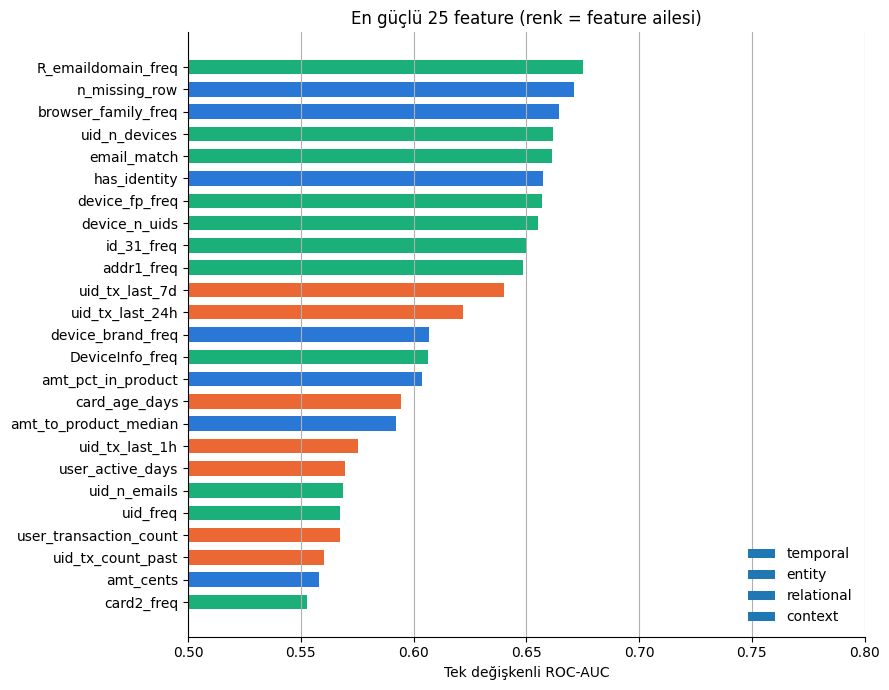

,feature,family,null_pct,auc
0,R_emaildomain_freq,relational,76.8,0.675
1,n_missing_row,context,0.0,0.671
2,browser_family_freq,context,76.2,0.664
3,uid_n_devices,relational,0.0,0.662
4,email_match,relational,78.6,0.661
5,has_identity,context,0.0,0.657
6,device_fp_freq,relational,76.2,0.657
7,device_n_uids,relational,76.2,0.655
8,id_31_freq,relational,76.2,0.650
9,addr1_freq,relational,11.1,0.649


In [39]:
TEMPORAL_FEATS = ["hour", "day_of_week", "is_weekend", "is_night", "day_of_month", "hour_sin", "hour_cos"]
FAMILY = {**{c: "temporal" for c in TEMPORAL_FEATS}, **{c: "entity" for c in ENTITY_FEATS},
          **{c: "relational" for c in REL_FEATS}, **{c: "context" for c in CONTEXT_FEATS}}
cat_rows = []
for c, fam in FAMILY.items():
    cat_rows.append(dict(feature=c, family=fam, null_pct=round(FE[c].isna().mean() * 100, 1),
                         auc=auc_strength(FE[c].astype("float64").fillna(-999))))
feat_cat = pd.DataFrame(cat_rows).sort_values("auc", ascending=False).reset_index(drop=True)
display(feat_cat.groupby("family").auc.agg(["count", "mean", "max"]).round(3))

top = feat_cat.head(25).iloc[::-1]
fam_col = {"temporal": "#eda100", "entity": ORANGE, "relational": "#1baf7a", "context": BLUE}
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top.feature, top.auc, color=[fam_col[f] for f in top.family], height=.65)
ax.set_xlim(.5, max(.8, top.auc.max() + .02)); ax.set_xlabel("Tek değişkenli ROC-AUC")
for f, c in fam_col.items(): ax.barh([], [], color=c, label=f)
ax.legend(frameon=False, loc="lower right"); ax.grid(axis="y", visible=False)
ax.set_title("En güçlü 25 feature (renk = feature ailesi)")
plt.tight_layout(); plt.show()
display(feat_cat.head(20).round(3))

## 3.6 Adım 3 özeti

- 4 aileden **52 feature** üretildi: 7 temporal, 17 entity, 17 relational ve 11 context.
- Tek başına en güçlü feature'lar: `R_emaildomain_freq` (AUC 0,675), `n_missing_row` (0,671), `uid_n_devices` (0,662), `has_identity` (0,657) ve `device_n_uids` (0,655). Entity tarafında hız feature'ları öne çıkıyor: `uid_tx_last_7d` 0,64.
- Temporal feature'lar tek başına zayıf (en yüksek AUC 0,54). Gece fraud oranı %3,8, gündüz %3,4. Saat bilgisi varsayılan bir referans noktasına göre hesaplandığı için göreli yorumlanmalı.
- Anomali katmanlarında yalnızca **geçmişe dayalı (`_past`)** entity feature'ları kullanılıyor; `user_*` profilleri raporlama içindir.

# ADIM 4: Multi-Layer Anomali Detection Engine

Dört katman birbirinden bağımsız çalışıyor. Her biri kendi perspektifinden bir skor (yüksek = daha anormal) ve **okunabilir bir gerekçe** üretiyor:

| Katman | Soru | Yöntem | Açıklama nasıl üretiliyor |
|---|---|---|---|
| **Column** | Bu işlemin tek tek alanları olağandışı mı? | Sayısal alanlarda robust z (medyan/MAD), kategorik alanlarda nadirlik (−log frekans) | En anormal kolon ve değeri |
| **Multivariate** | Alanların **birlikteliği** olağandışı mı? | Isolation Forest + PCA rekonstrüksiyon hatası (ensemble) | Rekonstrüksiyon hatasına en çok katkı veren feature'lar |
| **Entity** | Bu işlem, **kullanıcının kendi geçmişine** göre olağandışı mı? | Kullanıcının geçmişine göre sapma, hız, yeni cihaz/e-posta, paylaşılan cihaz, yeni kart | En güçlü entity sinyali |
| **Temporal** | **Zamanlama** olağandışı mı? | Saat nadirliği, kullanıcının alışılmış saatinden sapma, ani yoğunlaşma (burst), segment hacim sıçraması | En güçlü zaman sinyali |

**Ortak yapı:** Her bileşen sinyal önce `tail_score` ile 0–1 aralığına taşınıyor: 0 = olağan; değer arttıkça daha nadir. Katman skoru, en güçlü 2–3 bileşenin ortalaması. Bu sayede tek bir aşırı sinyal yakalanıyor ve sinyaller birbirini seyreltmiyor.

**Etiket kullanılmıyor.** `isFraud` yalnızca 4.6'da katmanların başarısını ölçmek için kullanılıyor.

In [40]:
def tail_score(x):
    """0 = olağan; >0 değerler için yüzdelik sıra (0–1]. NaN/0 → 0."""
    x = pd.Series(np.asarray(x, dtype="float64")).fillna(0).clip(lower=0)
    out = np.zeros(len(x)); m = x > 0
    out[m.to_numpy()] = x[m].rank(pct=True).to_numpy()
    return out

def top_k_mean(M, k):
    return np.sort(M, axis=1)[:, -k:].mean(axis=1)

def reason_from(M, names, raw=None, fmt="{name}"):
    idx = M.argmax(axis=1); mx = M.max(axis=1)
    names = np.asarray(names)
    r = names[idx].astype(object)
    if raw is not None:
        vals = raw[np.arange(len(idx)), idx]
        r = np.array([f"{n}={v:.3g}" for n, v in zip(r, vals)], dtype=object)
    r[mx == 0] = "—"
    return r

def evaluate(score, name, y=df[TARGET].to_numpy(), mask=None):
    s = np.asarray(score); yy = y
    if mask is not None: s, yy = s[mask], y[mask]
    k = max(1, int(len(s) * .01)); top = np.argpartition(-s, k)[:k]
    return dict(layer=name, roc_auc=roc_auc_score(yy, s), pr_auc=average_precision_score(yy, s),
                precision_top1pct=yy[top].mean(), lift_top1pct=yy[top].mean() / yy.mean())
LAYERS, REASONS, COMPONENTS = {}, {}, {}

## 4.1 Column anomali katmanı

- **Sayısal alanlar:** Çarpık kolonlar log1p ile dönüştürülüyor, ardından `z = |x − medyan| / (1,4826·MAD)` hesaplanıyor. MAD = 0 ise yedek ölçek olarak (p90 − p10)/2,563 kullanılıyor. C kolonlarında yalnızca **üst kuyruk** dikkate alınıyor, çünkü çok sayıda adres veya kart anormal kabul ediliyor. Diğer kolonlarda iki yönlü bakılıyor.
- **Kategorik alanlar:** nadirlik = −log10(frekans). Eksik değer nadir sayılmıyor.
- **Katman skoru:** en anormal 3 kolonun `tail_score` ortalaması. **Gerekçe:** en anormal kolon ve robust z / nadirlik değeri.

In [41]:
COL_NUM = ["TransactionAmt", "dist1", "C1", "C2", "C5", "C6", "C9", "C11", "C13", "C14",
           "D1", "D2", "D3", "D4", "D10", "D15", "id_01", "id_02"]
COL_CAT = ["ProductCD", "card4", "card6", "card1", "addr1", "addr2", "P_emaildomain", "R_emaildomain",
           "DeviceInfo", "id_30", "id_31", "M4", "M6"]
Z = np.zeros((len(df), len(COL_NUM) + len(COL_CAT)), dtype="float32")
for j, c in enumerate(COL_NUM):
    x = df[c].astype("float64")
    if x.min() >= 0 and x.skew() > 2: x = np.log1p(x)
    med = x.median(); scale = (x - med).abs().median() * 1.4826
    if not scale: scale = (x.quantile(.9) - x.quantile(.1)) / 2.563
    if not scale: scale = x.std() or 1.0
    d = (x - med) / scale
    Z[:, j] = (d.clip(lower=0) if c.startswith("C") else d.abs()).fillna(0).to_numpy()
for k, c in enumerate(COL_CAT):
    f = df[c].map(df[c].value_counts(normalize=True)).astype("float64")
    Z[:, len(COL_NUM) + k] = (-np.log10(f)).fillna(0).to_numpy()

COL_NAMES = COL_NUM + COL_CAT
S_col = np.column_stack([tail_score(Z[:, j]) for j in range(Z.shape[1])])
LAYERS["column"] = top_k_mean(S_col, 3)
REASONS["column"] = reason_from(S_col, COL_NAMES, raw=Z)
print("Column skoru özet:"); display(pd.Series(LAYERS["column"]).describe().round(3).to_frame("column_score").T)
print("En sık 'en anormal kolon' (skor > p99 olan işlemlerde):")
hi = LAYERS["column"] > np.quantile(LAYERS["column"], .99)
display(pd.Series(np.asarray(COL_NAMES)[S_col[hi].argmax(axis=1)]).value_counts().head(10).to_frame("adet"))

Column skoru özet:


,count,mean,std,min,25%,50%,75%,max
column_score,590540.0,0.845,0.102,0.382,0.797,0.865,0.918,1.0


En sık 'en anormal kolon' (skor > p99 olan işlemlerde):


,adet
D1,1657
D10,788
C2,763
D4,680
C14,406
C1,351
addr2,243
C9,195
C5,187
P_emaildomain,147


## 4.2 Multivariate anomali katmanı

Tek tek bakıldığında normal görünen alanların **kombinasyonu** olağandışı olabilir. Örneğin küçük tutar, yeni kart, gece saati ve çok sayıda adres aynı anda görülüyor olabilir. Bu katmanda iki farklı algoritma bir **ensemble** olarak kullanılıyor:
1. **Isolation Forest:** Rastgele bölmelerle az adımda izole edilebilen noktalar anormaldir. Ölçekten ve dağılım varsayımından bağımsız çalışır.
2. **PCA rekonstrüksiyon hatası:** Verinin ana yapısıyla açıklanamayan noktalar anormaldir. Her feature'ın hataya katkısı doğrudan hesaplanabildiği için **açıklanabilirlik** sağlar.

Girdi: seçilmiş context, entity ve relational feature'lar, ayrıca §2.6'da seçilen V temsilcilerinin PCA'dan geçirilmiş 10 bileşeni. Tüm girdiler robust ölçeklendiriliyor ve [−10, 10] aralığına kırpılıyor. Modeller 150 bin satırlık bir örneklemle eğitiliyor ve tüm veri skorlanıyor.

In [42]:
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler, StandardScaler

# V temsilcileri → 10 bileşen
Vx = df[V_REPRESENTATIVES].astype("float32")
Vx = np.sign(Vx) * np.log1p(Vx.abs())
Vx = Vx.fillna(-1).to_numpy()
fit_idx = rng.choice(len(df), 150_000, replace=False)
v_scaler = StandardScaler().fit(Vx[fit_idx])
v_pca = PCA(n_components=10, random_state=42).fit(v_scaler.transform(Vx[fit_idx]))
VP = v_pca.transform(v_scaler.transform(Vx)).astype("float32")
print(f"V PCA: {len(V_REPRESENTATIVES)} kolon → 10 bileşen, açıklanan varyans = {v_pca.explained_variance_ratio_.sum():.2%}")
del Vx

MV_FEATS = ["amt_log", "amt_to_product_median", "amt_cents", "hour_sin", "hour_cos", "card_age_days",
            "uid_tx_count_past", "amt_to_uid_avg_past", "uid_tx_last_24h", "uid_n_devices", "uid_n_emails",
            "device_n_uids", "card1_freq", "addr1_freq", "P_emaildomain_freq", "card1_n_addr1",
            "n_missing_row", "has_identity", "email_match"]
MV_RAW = ["C1", "C2", "C5", "C9", "C13", "C14", "D2", "D4", "D10", "D15", "dist1"]
X = pd.concat([FE[MV_FEATS], df[MV_RAW]], axis=1).astype("float64")
for c in ["uid_tx_count_past", "uid_tx_last_24h", "device_n_uids", "card1_n_addr1"] + MV_RAW:
    X[c] = np.log1p(X[c].clip(lower=0))
X["is_credit"] = (df.card6 == "credit").astype(float)
X["is_mobile"] = (df.DeviceType == "mobile").astype(float)
for p in ["W", "C", "R", "H", "S"]:
    X[f"product_{p}"] = (PRODUCT == p).astype(float)
MV_MEDIANS = X.median()
X = X.fillna(MV_MEDIANS)
MV_NAMES = list(X.columns) + [f"V_pc{i+1}" for i in range(10)]
X = np.hstack([X.to_numpy(), VP])
mv_scaler = RobustScaler().fit(X[fit_idx])
X = np.clip(mv_scaler.transform(X), -10, 10).astype("float32")
print("Multivariate girdi matrisi:", X.shape)

V PCA: 256 kolon → 10 bileşen, açıklanan varyans = 82.92%
Multivariate girdi matrisi: (590540, 47)


Multivariate girdi matrisi: (590540, 47)


In [43]:
iso = IsolationForest(n_estimators=200, max_samples=512, random_state=42, n_jobs=-1).fit(X[fit_idx])
if_score = -iso.score_samples(X)

pca_mv = PCA(n_components=0.90, random_state=42).fit(X[fit_idx])
recon = pca_mv.inverse_transform(pca_mv.transform(X))
contrib = (X - recon) ** 2
pca_err = contrib.sum(axis=1)
print(f"PCA: {X.shape[1]} boyut → {pca_mv.n_components_} bileşen (%90 varyans)")

p_if = pd.Series(if_score).rank(pct=True).to_numpy()
p_pca = pd.Series(pca_err).rank(pct=True).to_numpy()
LAYERS["multivariate"] = (p_if + p_pca) / 2
COMPONENTS["multivariate"] = {"isolation_forest": p_if, "pca_reconstruction": p_pca}
top2 = np.argsort(-contrib, axis=1)[:, :2]
mvn = np.asarray(MV_NAMES)
REASONS["multivariate"] = np.char.add(np.char.add(mvn[top2[:, 0]], " + "), mvn[top2[:, 1]]).astype(object)
print(f"IF ve PCA skorları arası Spearman: {stats.spearmanr(if_score, pca_err)[0]:.3f}")
hi = LAYERS["multivariate"] > np.quantile(LAYERS["multivariate"], .99)
print("Multivariate skoru en yüksek %1'lik dilimde hataya en çok katkı veren feature'lar:")
display(pd.Series(mvn[top2[hi, 0]]).value_counts().head(10).to_frame("adet"))

PCA: 47 boyut → 14 bileşen (%90 varyans)
IF ve PCA skorları arası Spearman: 0.609
Multivariate skoru en yüksek %1'lik dilimde hataya en çok katkı veren feature'lar:


,adet
C5,1950
V_pc9,1460
V_pc3,947
V_pc5,674
uid_n_emails,393
V_pc6,141
C2,111
uid_tx_last_24h,106
V_pc4,48
card_age_days,38


,adet
C5,1950
V_pc9,1460
V_pc3,947
V_pc5,674
uid_n_emails,394
V_pc6,141
C2,111
uid_tx_last_24h,106
V_pc4,48
card_age_days,38


## 4.3 Entity anomali katmanı

Bu katman, işlemi **kullanıcının (uid) kendi geçmişiyle** ve ilişkili varlıklarla karşılaştırıyor. Tüm bileşenler geçmişe dayalı (`_past`), yani gerçek zamanlı skorlamaya uygun:

| Bileşen | Sinyal |
|---|---|
| `amount_deviation` | Tutarın kullanıcının geçmiş ortalamasından sapması (z), en az 2 geçmiş işlem varsa |
| `velocity_24h` | Son 24 saatteki işlem sayısı |
| `rapid_succession` | Önceki işlemden çok kısa süre sonra gelen işlem (1 / (1 + dakika)) |
| `new_device` / `new_email` | Geçmişi olan kullanıcıda ilk kez görülen cihaz veya e-posta |
| `shared_device` | Cihaz parmak izinin başka kullanıcılarca da kullanılması |
| `multi_device_email` | Kullanıcının çok sayıda cihaz veya e-posta kullanması |
| `new_card` | Kartın ilk kullanımından beri geçen gün sayısının çok az olması (1 / (1 + D1)) |

**Katman skoru:** en güçlü 2 bileşenin `tail_score` ortalaması.

In [44]:
ent_comp = {
    "amount_deviation": FE.amt_zscore_uid_past.abs().clip(upper=50),
    "velocity_24h": FE.uid_tx_last_24h,
    "rapid_succession": 1 / (1 + FE.uid_secs_since_prev / 60),
    "new_device": FE.is_new_device_for_uid,
    "new_email": FE.is_new_email_for_uid,
    "shared_device": (FE.device_n_uids - 1).clip(lower=0),
    "multi_device_email": (FE.uid_n_devices.clip(lower=1) - 1) + (FE.uid_n_emails.clip(lower=1) - 1),
    "new_card": 1 / (1 + FE.card_age_days),
}
E_raw = np.column_stack([np.asarray(v, dtype="float64") for v in ent_comp.values()])
S_ent = np.column_stack([tail_score(E_raw[:, j]) for j in range(E_raw.shape[1])])
LAYERS["entity"] = top_k_mean(S_ent, 2)
REASONS["entity"] = reason_from(S_ent, list(ent_comp.keys()), raw=np.nan_to_num(E_raw))
COMPONENTS["entity"] = dict(zip(ent_comp.keys(), S_ent.T))
display(pd.DataFrame({k: [(v > 0).mean() * 100, auc_strength(np.nan_to_num(np.asarray(v, dtype=float)))]
                      for k, v in ent_comp.items()}, index=["aktif_oran_pct", "tek_başına_auc"]).T.round(3))

,aktif_oran_pct,tek_başına_auc
amount_deviation,45.234,0.536
velocity_24h,28.951,0.622
rapid_succession,63.110,0.617
new_device,6.135,0.539
new_email,7.541,0.500
shared_device,22.751,0.653
multi_device_email,33.736,0.607
new_card,99.785,0.595


## 4.4 Temporal anomali katmanı

| Bileşen | Sinyal |
|---|---|
| `hour_rarity` | İşlemin saatinin genel dağılımda ne kadar nadir olduğu (−log p(saat)) |
| `hour_deviation_uid` | Kullanıcının alışılmış saatinden dairesel sapma (en az 3 geçmiş işlem varsa) |
| `burst_1h_uid` | Kullanıcının son 1 saatteki işlem sayısı |
| `burst_1h_card1` | Aynı kart grubunda (card1) son 1 saatteki işlem yoğunluğu, kart grubunun ortalama saatlik hacmine göre |
| `segment_volume_spike` | İşlemin ProductCD segmentinde o saatteki hacmin, önceki 7 günün (168 saat) medyanına oranı |

**Katman skoru:** en güçlü 2 bileşenin `tail_score` ortalaması.

In [45]:
hour = FE.hour.to_numpy()
p_hour = pd.Series(hour).map(pd.Series(hour).value_counts(normalize=True)).to_numpy()
hour_rarity = -np.log(p_hour); hour_rarity = hour_rarity - hour_rarity.min()

ang = 2 * np.pi * hour / 24
s_cum = pd.Series(np.sin(ang)).groupby(df.uid.values).cumsum().to_numpy() - np.sin(ang)
c_cum = pd.Series(np.cos(ang)).groupby(df.uid.values).cumsum().to_numpy() - np.cos(ang)
mean_hour = (np.arctan2(s_cum, c_cum) % (2 * np.pi)) * 24 / (2 * np.pi)
dh = np.abs(hour - mean_hour); dh = np.minimum(dh, 24 - dh)
hour_dev = np.where(FE.uid_tx_count_past.to_numpy() >= 3, dh, 0)

card1_rate_h = df.groupby("card1")[TIME].transform(lambda s: len(s) / max((s.max() - s.min()) / 3600, 1)).to_numpy()
burst_card1 = FE.card1_tx_last_1h.to_numpy() / (card1_rate_h + 1e-3)

hidx = (df[TIME] // 3600).astype("int64")
hourly = df.groupby([PRODUCT, hidx]).size().unstack(0, fill_value=0)
hourly = hourly.reindex(range(hidx.min(), hidx.max() + 1), fill_value=0)
base = hourly.rolling(168, min_periods=24).median().shift(1)
ratio = ((hourly + 1) / (base + 1)).to_numpy()
col_pos = {p: i for i, p in enumerate(hourly.columns)}
seg_spike = ratio[(hidx - hidx.min()).to_numpy(), PRODUCT.map(col_pos).to_numpy()]
seg_spike = np.log(np.nan_to_num(seg_spike, nan=1.0)).clip(min=0)

tmp_comp = {"hour_rarity": hour_rarity, "hour_deviation_uid": hour_dev, "burst_1h_uid": FE.uid_tx_last_1h.to_numpy(),
            "burst_1h_card1": burst_card1, "segment_volume_spike": seg_spike}
T_raw = np.column_stack([np.asarray(v, dtype="float64") for v in tmp_comp.values()])
S_tmp = np.column_stack([tail_score(T_raw[:, j]) for j in range(T_raw.shape[1])])
LAYERS["temporal"] = top_k_mean(S_tmp, 2)
REASONS["temporal"] = reason_from(S_tmp, list(tmp_comp.keys()), raw=T_raw)
COMPONENTS["temporal"] = dict(zip(tmp_comp.keys(), S_tmp.T))
display(pd.DataFrame({k: [(np.asarray(v) > 0).mean() * 100, auc_strength(np.asarray(v, dtype=float))]
                      for k, v in tmp_comp.items()}, index=["aktif_oran_pct", "tek_başına_auc"]).T.round(3))

,aktif_oran_pct,tek_başına_auc
hour_rarity,92.868,0.525
hour_deviation_uid,37.431,0.541
burst_1h_uid,15.810,0.575
burst_1h_card1,41.867,0.556
segment_volume_spike,79.736,0.532


## 4.5 Katman skorları: ayrı ayrı üretim ve açıklanabilirlik

Her işlem için dört ayrı ham skor ve dört ayrı gerekçe üretildi. Bu bölümde katmanların ne kadar **farklı** şeyler yakaladığına bakılıyor: korelasyonları ve en yüksek skorlu işlemlerin ne kadar örtüştüğü.

Katman skorları arası Spearman korelasyonu:


,column_score,multivariate_score,entity_score,temporal_score
column_score,1.000,0.423,-0.071,0.057
multivariate_score,0.423,1.000,0.448,0.335
entity_score,-0.071,0.448,1.000,0.354
temporal_score,0.057,0.335,0.354,1.000


En yüksek %1'lik dilimlerin örtüşmesi (Jaccard değil; satırdaki katmanın top-%1'inin sütundakiyle kesişim oranı):


,column,multivariate,entity,temporal
column,1.000,0.283,0.008,0.014
multivariate,0.283,1.000,0.238,0.268
entity,0.008,0.238,1.000,0.229
temporal,0.014,0.268,0.229,1.000


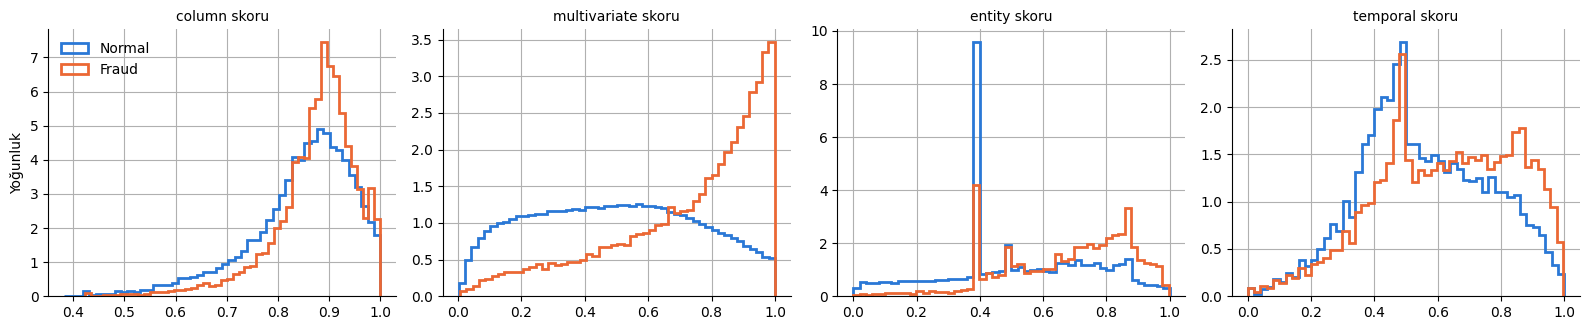

Örnek: column skoru en yüksek 5 işlem ve dört katmanın gerekçeleri


,TransactionID,TransactionAmt,ProductCD,isFraud,column_score,multivariate_score,entity_score,temporal_score,column_reason,multivariate_reason,entity_reason,temporal_reason
0,3043062,41.509998,C,0,1.0,0.996,0.831,0.697,C1=14.3,C5 + C2,multi_device_email=11,segment_volume_spike=0.717
1,3043048,16.091000,C,0,1.0,0.995,0.947,0.800,C2=14.7,C5 + C1,velocity_24h=20,segment_volume_spike=0.764
2,3043040,29.850000,C,1,1.0,0.994,0.851,0.943,C13=6.41,C5 + C2,amount_deviation=4.14,burst_1h_card1=120
3,3043032,60.866001,C,0,1.0,0.996,0.983,0.924,C1=14.3,C5 + C1,velocity_24h=61,burst_1h_uid=14
4,3043016,76.023003,C,0,1.0,0.989,0.754,0.637,C2=14.7,C5 + C1,new_card=1,segment_volume_spike=0.764


In [46]:
layer_df = pd.DataFrame({f"{k}_score": v for k, v in LAYERS.items()})
reason_df = pd.DataFrame({f"{k}_reason": v for k, v in REASONS.items()})
print("Katman skorları arası Spearman korelasyonu:")
display(layer_df.corr(method="spearman").round(3))

top1 = {k: set(np.argsort(-v)[: len(v) // 100]) for k, v in LAYERS.items()}
ov = pd.DataFrame({a: {b: len(top1[a] & top1[b]) / len(top1[a]) for b in top1} for a in top1}).round(3)
print("En yüksek %1'lik dilimlerin örtüşmesi (Jaccard değil; satırdaki katmanın top-%1'inin sütundakiyle kesişim oranı):")
display(ov)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.4))
for ax, (k, v) in zip(axes, LAYERS.items()):
    ax.hist(v[df[TARGET] == 0], bins=50, density=True, histtype="step", linewidth=2, color=BLUE, label="Normal")
    ax.hist(v[df[TARGET] == 1], bins=50, density=True, histtype="step", linewidth=2, color=ORANGE, label="Fraud")
    ax.set_title(f"{k} skoru", fontsize=10)
axes[0].legend(frameon=False); axes[0].set_ylabel("Yoğunluk")
plt.tight_layout(); plt.show()

print("Örnek: column skoru en yüksek 5 işlem ve dört katmanın gerekçeleri")
ex = np.argsort(-LAYERS["column"])[:5]
display(pd.concat([df[[KEY, "TransactionAmt", "ProductCD", TARGET]].iloc[ex].reset_index(drop=True),
                   layer_df.iloc[ex].round(3).reset_index(drop=True), reason_df.iloc[ex].reset_index(drop=True)], axis=1))

## 4.6 Katman bazlı değerlendirme (etiketle doğrulama)

Skorlar etiketsiz üretildi. Burada `isFraud` ile ölçülüyor: ROC-AUC, PR-AUC (taban değer = %3,5) ve en yüksek %1'lik dilimdeki fraud oranı (precision@1%) ile **lift**.

In [47]:
ev = pd.DataFrame([evaluate(v, k) for k, v in LAYERS.items()]
                  + [evaluate(v, f"  └ {k}") for k, v in COMPONENTS["multivariate"].items()]).set_index("layer")
display(ev.round(4))

,roc_auc,pr_auc,precision_top1pct,lift_top1pct
layer,,,,
column,0.5792,0.0424,0.0428,1.2245
multivariate,0.7477,0.1104,0.1761,5.0335
entity,0.6923,0.0649,0.0545,1.5584
temporal,0.5959,0.0513,0.0779,2.2264
└ isolation_forest,0.7327,0.0867,0.1207,3.4508
└ pca_reconstruction,0.7255,0.1014,0.1732,4.9512


**Bulgular: Adım 4**

- **Multivariate** katman en güçlüsü: AUC 0,748, en yüksek %1'lik dilimde fraud oranı %17,6 (**lift 5,0**). Bunu entity (0,692), temporal (0,596) ve column (0,579) izliyor.
- Katmanlar **farklı şeyler yakalıyor.** Aralarındaki korelasyon düşük (column–entity −0,07) ve en yüksek %1'lik dilimleri en fazla %28 örtüşüyor. Bu, çok katmanlı mimarinin gerekçesi.
- Column katmanı tek başına zayıf. En yüksek skorlarını yüksek C sayaçlı, yoğun hacimli C ürünü işlemleri alıyor. Bu işlemler meşru da olabilir, dolayısıyla context katmanında ele alınmalı.
- Her işlem için her katmandan okunabilir bir gerekçe üretiliyor. Örnekler: `C1=14.3`, `velocity_24h=61`, `C5 + C2`.

# ADIM 5: Score Aggregation

1. **Normalizasyon:** Dört katmanın skorları farklı ölçek ve dağılımlarda. Üç yöntem karşılaştırılıyor.
2. **Weighted aggregation:** Dört farklı ağırlık stratejisi deneniyor: eşit, uzman, veri güdümlü ve max.
3. **Final raw anomali skoru:** 0–100 aralığında tek bir risk skoru.

**Doğrulama tasarımı (sızıntısız):** Ağırlıklar yalnızca **kalibrasyon döneminde** (ilk 120 gün) belirleniyor, karşılaştırma ise **test döneminde** (son 62 gün) yapılıyor.

## 5.1 Normalizasyon

| Yöntem | Formül | Sorun / avantaj |
|---|---|---|
| Min-max | (x − min) / (max − min) | Tek bir aşırı değer tüm skorları sıfıra yakın bir aralığa sıkıştırır |
| Z-score | (x − μ) / σ | Normal dağılım varsayar; ağır kuyruklu skorlarda bir katman diğerlerini domine eder |
| **Rank / ECDF** | Yüzdelik sıra (0–1) | Ölçekten bağımsız, aykırı değerlere dayanıklı ve **yorumlanabilir**: "0,99 = bu işlem, işlemlerin %99'undan daha anormal" |

median                       p99                       max                   share_below_0_1                  
method       min-max rank/ECDF z-score min-max rank/ECDF z-score min-max rank/ECDF z-score         min-max rank/ECDF z-score
layer                                                                                                                       
column         0.781     0.500   0.193   0.990      0.99   1.455     1.0       1.0   1.514           0.003       0.1     NaN
entity         0.497     0.493  -0.112   0.971      0.99   1.888     1.0       1.0   2.008           0.046       0.1     NaN
multivariate   0.498     0.500  -0.003   0.984      0.99   1.869     1.0       1.0   1.930           0.059       0.1     NaN
temporal       0.535     0.500  -0.114   0.964      0.99   2.002     1.0       1.0   2.177           0.010       0.1     NaN

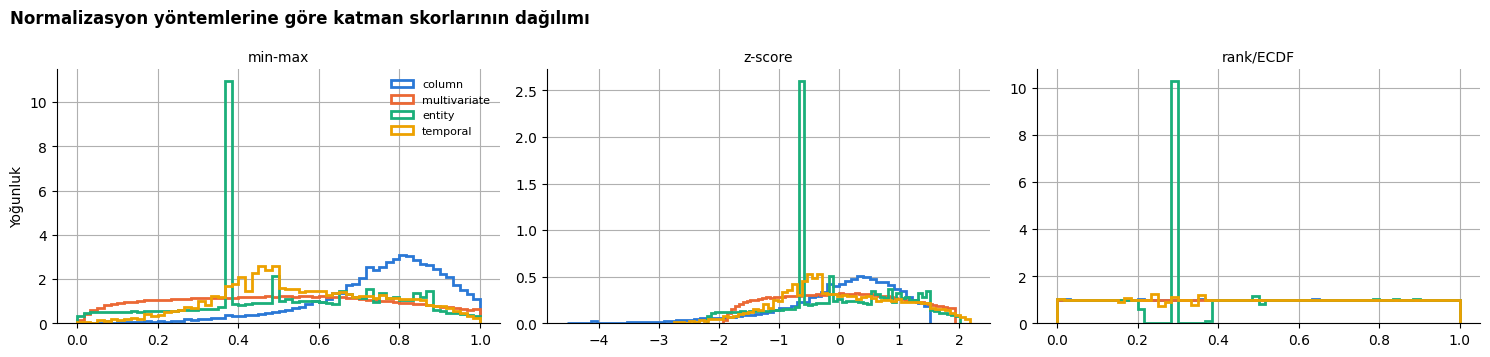

Z-score ile normalize edildiğinde, işlemin en yüksek katmanının hangi katman olduğu (dominasyon):


,oran
column,0.304
entity,0.259
temporal,0.255
multivariate,0.182


In [48]:
def norm_minmax(x): return (x - x.min()) / (x.max() - x.min())
def norm_z(x): return (x - x.mean()) / x.std()
def norm_rank(x): return pd.Series(x).rank(pct=True).to_numpy()

NORM = {k: norm_rank(v) for k, v in LAYERS.items()}
cmp = []
for k, v in LAYERS.items():
    for nm, f in [("min-max", norm_minmax), ("z-score", norm_z), ("rank/ECDF", norm_rank)]:
        n = f(v); cmp.append(dict(layer=k, method=nm, median=np.median(n), p99=np.quantile(n, .99), max=n.max(),
                                  share_below_0_1=(n < .1).mean() if nm != "z-score" else np.nan))
display(pd.DataFrame(cmp).pivot(index="layer", columns="method").round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, (nm, f) in zip(axes, [("min-max", norm_minmax), ("z-score", norm_z), ("rank/ECDF", norm_rank)]):
    for (k, v), col in zip(LAYERS.items(), [BLUE, ORANGE, "#1baf7a", "#eda100"]):
        ax.hist(f(v), bins=60, density=True, histtype="step", linewidth=2, color=col, label=k)
    ax.set_title(nm, fontsize=10)
axes[0].legend(frameon=False, fontsize=8); axes[0].set_ylabel("Yoğunluk")
plt.suptitle("Normalizasyon yöntemlerine göre katman skorlarının dağılımı", x=.01, ha="left", fontweight="bold")
plt.tight_layout(); plt.show()

z_mix = np.column_stack([norm_z(v) for v in LAYERS.values()])
print("Z-score ile normalize edildiğinde, işlemin en yüksek katmanının hangi katman olduğu (dominasyon):")
display(pd.Series(np.array(list(LAYERS))[z_mix.argmax(axis=1)]).value_counts(normalize=True).round(3).to_frame("oran"))

**Bulgular: Normalizasyon**
- **Min-max** dağılımları hizalamıyor. Medyan column katmanında 0,78, diğer katmanlarda yaklaşık 0,5; bu durumda column katmanı yapay olarak baskın çıkar.
- **Z-score** ile column katmanı satırların %30'unda en yüksek katman oluyor.
- **Rank/ECDF** tüm katmanları aynı tekdüze [0,1] ölçeğine taşıyor. Bu yüzden **rank/ECDF seçildi.**

## 5.2 Weighted aggregation

`final = Σ wᵢ · pᵢ` (pᵢ = katmanın rank-normalize skoru, Σ wᵢ = 1)

| Strateji | Ağırlıklar | Mantık |
|---|---|---|
| Eşit | 0,25 × 4 | Önsel bilgi yok |
| Uzman | entity 0,35 · multivariate 0,30 · column 0,15 · temporal 0,20 | Fraud literatürü: kullanıcı davranışından sapma ve çok boyutlu tutarsızlık en güvenilir sinyaller; tek kolon sapması gürültülü |
| **Veri güdümlü** | wᵢ ∝ max(AUCᵢ − 0,5; 0)², **kalibrasyon döneminde** | Katmanın ayırt edicilik gücüyle orantılı; kare alma zayıf katmanların etkisini azaltır |
| Max | max(pᵢ) | Herhangi bir katmanın alarmı yeterli (en hassas, en gürültülü yaklaşım) |

In [49]:
y = df[TARGET].to_numpy()
calib = DAY.to_numpy() < 120
test = ~calib
P = np.column_stack(list(NORM.values())); L = list(NORM)
print(f"Kalibrasyon: {calib.sum():,} işlem (fraud %{y[calib].mean()*100:.2f}) | Test: {test.sum():,} işlem (fraud %{y[test].mean()*100:.2f})")

calib_auc = {k: roc_auc_score(y[calib], NORM[k][calib]) for k in L}
raw_w = np.array([max(calib_auc[k] - .5, 0) ** 2 for k in L])
W = {
    "equal": np.full(len(L), .25),
    "expert": np.array([{"column": .15, "multivariate": .30, "entity": .35, "temporal": .20}[k] for k in L]),
    "data_driven": raw_w / raw_w.sum(),
}
display(pd.DataFrame(W, index=L).assign(calib_auc=pd.Series(calib_auc)).round(3))

AGG = {name: P @ w for name, w in W.items()}
AGG["max"] = P.max(axis=1)
res = [evaluate(NORM[k], f"layer:{k}", mask=test) for k in L] + [evaluate(v, f"agg:{n}", mask=test) for n, v in AGG.items()]
res = pd.DataFrame(res).set_index("layer")
print("TEST dönemi performansı (ağırlıklar bu dönemi görmedi):")
display(res.round(4))

Kalibrasyon: 410,601 işlem (fraud %3.51) | Test: 179,939 işlem (fraud %3.47)


,equal,expert,data_driven,calib_auc
column,0.25,0.15,0.059,0.582
multivariate,0.25,0.30,0.536,0.748
entity,0.25,0.35,0.318,0.691
temporal,0.25,0.20,0.086,0.600


TEST dönemi performansı (ağırlıklar bu dönemi görmedi):


,roc_auc,pr_auc,precision_top1pct,lift_top1pct
layer,,,,
layer:column,0.5723,0.0395,0.0289,0.8330
layer:multivariate,0.7470,0.1035,0.0934,2.6912
layer:entity,0.6960,0.0648,0.0289,0.8330
layer:temporal,0.5874,0.0478,0.0295,0.8490
agg:equal,0.7178,0.0845,0.0995,2.8674
agg:expert,0.7358,0.0873,0.0667,1.9223
agg:data_driven,0.7534,0.0951,0.0728,2.0985
agg:max,0.6662,0.0581,0.0172,0.4966


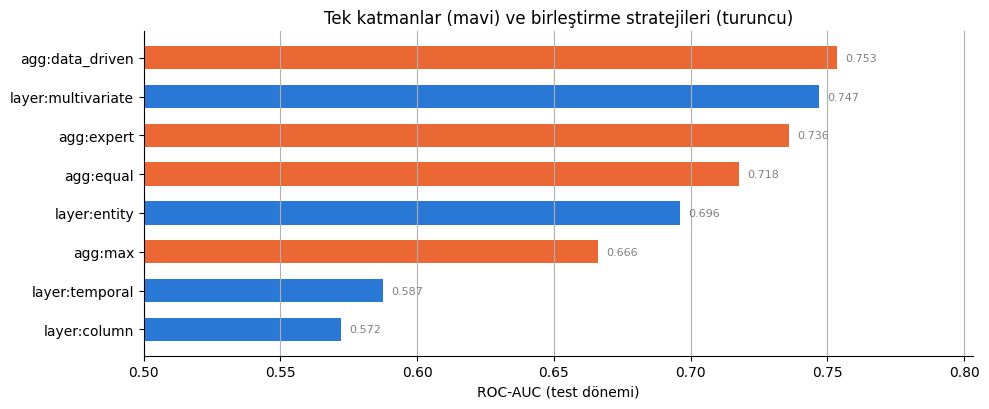

In [50]:
fig, ax = plt.subplots(figsize=(10, 4.2))
r = res.sort_values("roc_auc")
ax.barh(r.index, r.roc_auc, color=[ORANGE if i.startswith("agg") else BLUE for i in r.index], height=.6)
for yy, v in zip(r.index, r.roc_auc): ax.text(v + .003, yy, f"{v:.3f}", va="center", fontsize=8, color=INK2)
ax.set_xlim(.5, r.roc_auc.max() + .05); ax.set_xlabel("ROC-AUC (test dönemi)"); ax.grid(axis="y", visible=False)
ax.set_title("Tek katmanlar (mavi) ve birleştirme stratejileri (turuncu)")
plt.tight_layout(); plt.show()

**Bulgular: Ağırlık stratejileri (test dönemi, son 62 gün)**
- ROC-AUC sıralaması: **veri güdümlü 0,753**, en iyi tek katman (multivariate) 0,747, uzman 0,736, eşit 0,718, max 0,666.
- **Max** stratejisi en kötüsü, çünkü gürültülü katmanlar alarm üretiyor. Ağırlıklı ortalama bu gürültüyü bastırıyor.
- Ancak listenin en tepesinde (precision@1%) eşit ağırlık (%9,9) veri güdümlü ağırlığın (%7,3) önünde. En tepeyi, yüksek hızlı ve meşru bir C ürünü kümesi işgal ediyor.

## 5.3 Final raw anomali skoru

In [51]:
FINAL_STRATEGY = "data_driven"
w_final = dict(zip(L, W[FINAL_STRATEGY].round(4)))
print("Seçilen strateji:", FINAL_STRATEGY, "| ağırlıklar:", w_final)

contrib_mat = P * W[FINAL_STRATEGY]
scores = pd.DataFrame({KEY: df[KEY].values, "TransactionDateTime": df.TransactionDateTime.values,
                       "TransactionAmt": df.TransactionAmt.values, "uid": df.uid.values})
for k in L:
    scores[f"{k}_score_norm"] = NORM[k].round(4)
    scores[f"{k}_reason"] = REASONS[k]
scores["raw_anomaly_score"] = (100 * contrib_mat.sum(axis=1)).round(2)
scores["dominant_layer"] = np.array(L)[contrib_mat.argmax(axis=1)]
scores[TARGET] = y  # yalnızca değerlendirme için

display(scores.raw_anomaly_score.describe(percentiles=[.5, .9, .95, .99, .999]).round(2).to_frame().T)

Seçilen strateji: data_driven | ağırlıklar: {'column': 0.0589, 'multivariate': 0.5363, 'entity': 0.3183, 'temporal': 0.0864}


,count,mean,std,min,50%,90%,95%,99%,99.9%,max
raw_anomaly_score,590540.0,50.0,22.86,2.77,49.05,82.43,88.28,94.66,98.12,99.51


raw_anomaly_score,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10
n,59054.00,59054.00,59054.00,59054.00,59054.00,59054.00,59054.00,59054.00,59054.00,59054.00
fraud_rate,0.75,1.08,1.24,1.35,1.72,2.02,2.82,4.60,7.31,12.10
lift,0.21,0.31,0.35,0.39,0.49,0.58,0.81,1.32,2.09,3.46
fraud_capture_pct,2.13,3.09,3.53,3.85,4.91,5.77,8.07,13.15,20.90,34.59


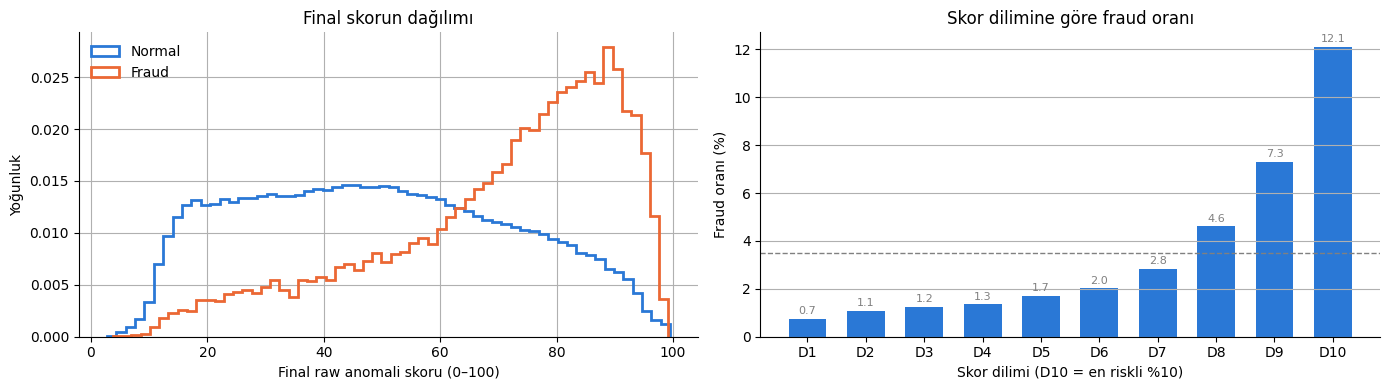

Baskın katman dağılımı (skor > p99 olan işlemlerde):


,oran
dominant_layer,
multivariate,1.0


In [52]:
dec = pd.qcut(scores.raw_anomaly_score.rank(method="first"), 10, labels=[f"D{i}" for i in range(1, 11)])
lift = scores.groupby(dec, observed=True)[TARGET].agg(n="count", fraud_rate="mean")
lift["lift"] = lift.fraud_rate / y.mean(); lift["fraud_capture_pct"] = scores.groupby(dec, observed=True)[TARGET].sum() / y.sum() * 100
lift["fraud_rate"] = lift.fraud_rate * 100
display(lift.round(2).T)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(scores.raw_anomaly_score[y == 0], bins=60, density=True, histtype="step", linewidth=2, color=BLUE, label="Normal")
axes[0].hist(scores.raw_anomaly_score[y == 1], bins=60, density=True, histtype="step", linewidth=2, color=ORANGE, label="Fraud")
axes[0].set_xlabel("Final raw anomali skoru (0–100)"); axes[0].set_ylabel("Yoğunluk"); axes[0].legend(frameon=False)
axes[0].set_title("Final skorun dağılımı")
axes[1].bar(lift.index.astype(str), lift.fraud_rate, color=BLUE, width=.65)
axes[1].axhline(y.mean() * 100, color=INK2, linestyle="--", linewidth=1)
for x_, v in zip(lift.index.astype(str), lift.fraud_rate): axes[1].text(x_, v + .2, f"{v:.1f}", ha="center", fontsize=8, color=INK2)
axes[1].set_xlabel("Skor dilimi (D10 = en riskli %10)"); axes[1].set_ylabel("Fraud oranı (%)"); axes[1].grid(axis="x", visible=False)
axes[1].set_title("Skor dilimine göre fraud oranı")
plt.tight_layout(); plt.show()

print("Baskın katman dağılımı (skor > p99 olan işlemlerde):")
display(scores.loc[scores.raw_anomaly_score > scores.raw_anomaly_score.quantile(.99), "dominant_layer"].value_counts(normalize=True).round(3).to_frame("oran"))

In [53]:
print("En yüksek final skora sahip 10 işlem: katman kırılımı ve gerekçeler")
cols = [KEY, "TransactionAmt", "raw_anomaly_score", "dominant_layer"] + [f"{k}_score_norm" for k in L] + [f"{k}_reason" for k in L] + [TARGET]
display(scores.nlargest(10, "raw_anomaly_score")[cols].reset_index(drop=True))

En yüksek final skora sahip 10 işlem: katman kırılımı ve gerekçeler


,TransactionID,TransactionAmt,raw_anomaly_score,dominant_layer,column_score_norm,multivariate_score_norm,entity_score_norm,temporal_score_norm,column_reason,multivariate_reason,entity_reason,temporal_reason,isFraud
0,3042944,39.936001,99.51,multivariate,1.0000,0.9980,0.9970,0.9661,C2=14.7,C5 + C1,rapid_succession=0.706,burst_1h_uid=10,0
1,3042981,46.639999,99.44,multivariate,1.0000,0.9983,0.9943,0.9673,C1=14.3,C5 + C2,velocity_24h=60,burst_1h_uid=13,0
2,3043032,60.866001,99.43,multivariate,1.0000,0.9977,0.9948,0.9676,C1=14.3,C5 + C1,velocity_24h=61,burst_1h_uid=14,0
3,3039886,27.167999,99.40,multivariate,0.9992,0.9981,0.9924,0.9714,C13=6.23,C5 + C1,rapid_succession=0.55,hour_rarity=1.82,0
4,3042946,76.531998,99.40,multivariate,1.0000,0.9973,0.9947,0.9666,C1=14.3,C5 + C1,velocity_24h=58,burst_1h_uid=11,0
5,3042967,76.531998,99.40,multivariate,1.0000,0.9973,0.9947,0.9670,C2=14.7,C5 + C1,velocity_24h=59,burst_1h_uid=12,0
6,3042943,76.531998,99.39,multivariate,1.0000,0.9974,0.9946,0.9651,C1=14.3,C5 + C1,velocity_24h=56,burst_1h_uid=9,0
7,3042937,76.531998,99.37,multivariate,1.0000,0.9973,0.9946,0.9637,C1=14.3,C5 + C1,velocity_24h=55,burst_1h_uid=8,0
8,3042910,44.949001,99.36,multivariate,1.0000,0.9982,0.9940,0.9591,C2=14.7,C5 + C1,velocity_24h=53,burst_1h_uid=6,0
9,3042914,84.184998,99.36,multivariate,1.0000,0.9973,0.9946,0.9621,C2=14.7,C5 + C1,velocity_24h=54,burst_1h_uid=7,0


## 5.4 Neden bu birleştirme yaklaşımı?

- **Rank normalizasyonu:** Katmanlar farklı ölçek ve dağılımlara sahip. Rank, ölçekten bağımsız ve aykırı değerlere dayanıklı. Ayrıca yorumlaması kolay: "0,99 = işlemlerin %99'undan daha anormal".
- **Ağırlıklı ortalama:** Tek bir gürültülü katmanın alarmı tek başına yeterli olmuyor (max stratejisi bu yüzden zayıf kaldı), ama güçlü sinyaller toplanıyor.
- **Veri güdümlü ağırlıklar:** wᵢ ∝ (AUCᵢ − 0,5)². Ağırlıklar yalnızca kalibrasyon döneminde belirlendi, dolayısıyla test dönemine sızıntı yok. Ölçüt objektif ve şeffaf; sonuç olarak multivariate 0,54, entity 0,32, temporal 0,09, column 0,06 aldı. Ağırlıklar bir konfigürasyon olarak tutuluyor ve analist geri bildirimiyle güncellenebilir.
- **Açıklanabilirlik:** Final skorla birlikte `dominant_layer` ve dört katmanın gerekçeleri saklanıyor.
- **Sınırlılık:** Final skoru en yüksek %1'lik dilimde multivariate katmanı baskın. En tepedeki 10 işlem ise yüksek hızlı ama meşru C ürünü işlemleri. Bu yanlış pozitifler, sonraki adımlardaki **rule engine ve context-aware değerlendirme** ile ele alınacak.

# ADIM 6: Context Adjust Engine

Adım 5'teki ham skor **istatistiksel** anomaliyi ölçüyor. Ancak her istatistiksel sapma iş açısından risk değildir. Örneğin yerleşik bir müşterinin büyük alışverişi veya mesai saatindeki yoğunluk sapma gibi görünebilir. Bu adımda skor, **iş ve zaman bağlamına** göre yeniden ağırlıklandırılıyor:

`adjusted_score = clip(raw_anomaly_score × Π çarpanᵢ, 0, 100)`, toplam çarpan **[0,5; 1,5]** aralığıyla sınırlı.

**Tasarım ilkeleri**
- **Konfigüre edilebilir:** Tüm kurallar `config/context_rules.yaml` dosyasında. Kod: `fraudai/context_engine.py`, koşul dili: `fraudai/conditions.py`. Yeni bir bağlam kuralı eklemek için kod değiştirmek gerekmiyor.
- **Türetilmiş bağlam alanları** (`is_business_hours`, `is_trusted_entity` vb.) da YAML'da koşul olarak tanımlı.
- **Sızıntısız kalibrasyon:** Çarpanlar yalnızca **kalibrasyon döneminde** (ilk 120 gün) alarm isabetine bakılarak belirlendi. Etkileri **test döneminde** (son 62 gün) ölçülüyor.
- **Sınırlı etki:** Toplam çarpan [0,5; 1,5] aralığında. Bağlam, AI skorunu düzeltir ama tamamen geçersiz kılamaz.

| Bölüm | İçerik |
|---|---|
| 6.1 | Yerel saat ve context alanlarının hazırlanması |
| 6.2 | Kural tasarımı: segment analizi (kalibrasyon dönemi) |
| 6.3 | Context kurallarının uygulanması |
| 6.4 | False positive azaltımının ölçülmesi ve ablasyon |

## 6.1 Yerel saat ve context alanları

`TransactionDT` bir referans noktasından itibaren geçen saniye; saat dilimi bilinmiyor. Bu yüzden Adım 3'teki `hour` gerçek yerel saat değil. **Business hours** bağlamını doğru kurmak için saat, işlem hacminden yeniden konumlandırılıyor: hacmin en düşük olduğu saat, yerel **04:00** kabul ediliyor (e-ticarette tipik çukur saat).

Ayrıca kural motorları için **geçmişe dayalı** cihaz ve e-posta sayıları (`uid_n_devices_past`, `uid_n_emails_past`) üretiliyor.

Hacmin en düşük olduğu saat (ham): 9:00 → yerel 04:00 kabul edildi | ofset = 5 saat
Context tablosu: (590540, 40)


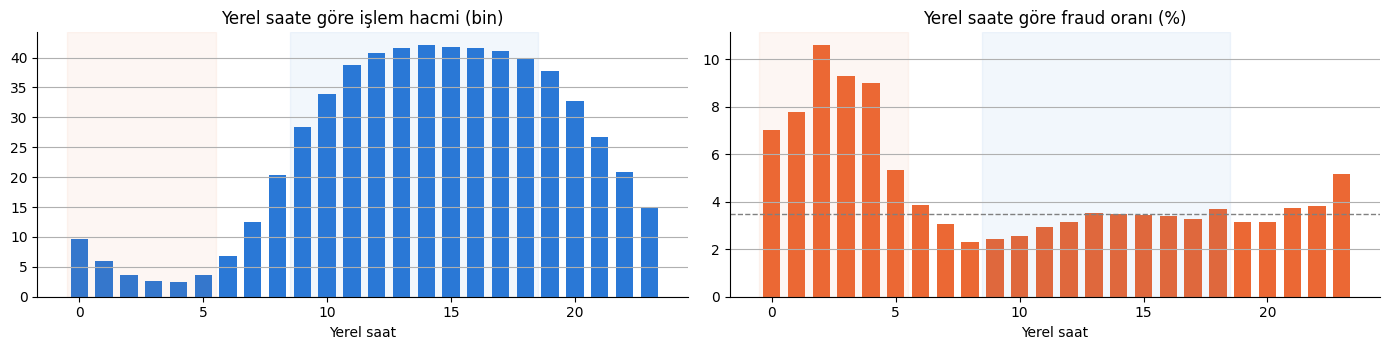

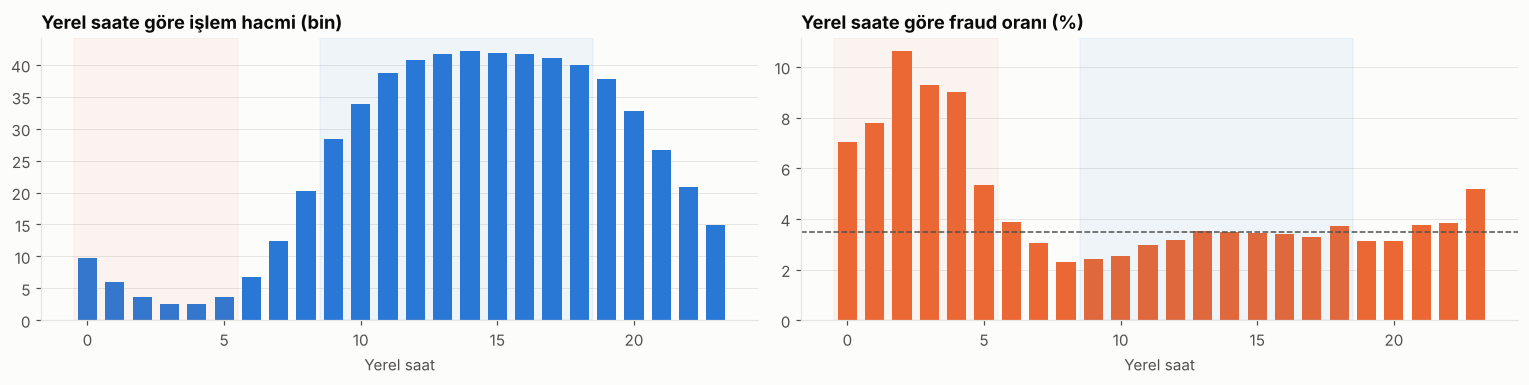

In [54]:
import copy
import yaml
from fraudai import conditions as COND
from fraudai.context_engine import ContextEngine
from fraudai.rule_engine import RuleEngine

vol = FE.hour.value_counts().sort_index()
TROUGH_HOUR = int(vol.idxmin())
LOCAL_OFFSET = (TROUGH_HOUR - 4) % 24
FE["local_hour"] = ((FE.hour.astype(int) - LOCAL_OFFSET) % 24).astype("int8")
print(f"Hacmin en düşük olduğu saat (ham): {TROUGH_HOUR}:00 → yerel 04:00 kabul edildi | ofset = {LOCAL_OFFSET} saat")

first_dev = (df.groupby(["uid", "device_fp"], dropna=False).cumcount() == 0) & df.device_fp.notna()
FE["uid_n_devices_past"] = first_dev.astype("int16").groupby(df.uid).cumsum().astype("int16")
first_em = (df.groupby(["uid", "P_emaildomain"], dropna=False, observed=True).cumcount() == 0) & df.P_emaildomain.notna()
FE["uid_n_emails_past"] = first_em.astype("int16").groupby(df.uid).cumsum().astype("int16")

RAW_CTX = [KEY, TIME, "TransactionAmt", "ProductCD", "card1", "card4", "card6", "addr1", "dist1",
           "P_emaildomain", "R_emaildomain", "DeviceType"]
FE_CTX = ["hour", "local_hour", "day_of_week", "is_weekend", "uid_tx_count_past", "uid_avg_amount_past",
          "uid_age_days", "amt_to_uid_avg_past", "uid_tx_last_1h", "uid_tx_last_24h", "card_age_days",
          "is_new_device_for_uid", "is_new_email_for_uid", "uid_n_devices_past", "uid_n_emails_past",
          "email_match", "device_n_uids", "has_identity"]
SC_COLS = [f"{k}_score_norm" for k in L] + [f"{k}_reason" for k in L] + ["raw_anomaly_score", "dominant_layer"]
ctx = pd.concat([df[RAW_CTX].reset_index(drop=True), FE[FE_CTX].reset_index(drop=True),
                 scores[SC_COLS].reset_index(drop=True)], axis=1)
for c in ["ProductCD", "card4", "card6", "P_emaildomain", "R_emaildomain", "DeviceType"]:
    ctx[c] = ctx[c].astype(object).where(ctx[c].notna(), None)
Y = df[TARGET].to_numpy()
print("Context tablosu:", ctx.shape)

lh = pd.DataFrame({"n": FE.groupby("local_hour").size(), "fraud": df.groupby(FE.local_hour.values)[TARGET].mean() * 100})
fig, axes = plt.subplots(1, 2, figsize=(14, 3.6))
axes[0].bar(lh.index, lh.n / 1000, color=BLUE, width=.7); axes[0].set_title("Yerel saate göre işlem hacmi (bin)")
axes[1].bar(lh.index, lh.fraud, color=ORANGE, width=.7); axes[1].set_title("Yerel saate göre fraud oranı (%)")
axes[1].axhline(Y.mean() * 100, color=INK2, linestyle="--", linewidth=1)
for ax in axes:
    ax.axvspan(8.5, 18.5, color=BLUE, alpha=.06); ax.axvspan(-.5, 5.5, color=ORANGE, alpha=.06)
    ax.set_xlabel("Yerel saat"); ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

## 6.2 Kural tasarımı: segment analizi (kalibrasyon dönemi)

Her context kuralı bir iş hipotezi: *"Bu segmentteki anomaliler daha az (veya daha çok) risklidir."* Hipotezler, kalibrasyon döneminde **alarm isabetiyle** test ediliyor.

- **Alarm:** ham skoru kalibrasyon döneminin en yüksek %2'lik diliminde olan işlem.
- **Alarm isabeti:** alarmlar içindeki gerçek fraud oranı.
- **Karar mantığı:** Segmentte isabet ortalamanın altındaysa (false positive yoğun) çarpan **< 1**, üstündeyse **> 1**.

Aşağıdaki tablo **doğrudan YAML'daki kural koşullarından** üretiliyor. Devre dışı kurallar da tabloda gösteriliyor.

In [55]:
CTX_CFG = yaml.safe_load(open("config/context_rules.yaml", encoding="utf-8"))
ce_all = ContextEngine({**CTX_CFG, "rules": [{**r, "enabled": True} for r in CTX_CFG["rules"]]})
ctx_d = ce_all.add_derived(ctx)
T_CAL = np.quantile(ctx.raw_anomaly_score[calib], .98)
alert_cal = calib & (ctx.raw_anomaly_score.to_numpy() >= T_CAL)
print(f"Kalibrasyon alarm eşiği (ham skor p98): {T_CAL:.2f} | alarm sayısı {alert_cal.sum():,} | "
      f"genel alarm isabeti %{Y[alert_cal].mean()*100:.1f}")
rows = []
for r in CTX_CFG["rules"]:
    m = COND.evaluate(r["condition"], ctx_d).to_numpy()
    a = alert_cal & m
    rows.append({"id": r["id"], "kategori": r["category"], "kural": r["name"], "çarpan": r["factor"],
                 "aktif": r.get("enabled", True), "işlem_payı_%": m[calib].mean() * 100,
                 "fraud_oranı_%": Y[calib & m].mean() * 100, "alarm_sayısı": a.sum(),
                 "alarm_isabeti_%": Y[a].mean() * 100 if a.any() else np.nan,
                 "diğer_alarmların_isabeti_%": Y[alert_cal & ~m].mean() * 100})
seg_tbl = pd.DataFrame(rows).set_index("id")
display(seg_tbl.round(2))
print("\nTüretilmiş bağlam alanlarının tanımları:")
for k, v in CTX_CFG["derived_fields"].items():
    print(f"  {k:24s} = {COND.describe(v)}")

Kalibrasyon alarm eşiği (ham skor p98): 92.66 | alarm sayısı 8,218 | genel alarm isabeti %16.7


,kategori,kural,çarpan,aktif,işlem_payı_%,fraud_oranı_%,alarm_sayısı,alarm_isabeti_%,diğer_alarmların_isabeti_%
id,,,,,,,,,
CTX-01,business_hours,Mesai saati işlemi,0.95,True,45.48,3.24,3317,13.60,18.77
CTX-02,business_hours,Mesai dışı / gece işlemi,1.15,True,4.96,7.77,1078,25.79,15.31
CTX-03,weekend,Hafta sonu perakende alışverişi,0.90,True,24.59,2.17,750,8.80,17.47
CTX-04,weekend,Hafta sonu yeni cihaz,1.10,False,2.06,7.68,504,22.62,16.30
CTX-05,trusted_entity,Güvenilir kullanıcı,0.75,True,9.69,2.52,431,10.67,17.02
CTX-06,trusted_entity,Sık işlem yapan yerleşik entity,0.85,True,5.22,3.57,436,12.84,16.90
CTX-07,high_value_customer,Yüksek değerli müşteri,0.80,True,3.27,5.78,583,3.60,17.68
CTX-08,product_profile,Düşük riskli ürün profili (R),0.85,True,7.32,3.48,1900,5.95,19.91
CTX-09,product_profile,Düşük riskli ürün profili (W),0.90,True,72.01,2.07,524,7.25,17.33



Türetilmiş bağlam alanlarının tanımları:
  is_business_hours        = 9 ≤ local_hour ≤ 18 VE is_weekend = 0
  is_off_hours             = 0 ≤ local_hour ≤ 5
  is_trusted_entity        = uid_tx_count_past ≥ 5 VE uid_age_days ≥ 30 VE is_new_device_for_uid = 0 VE is_new_email_for_uid = 0 VE 0.33 ≤ amt_to_uid_avg_past ≤ 3.0
  is_frequent_entity       = uid_tx_count_past ≥ 10 VE uid_age_days ≥ 30 VE is_new_device_for_uid = 0
  is_high_value_customer   = TransactionAmt > 500 VE uid_tx_count_past ≥ 1 VEYA uid_avg_amount_past ≥ 300 VE amt_to_uid_avg_past ≤ 2 VE uid_tx_count_past ≥ 3


**Bulgular: Context kurallarının tasarımı**
- **Yerel saat:** Hacmin en düşük olduğu ham saat 09:00; yerel 04:00 kabul edildi (ofset 5 saat). Bu ofsetle yerel gece (00–05) fraud oranı %7,8, yani ortalamanın 2 katından fazla.
- **False positive yoğun segmentler** (alarm isabeti ortalama %16,7'nin altında), çarpanı < 1:
  - mesai saati: %13,6
  - hafta sonu perakende: %8,8
  - güvenilir kullanıcı: %10,7
  - sık işlem yapan entity: %12,8
  - **yüksek değerli müşteri: %3,6**
  - R ürünü: %6,0
  - W ürünü: %7,3
- **Riskli segmentler**, çarpanı > 1 olmaya aday:
  - gece: %25,8
  - adresi olmayan: %22,4
  - C ürünü: %22,7
  - yeni cihaz: %20–23
- Segment isabeti tek başına yeterli değil. Bir kuralın gerçek etkisi ancak bütün sıralama değiştiğinde görülür; bu, 6.4'teki ablasyonla test ediliyor.

## 6.3 Context kurallarının uygulanması

Aktif kurallar tüm işlemlere uygulanıyor. Engine her işlem için şunları üretiyor:
- `context_factor`: toplam çarpan
- `adjusted_score`: düzeltilmiş skor
- `context_rules`: uygulanan kurallar (açıklanabilirlik için)

In [56]:
CE = ContextEngine.from_yaml("config/context_rules.yaml")
display(CE.documentation())
adj = CE.apply(ctx)
ctx = pd.concat([ctx.drop(columns=[c for c in adj.columns if c in ctx.columns]), adj], axis=1)

hits = pd.Series([r for s in ctx.context_rules for r in s.split(",") if r]).value_counts()
print("Kuralların tetiklenme oranı (%):"); display((hits / len(ctx) * 100).round(2).to_frame("oran_%").T)
print("Toplam çarpan dağılımı:"); display(ctx.context_factor.describe(percentiles=[.05, .25, .5, .75, .95]).round(3).to_frame().T)
print(f"Skoru düşürülen işlem: %{(ctx.context_factor < 1).mean()*100:.1f} | artırılan: %{(ctx.context_factor > 1).mean()*100:.1f} "
      f"| değişmeyen: %{(ctx.context_factor == 1).mean()*100:.1f}")

,id,kategori,ad,koşul,çarpan,gerekçe
0,CTX-01,business_hours,Mesai saati işlemi,is_business_hours = 1,0.95,"Hafta içi 09–18 işlemlerin %45'ini oluşturuyor; bu saatlerdeki alarmların isabeti %13,6 (diğer saatlerde %18,8). Etk..."
1,CTX-02,business_hours,Mesai dışı / gece işlemi,is_off_hours = 1,1.15,"Yerel gece (00–05) işlemlerin yalnızca %5'i ama fraud oranı %7,8 (ortalamanın ~2 katı); alarm isabeti %25,8. Gece ya..."
2,CTX-03,weekend,Hafta sonu perakende alışverişi,"is_weekend = 1 VE ProductCD ∈ ['W', 'R']",0.90,"Hafta sonu W/R (perakende) hacmi doğal olarak artıyor; bu segmentteki alarmların isabeti %8,8 (diğerleri %17,5). Sez..."
3,CTX-05,trusted_entity,Güvenilir kullanıcı,is_trusted_entity = 1,0.75,"En az 5 geçmiş işlemi, 30+ günlük geçmişi olan, cihaz/e-posta değiştirmeyen ve tutarı kendi ortalamasının 1/3–3 katı..."
4,CTX-06,trusted_entity,Sık işlem yapan yerleşik entity,is_frequent_entity = 1,0.85,10+ geçmiş işlem ve 30+ gün geçmiş: yüksek işlem sıklığı bu kullanıcı için normal davranış. Velocity tabanlı istatis...
5,CTX-07,high_value_customer,Yüksek değerli müşteri,is_high_value_customer = 1,0.80,"Büyük tutarlar çoğunlukla tanınan müşterilerden geliyor: bu segmentteki alarmların isabeti yalnızca %3,6 (diğerleri ..."
6,CTX-08,product_profile,Düşük riskli ürün profili (R),ProductCD = R,0.85,"R ürününde alarm isabeti %6,0 (diğer ürünlerde %19,9)."
7,CTX-09,product_profile,Düşük riskli ürün profili (W),ProductCD = W,0.90,"W ürününde fraud oranı %2,1 ve alarm isabeti %7,3."
8,CTX-11,geo_risk,Fatura adresi yok (coğrafya doğrulanamıyor),addr1 boş,1.05,"addr1 eksik işlemlerde fraud oranı %11,2 ve alarm isabeti %22,4 (diğerleri %9,8). Coğrafi doğrulama yapılamayan işle..."


Kuralların tetiklenme oranı (%):


,CTX-09,CTX-01,CTX-03,CTX-05,CTX-11,CTX-06,CTX-08,CTX-02,CTX-07
oran_%,74.45,45.69,24.52,14.21,11.13,8.49,6.38,4.76,3.5


Toplam çarpan dağılımı:


,count,mean,std,min,5%,25%,50%,75%,95%,max
context_factor,590540.0,0.84,0.134,0.5,0.545,0.81,0.855,0.9,1.05,1.208


Skoru düşürülen işlem: %87.8 | artırılan: %8.5 | değişmeyen: %3.6


## 6.4 False positive azaltımı (test dönemi)

İki bakış açısıyla ölçülüyor:
1. **Eşit alarm bütçesi:** Analist ekibi her gün sabit sayıda işlem inceleyebilir; en riskli %2'lik dilim inceleniyor. Aynı bütçeyle **kaç false positive** inceleniyor ve kaç fraud yakalanıyor?
2. **Sabit eşik:** Kalibrasyonda belirlenen ham skor eşiği (p98) değiştirilmeden kullanılıyor.

alarm   TP    FP  precision_pct  recall_pct  roc_auc
senaryo           skor                                                                           
Eşit bütçe (%2)   Context-adjusted (Adım 6)   3598  880  2718          24.46       14.09     0.76
                  Ham skor (Adım 5)           3598  479  3119          13.31        7.67     0.75
Sabit eşik (92.7) Context-adjusted (Adım 6)   3197  810  2387          25.34       12.97     0.76
                  Ham skor (Adım 5)           3604  480  3124          13.32        7.69     0.75

Eşit bütçede FP: 3,119 → 2,718 (-12.9%), yakalanan fraud: 479 → 880


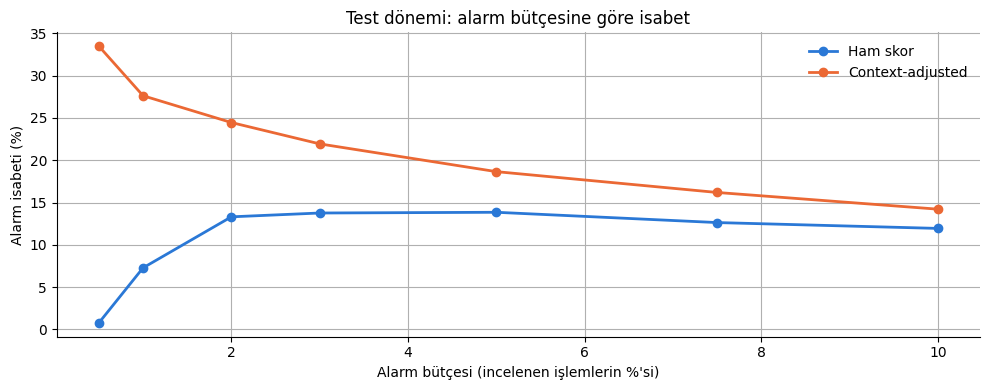

In [57]:
def alert_metrics(score, mask, budget=None, thr=None):
    s, yy = np.asarray(score)[mask], Y[mask]
    if budget is not None:
        k = int(len(s) * budget); sel = np.argsort(-s)[:k]
    else:
        sel = np.where(s >= thr)[0]
    tp = int(yy[sel].sum()); fp = len(sel) - tp
    return dict(alarm=len(sel), TP=tp, FP=fp, precision_pct=100 * tp / max(len(sel), 1),
                recall_pct=100 * tp / yy.sum(), roc_auc=roc_auc_score(yy, s))

rows = []
for name, col in [("Ham skor (Adım 5)", "raw_anomaly_score"), ("Context-adjusted (Adım 6)", "adjusted_score")]:
    rows.append({"skor": name, "senaryo": "Eşit bütçe (%2)", **alert_metrics(ctx[col], test, budget=.02)})
    rows.append({"skor": name, "senaryo": f"Sabit eşik ({T_CAL:.1f})", **alert_metrics(ctx[col], test, thr=T_CAL)})
fp_tbl = pd.DataFrame(rows).set_index(["senaryo", "skor"]).sort_index()
display(fp_tbl.round(2))
b = fp_tbl.loc["Eşit bütçe (%2)"]
print(f"Eşit bütçede FP: {b.loc['Ham skor (Adım 5)','FP']:,} → {b.loc['Context-adjusted (Adım 6)','FP']:,} "
      f"({(b.loc['Context-adjusted (Adım 6)','FP'] / b.loc['Ham skor (Adım 5)','FP'] - 1)*100:+.1f}%), "
      f"yakalanan fraud: {b.loc['Ham skor (Adım 5)','TP']} → {b.loc['Context-adjusted (Adım 6)','TP']}")

budgets = np.array([.005, .01, .02, .03, .05, .075, .10])
fig, ax = plt.subplots(figsize=(10, 4))
for col, c_, nm in [("raw_anomaly_score", BLUE, "Ham skor"), ("adjusted_score", ORANGE, "Context-adjusted")]:
    ax.plot(budgets * 100, [alert_metrics(ctx[col], test, budget=b_)["precision_pct"] for b_ in budgets],
            marker="o", color=c_, linewidth=2, label=nm)
ax.set_xlabel("Alarm bütçesi (incelenen işlemlerin %'si)"); ax.set_ylabel("Alarm isabeti (%)")
ax.set_title("Test dönemi: alarm bütçesine göre isabet"); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

In [58]:
def top_precision(cfg, mask, budget=.02):
    s = ContextEngine(cfg).apply(ctx).adjusted_score.to_numpy()[mask]
    k = int(len(s) * budget); return Y[mask][np.argsort(-s)[:k]].mean() * 100

base_cal, base_test = top_precision(CTX_CFG, calib), top_precision(CTX_CFG, test)
abl = [{"değişiklik": "Mevcut konfigürasyon", "kalibrasyon_isabet_%": base_cal, "test_isabet_%": base_test}]
for r in CTX_CFG["rules"]:
    cfg2 = copy.deepcopy(CTX_CFG)
    for r2 in cfg2["rules"]:
        if r2["id"] == r["id"]:
            r2["enabled"] = not r.get("enabled", True)
    abl.append({"değişiklik": f"{'Kapat' if r.get('enabled', True) else 'Aç'}: {r['id']} {r['name']}",
                "kalibrasyon_isabet_%": top_precision(cfg2, calib), "test_isabet_%": top_precision(cfg2, test)})
abl_tbl = pd.DataFrame(abl)
abl_tbl["Δ_kalibrasyon"] = abl_tbl["kalibrasyon_isabet_%"] - base_cal
abl_tbl["Δ_test"] = abl_tbl["test_isabet_%"] - base_test
print("Ablasyon: her kuralın durumu tersine çevrildiğinde %2 bütçedeki alarm isabeti")
print("(negatif Δ = kural faydalı; aktif bir kuralı kapatmak isabeti düşürüyor)")
display(abl_tbl.round(2))

Ablasyon: her kuralın durumu tersine çevrildiğinde %2 bütçedeki alarm isabeti
(negatif Δ = kural faydalı; aktif bir kuralı kapatmak isabeti düşürüyor)


,değişiklik,kalibrasyon_isabet_%,test_isabet_%,Δ_kalibrasyon,Δ_test
0,Mevcut konfigürasyon,21.08,24.46,0.00,0.00
1,Kapat: CTX-01 Mesai saati işlemi,20.79,24.85,-0.29,0.39
2,Kapat: CTX-02 Mesai dışı / gece işlemi,21.03,23.79,-0.05,-0.67
3,Kapat: CTX-03 Hafta sonu perakende alışverişi,21.07,24.43,-0.01,-0.03
4,Aç: CTX-04 Hafta sonu yeni cihaz,20.25,23.57,-0.83,-0.89
5,Kapat: CTX-05 Güvenilir kullanıcı,20.96,23.93,-0.12,-0.53
6,Kapat: CTX-06 Sık işlem yapan yerleşik entity,21.14,24.04,0.06,-0.42
7,Kapat: CTX-07 Yüksek değerli müşteri,21.07,24.29,-0.01,-0.17
8,Kapat: CTX-08 Düşük riskli ürün profili (R),20.57,24.40,-0.51,-0.06
9,Kapat: CTX-09 Düşük riskli ürün profili (W),20.84,24.01,-0.24,-0.44


In [59]:
te_ctx = ctx[test]
top_raw = set(te_ctx.raw_anomaly_score.nlargest(int(len(te_ctx) * .02)).index)
top_adj = set(te_ctx.adjusted_score.nlargest(int(len(te_ctx) * .02)).index)
dropped = te_ctx.loc[list(top_raw - top_adj)]
added = te_ctx.loc[list(top_adj - top_raw)]
print(f"Context sonrası alarm listesinden çıkan: {len(dropped):,} işlem (fraud oranı %{Y[dropped.index].mean()*100:.1f}) | "
      f"listeye giren: {len(added):,} işlem (fraud oranı %{Y[added.index].mean()*100:.1f})")
print("\nListeden çıkanlarda en sık uygulanan context kuralları:")
display(pd.Series([r for s in dropped.context_rules for r in s.split(",") if r]).value_counts().head(6).to_frame("adet").T)
print("Örnek: alarm listesinden çıkarılan 5 işlem")
display(dropped.sort_values("raw_anomaly_score", ascending=False)[
    [KEY, "TransactionAmt", "ProductCD", "local_hour", "uid_tx_count_past", "raw_anomaly_score",
     "context_factor", "adjusted_score", "context_rules"]].head(5).assign(isFraud=lambda d: Y[d.index]))

Context sonrası alarm listesinden çıkan: 2,259 işlem (fraud oranı %3.9) | listeye giren: 2,259 işlem (fraud oranı %21.8)

Listeden çıkanlarda en sık uygulanan context kuralları:


,CTX-06,CTX-05,CTX-01,CTX-08,CTX-09,CTX-03
adet,1611,1580,1330,373,195,193


Örnek: alarm listesinden çıkarılan 5 işlem


,TransactionID,TransactionAmt,ProductCD,local_hour,uid_tx_count_past,raw_anomaly_score,context_factor,adjusted_score,context_rules,isFraud
541940,3528940,106.0,S,8,405,99.16,0.6375,63.21,"CTX-05,CTX-06",0
541939,3528939,106.0,S,8,404,99.13,0.6375,63.20,"CTX-05,CTX-06",0
541938,3528938,106.0,S,8,403,99.12,0.6375,63.19,"CTX-05,CTX-06",0
541936,3528936,106.0,S,8,402,99.10,0.6375,63.18,"CTX-05,CTX-06",0
421590,3408590,150.0,R,10,2,99.03,0.8075,79.97,"CTX-01,CTX-08",0


**Bulgular: False positive azaltımı (test dönemi, son 62 gün)**

| Senaryo | Ham skor | Context-adjusted | Değişim |
|---|---|---|---|
| **Eşit bütçe (%2): FP** | 3.119 | **2.718** | **−%12,9** |
| Eşit bütçe (%2): yakalanan fraud | 479 | **880** | +%84 |
| Eşit bütçe (%2): isabet | %13,3 | **%24,5** | |
| Sabit eşik: FP | 3.124 | **2.387** | **−%23,6** |
| ROC-AUC | 0,753 | 0,76 | |

- **Mekanizma:** Alarm listesinden çıkarılan 2.259 işlemin fraud oranı yalnızca %3,9; yerlerine girenlerinki %21,8. Çıkarılanların çoğunda sık işlem yapan entity (CTX-06), güvenilir kullanıcı (CTX-05) ve mesai saati (CTX-01) kuralları uygulanmış. Tipik örnek: 400'den fazla geçmiş işlemi olan, hep aynı tutarı ödeyen bir kullanıcının işlemleri. İstatistiksel olarak sıra dışı görünüyorlar ama iş açısından normal.
- **Ablasyon:** Kalibrasyon döneminde ham skor en tepeye riskli segmentleri zaten yerleştiriyor. Bu yüzden **skor artıran** kurallar (CTX-04, CTX-10, CTX-12) segment isabetleri yüksek olsa da düşük skorlu işlemleri listeye taşıyıp isabeti düşürdü; bu kurallar devre dışı bırakıldı. Mesai saati çarpanı da 0,85'ten 0,95'e yumuşatıldı. Tüm bu kararlar **yalnızca kalibrasyon dönemine** bakılarak verildi. Testte sonuçlar çoğunlukla aynı yönde; tek istisna CTX-01, kapatıldığında test isabeti 0,4 puan artıyor.
- Etiket yalnızca kalibrasyon ve ölçüm için kullanıldı. Context kuralları çalışırken etiket kullanmıyor.

# ADIM 7: Rule Engine

İş kuralları ile AI skorunun birlikte çalıştığı, **konfigüre edilebilir** bir kural motoru.

| Özellik | Uygulama |
|---|---|
| **JSON/YAML konfigürasyon** | `config/rules.yaml` (JSON da destekleniyor). Kurallar çalışma anında `add_rule` / `remove_rule` ile eklenip çıkarılabiliyor ve yüklenirken doğrulanıyor |
| **If-then** | `if`: iç içe `all` / `any` / `not` destekleyen koşul ağacı; `then`: aksiyon, skor etkisi ve gerekçe şablonu |
| **Aksiyonlar** | BLOCK (4) > REVIEW (3) > FLAG (2, karar vermez, skoru ayarlar) > ALLOW (1, beyaz liste) |
| **Öncelik** | Küçük numara önce değerlendirilir. Kurallar öncelik sırasına göre çalışır |
| **Çatışma çözümü** | `priority` (varsayılan): en öncelikli karar kuralı kazanır. `severity`: en ciddi aksiyon kazanır. Geçersiz kılınan kurallar raporlanır |
| **AI ile birleşim** | Girdi `adjusted_score` (Adım 6). `final_risk_score = adjusted + Σ skor etkisi` (±30 ile sınırlı). Hiçbir karar kuralı tetiklenmezse karar AI'a kalır: `final ≥ 95 → REVIEW` |
| **Explainability** | Her tetiklenen kural için: doldurulmuş gerekçe mesajı, okunabilir koşul, kanıt alanları ve değerleri, geçersiz kılınan kurallar, AI katman gerekçeleri |

Kod: `fraudai/rule_engine.py`.

## 7.1 Kural seti (13 kural)

In [60]:
RE = RuleEngine.from_file("config/rules.yaml")
print("Ayarlar:", RE.settings)
display(RE.documentation())
print("\nÖrnek kural tanımı (YAML):")
print(yaml.safe_dump([r for r in yaml.safe_load(open("config/rules.yaml", encoding="utf-8"))["rules"] if r["id"] == "R001"],
                     allow_unicode=True, sort_keys=False))

Ayarlar: {'conflict_resolution': 'priority', 'score_field': 'adjusted_score', 'max_total_delta': 30, 'review_threshold': 95}


,öncelik,id,ad,IF,THEN,skor_Δ,etiketler
0,1,R001,Gece + yüksek tutar + doğrulanamayan cihaz/adres,TransactionAmt > 200 VE is_off_hours = 1 VE (is_new_device_for_uid = 1 VEYA addr1 boş),BLOCK,25,"account_takeover, high_amount, night"
1,5,R013,Güvenilir müşteri beyaz listesi,is_trusted_entity = 1 VE adjusted_score < 80 VE uid_tx_last_1h < 5,ALLOW,-10,"whitelist, trusted"
2,10,R007,Gece yeni cihaz (hesap ele geçirme),is_new_device_for_uid = 1 VE is_off_hours = 1,REVIEW,15,account_takeover
3,12,R006,Yeni kullanıcıdan çok yüksek tutar,TransactionAmt > 2000 VE uid_tx_count_past = 0,FLAG,5,"high_amount, new_entity"
4,15,R003,Card testing (küçük tutarlı ardışık denemeler),TransactionAmt < 10 VE uid_tx_last_1h ≥ 3,REVIEW,15,"card_testing, velocity"
5,20,R002,Yeni hesapta velocity burst,uid_tx_last_1h ≥ 5 VE uid_age_days < 1,REVIEW,10,velocity
6,30,R004,Kullanıcıya göre tutar sıçraması,amt_to_uid_avg_past ≥ 5 VE uid_tx_count_past ≥ 3,FLAG,5,"amount, behavior"
7,35,R005,Yeni kartla yüksek tutar (online kimlikli),card_age_days ≤ 1 VE TransactionAmt ≥ 500 VE has_identity = 1,REVIEW,10,"new_card, high_amount"
8,50,R012,AI yüksek risk,adjusted_score ≥ 95,REVIEW,0,ai
9,60,R008,Çoklu cihaz kullanımı,uid_n_devices_past ≥ 5,FLAG,3,device



Örnek kural tanımı (YAML):
- id: R001
  name: Gece + yüksek tutar + doğrulanamayan cihaz/adres
  priority: 1
  tags:
  - account_takeover
  - high_amount
  - night
  if:
    all:
    - field: TransactionAmt
      op: gt
      value: 200
    - field: is_off_hours
      op: eq
      value: 1
    - any:
      - field: is_new_device_for_uid
        op: eq
        value: 1
      - field: addr1
        op: is_null
  then:
    action: BLOCK
    score_delta: 25
    reason: Gece {local_hour}:00'da {TransactionAmt:.0f} USD; yeni cihaz={is_new_device_for_uid},
      adres={addr1}



## 7.2 Toplu değerlendirme ve kural performansı

Kural motoru tüm işlemlere vektörize olarak uygulanıyor (590 bin işlem yaklaşık 1–2 saniye). Kural başına tetiklenme oranı ve isabet (fraud oranı) **test döneminde** raporlanıyor.

In [61]:
import time
t0 = time.time()
rules_out = RE.evaluate_frame(ctx)
print(f"Değerlendirme süresi: {time.time()-t0:.1f} sn")
ctx = pd.concat([ctx.drop(columns=[c for c in rules_out.columns if c in ctx.columns]), rules_out], axis=1)

te = ctx[test]; y_te = Y[test]
rule_perf = []
for r in RE.rules:
    m = te.fired_rules.str.split(",").apply(lambda l, rid=r["id"]: rid in l).to_numpy()
    d = (te.decided_by == r["id"]).to_numpy()
    rule_perf.append({"öncelik": r["priority"], "id": r["id"], "ad": r["name"], "aksiyon": r["then"]["action"],
                      "tetiklenme_%": m.mean() * 100, "isabet_%": y_te[m].mean() * 100 if m.any() else np.nan,
                      "karar_verdiği_işlem": d.sum()})
display(pd.DataFrame(rule_perf).set_index("id").round(2))

dec = te.groupby("decision").apply(lambda d: pd.Series({"işlem": len(d), "pay_%": len(d) / len(te) * 100,
                                                       "fraud_oranı_%": Y[d.index].mean() * 100}))
print("Karar dağılımı (test dönemi):"); display(dec.round(2))
print("Kararı kim verdi?"); display(te.decided_by.value_counts().to_frame("işlem").T)

Değerlendirme süresi: 0.9 sn


,öncelik,ad,aksiyon,tetiklenme_%,isabet_%,karar_verdiği_işlem
id,,,,,,
R001,1,Gece + yüksek tutar + doğrulanamayan cihaz/adres,BLOCK,0.00,42.86,7
R013,5,Güvenilir müşteri beyaz listesi,ALLOW,23.80,1.95,42825
R007,10,Gece yeni cihaz (hesap ele geçirme),REVIEW,0.26,22.25,458
R006,12,Yeni kullanıcıdan çok yüksek tutar,FLAG,0.19,1.43,0
R003,15,Card testing (küçük tutarlı ardışık denemeler),REVIEW,0.12,11.93,216
R002,20,Yeni hesapta velocity burst,REVIEW,0.27,6.68,436
R004,30,Kullanıcıya göre tutar sıçraması,FLAG,0.36,5.08,0
R005,35,Yeni kartla yüksek tutar (online kimlikli),REVIEW,0.12,24.30,206
R012,50,AI yüksek risk,REVIEW,1.21,26.85,1662


Karar dağılımı (test dönemi):


,işlem,pay_%,fraud_oranı_%
decision,,,
APPROVE,174708.0,97.09,2.96
BLOCK,7.0,0.00,42.86
REVIEW,5224.0,2.90,20.62


Kararı kim verdi?


decided_by,AI_SCORE,R013,R012,R007,R002,R003,R005,R001
işlem,134129,42825,1662,458,436,216,206,7


In [62]:
alerts = te.decision.isin(["REVIEW", "BLOCK"]).to_numpy()
k = alerts.sum()
cmp_rows = [{"yaklaşım": "Rule engine + AI (REVIEW/BLOCK)", "alarm": k, "TP": int(y_te[alerts].sum()),
             "FP": int((y_te[alerts] == 0).sum()), "isabet_%": y_te[alerts].mean() * 100}]
for nm, col in [("Yalnız ham AI skoru (aynı alarm sayısı)", "raw_anomaly_score"),
                ("Yalnız context-adjusted skor (aynı alarm sayısı)", "adjusted_score")]:
    sel = np.argsort(-te[col].to_numpy())[:k]
    cmp_rows.append({"yaklaşım": nm, "alarm": k, "TP": int(y_te[sel].sum()), "FP": int((y_te[sel] == 0).sum()),
                     "isabet_%": y_te[sel].mean() * 100})
display(pd.DataFrame(cmp_rows).set_index("yaklaşım").round(2))

,alarm,TP,FP,isabet_%
yaklaşım,,,,
Rule engine + AI (REVIEW/BLOCK),5231,1080,4151,20.65
Yalnız ham AI skoru (aynı alarm sayısı),5231,718,4513,13.73
Yalnız context-adjusted skor (aynı alarm sayısı),5231,1162,4069,22.21


## 7.3 Rule priority ve conflict resolution

Bir işlemde birden fazla karar kuralı tetiklendiğinde çatışma, seçilen stratejiye göre çözülüyor. Aşağıda aynı işlem iki stratejiyle değerlendiriliyor:
- `priority`: öncelik numarası en küçük olan karar kuralı kazanır.
- `severity`: en ciddi aksiyon kazanır.

In [63]:
def to_py(row):
    """pandas satırını JSON uyumlu dict'e çevirir: NaN → None, NumPy tipleri → Python tipleri."""
    out = {}
    for k, v in row.items():
        if v is None or (not isinstance(v, (str, list, dict, set)) and pd.isna(v)):
            out[k] = None
        else:
            out[k] = v.item() if hasattr(v, "item") else v
    return out

def record_of(i):
    return to_py(ctx.loc[i])

conf_idx = te.index[(te.decided_by == "R013") & te.fired_rules.str.contains("R00[2-7]|R012")]
if len(conf_idx) == 0:  # yedek: birden fazla kuralın tetiklendiği herhangi bir işlem
    conf_idx = te.index[te.n_fired >= 2]
print(f"Test döneminde beyaz listenin (R013) bir REVIEW kuralını geçersiz kıldığı işlem sayısı: {len(conf_idx)}")
i = conf_idx[0]
rec = record_of(i)
for strategy in ["priority", "severity"]:
    eng = RuleEngine({"settings": {**RE.settings, "conflict_resolution": strategy}, "rules": RE.rules})
    out = eng.evaluate(rec)
    print(f"\n=== Strateji: {strategy} → karar {out['decision']} (karar veren {out['decided_by']}), "
          f"nihai risk {out['final_risk_score']}")
    for f_ in out["fired_rules"]:
        print(f"  [{f_['priority']:>3}] {f_['id']} {f_['action']:6s} {f_['score_delta']:+d} | {f_['message']}")
    for c in out["conflicts"]:
        print("  ÇATIŞMA:", c["explanation"])
print(f"\nGerçek etiket (yalnız değerlendirme için): isFraud = {Y[i]}")

Test döneminde beyaz listenin (R013) bir REVIEW kuralını geçersiz kıldığı işlem sayısı: 2

=== Strateji: priority → karar APPROVE (karar veren R013), nihai risk 76.91
  [  5] R013 ALLOW  -10 | Güvenilir müşteri (21 geçmiş işlem, 92 gün), skor 62.9 < 80
  [ 15] R003 REVIEW +15 | 7.68 USD'lik küçük işlem; son 1 saatte 3 işlem
  [ 60] R008 FLAG   +3 | Kullanıcı şimdiye kadar 10 farklı cihaz kullandı
  [ 61] R009 FLAG   +3 | Kullanıcı şimdiye kadar 4 farklı e-posta alan adı kullandı
  [ 63] R011 FLAG   +3 | Fatura adresi ve mesafe bilgisi yok; coğrafi doğrulama yapılamıyor
  ÇATIŞMA: R003 (REVIEW, öncelik 15) → R013 (ALLOW, öncelik 5) tarafından geçersiz kılındı [strateji: priority]

=== Strateji: severity → karar REVIEW (karar veren R003), nihai risk 76.91
  [  5] R013 ALLOW  -10 | Güvenilir müşteri (21 geçmiş işlem, 92 gün), skor 62.9 < 80
  [ 15] R003 REVIEW +15 | 7.68 USD'lik küçük işlem; son 1 saatte 3 işlem
  [ 60] R008 FLAG   +3 | Kullanıcı şimdiye kadar 10 farklı cihaz kullandı
  [

## 7.4 Dinamik kural ekleme (JSON) ve doğrulama

Kurallar çalışma anında **JSON** olarak eklenebiliyor. Hatalı kurallar sisteme alınmadan önce reddediliyor.

In [64]:
new_rule_json = """
{
  "id": "R100",
  "name": "Mobil + kredi kartı + C ürünü + yeni kullanıcı",
  "priority": 45,
  "tags": ["product", "device"],
  "if": {"all": [
      {"field": "ProductCD", "op": "eq", "value": "C"},
      {"field": "DeviceType", "op": "eq", "value": "mobile"},
      {"field": "card6", "op": "eq", "value": "credit"},
      {"field": "uid_tx_count_past", "op": "lte", "value": 1}
  ]},
  "then": {"action": "REVIEW", "score_delta": 10,
           "reason": "C ürünü, mobil cihaz, kredi kartı ve {uid_tx_count_past} geçmiş işlem"}
}
"""
RE_dyn = RuleEngine({"settings": RE.settings, "rules": copy.deepcopy(RE.rules)})
RE_dyn.add_rule(json.loads(new_rule_json))
m = COND.evaluate(RE_dyn.rules[[r["id"] for r in RE_dyn.rules].index("R100")]["if"], te).to_numpy()
print(f"R100 eklendi → toplam {len(RE_dyn.rules)} kural | test döneminde tetiklenme %{m.mean()*100:.2f}, isabet %{y_te[m].mean()*100:.1f}")

for bad in [{"id": "R999", "name": "hatalı operatör", "if": {"field": "TransactionAmt", "op": "bigger", "value": 5},
             "then": {"action": "REVIEW"}},
            {"id": "R998", "name": "hatalı aksiyon", "if": {"field": "TransactionAmt", "op": "gt", "value": 5},
             "then": {"action": "DELETE_USER"}}]:
    try:
        RE_dyn.add_rule(bad)
    except Exception as e:
        print(f"Reddedildi ({bad['id']}): {e}")

R100 eklendi → toplam 14 kural | test döneminde tetiklenme %1.11, isabet %18.3
Reddedildi (R999): R999.if: bilinmeyen operatör 'bigger' (geçerli: ['between', 'contains', 'eq', 'gt', 'gte', 'in', 'is_null', 'lt', 'lte', 'ne', 'not_in', 'not_null'])
Reddedildi (R998): R998: geçersiz aksiyon 'DELETE_USER' (geçerli: ['BLOCK', 'REVIEW', 'FLAG', 'ALLOW'])


## 7.5 Explainability çıktısı

Bir işlem için kural motorunun tam çıktısı aşağıda. Bu çıktı API'de `/explain` ve `/rules/evaluate` endpoint'lerinden de dönüyor.

In [65]:
blk = te.index[te.decision == "BLOCK"]
i = blk[0] if len(blk) else te.index[te.decision == "REVIEW"][0]
ex = RE.evaluate(record_of(i), ai_reasons={k: ctx.loc[i, f"{k}_reason"] for k in L})
ex_show = {k: v for k, v in ex.items() if k != "not_fired"}
print(json.dumps(ex_show, ensure_ascii=False, indent=2, default=str))
print(f"\nGerçek etiket (yalnız değerlendirme için): isFraud = {Y[i]}")

{
  "decision": "BLOCK",
  "decided_by": "R001",
  "rationale": "R001 (Gece + yüksek tutar + doğrulanamayan cihaz/adres) kuralı karar verdi: Gece 2:00'da 350 USD; yeni cihaz=1, adres=299.0",
  "base_score": 62.97,
  "rule_score_delta": 30.0,
  "final_risk_score": 92.97,
  "fired_rules": [
    {
      "id": "R001",
      "name": "Gece + yüksek tutar + doğrulanamayan cihaz/adres",
      "priority": 1,
      "action": "BLOCK",
      "score_delta": 25,
      "message": "Gece 2:00'da 350 USD; yeni cihaz=1, adres=299.0",
      "condition": "TransactionAmt > 200 VE is_off_hours = 1 VE (is_new_device_for_uid = 1 VEYA addr1 boş)",
      "evidence": {
        "TransactionAmt": 350.0,
        "addr1": 299.0,
        "is_new_device_for_uid": 1,
        "is_off_hours": 1
      },
      "tags": [
        "account_takeover",
        "high_amount",
        "night"
      ]
    },
    {
      "id": "R007",
      "name": "Gece yeni cihaz (hesap ele geçirme)",
      "priority": 10,
      "action": "REVIEW

**Bulgular: Rule engine**
- **Kural seti:** 13 kural (1 BLOCK, 5 REVIEW, 6 FLAG, 1 ALLOW). Test döneminde işlemlerin %2,9'u REVIEW veya BLOCK kararı aldı ve bunların fraud oranı **%20,6**. Aynı sayıda alarmı yalnız ham AI skoruyla seçmek %13,7 isabet veriyor; yani false positive sayısı 4.513'ten 4.151'e iniyor.
- **En isabetli kurallar:** R001 BLOCK (%42,9; yalnızca 7 işlem), R012 AI yüksek risk (%26,9), R005 yeni kart + yüksek tutar (%24,3), R007 gece yeni cihaz (%22,3). R002 velocity (%6,7) ve R006 (%1,4) zayıf. Bu yüzden R006 karar vermiyor, yalnızca skoru ayarlıyor (FLAG).
- **Beyaz liste:** R013 işlemlerin %23,8'ini otomatik onaylıyor. Bu işlemlerde fraud oranı %1,95, ortalamanın (%3,5) altında.
- **Kurallar AI sıralamasından daha isabetli değil.** Yalnız context-adjusted skor aynı alarm sayısında %22,2 isabet veriyor. Kuralların katkısı isabette değil; **deterministik ve denetlenebilir kararlar**, sabit politika uygulaması ve okunabilir gerekçe sağlıyorlar. Örneğin yapay zekâ tek başına BLOCK kararı veremiyor (KB-802).
- **Çatışma çözümü:** Aynı işlemde R013 (ALLOW, öncelik 5) ile R003 (REVIEW, öncelik 15) çatışıyor. `priority` stratejisinde karar APPROVE, `severity` stratejisinde REVIEW. Hangisinin seçileceği bir politika kararı ve konfigürasyondan değiştirilebiliyor.
- **Doğrulama:** Bilinmeyen operatör veya aksiyon içeren kurallar sisteme alınmadan reddediliyor.

## 7.6 Platform artefaktları

Sonraki adımlarda (RAG, agent'lar, API) sistemin **tek bir işlemi gerçek zamanlı** skorlayabilmesi gerekiyor. Bunun için notebook'taki batch mantığının online karşılığı `fraudai/scoring.py` (`OnlineScorer`) içinde yazıldı. Burada üç artefakt kaydediliyor:

| Artefakt | İçerik |
|---|---|
| `scoring_bundle.joblib` | Modeller (Isolation Forest, PCA, ölçekleyiciler), kolon istatistikleri, frekans tabloları, katman ağırlıkları, ECDF referans dağılımları |
| `entity_state.joblib` | Kullanıcı, cihaz ve kart bazında geçmiş durum: işlem sayısı ve tutar toplamları, son işlem zamanları, görülen cihaz ve e-postalar |
| `tx_context.parquet` | Batch skorlanmış işlemlerin context alanları (API'de `transaction_id` ile sorgulamak için) |

In [66]:
import joblib
from collections import deque
from fraudai.scoring import OnlineScorer, UidState

SUB = 50_000
def sorted_sample(a, n=SUB, positive=False):
    a = np.asarray(a, dtype="float64"); a = a[~np.isnan(a)]
    if positive: a = a[a > 0]
    if len(a) > n: a = rng.choice(a, n, replace=False)
    return np.sort(a)

num_params = {}
for c in COL_NUM:
    x = df[c].astype("float64"); lg = bool(x.min() >= 0 and x.skew() > 2)
    if lg: x = np.log1p(x)
    med = x.median(); scale = (x - med).abs().median() * 1.4826
    if not scale: scale = (x.quantile(.9) - x.quantile(.1)) / 2.563
    if not scale: scale = x.std() or 1.0
    num_params[c] = {"log": lg, "med": float(med), "scale": float(scale)}

hr = pd.Series(hour).value_counts(normalize=True).sort_index()
hr_r = -np.log(hr); hr_r = (hr_r - hr_r.min()).reindex(range(24), fill_value=hr_r.max()).to_numpy()
card1_rate = df.groupby("card1")[TIME].agg(lambda s: len(s) / max((s.max() - s.min()) / 3600, 1))
id_cols = [c for c in df.columns if c.startswith("id_")] + ["DeviceType", "DeviceInfo"]
RAW_COLUMNS = [c for c in pd.read_csv(DATA_DIR / "train_transaction.csv", nrows=0).columns.tolist()
               + pd.read_csv(DATA_DIR / "train_identity.csv", nrows=0).columns.tolist()
               if c not in (KEY, TARGET)]

BUNDLE = {
    "start_date": str(START_DATE), "local_hour_offset": LOCAL_OFFSET,
    "weights": {k: float(v) for k, v in w_final.items()},
    "layer_ref": {k: sorted_sample(LAYERS[k], 100_000) for k in L},
    "column": {"num": COL_NUM, "cat": COL_CAT, "num_params": num_params,
               "cat_freq": {c: {k: v for k, v in df[c].value_counts(normalize=True).items() if v > 0} for c in COL_CAT},
               "unseen_freq": 1 / len(df),
               "ref_pos": {n: sorted_sample(Z[:, j], positive=True) for j, n in enumerate(COL_NAMES)}},
    "mv": {"feats": MV_FEATS, "raw": MV_RAW,
           "log_cols": ["uid_tx_count_past", "uid_tx_last_24h", "device_n_uids", "card1_n_addr1"] + MV_RAW,
           "base_names": MV_NAMES[:-10], "names": MV_NAMES, "medians": MV_MEDIANS.to_dict(),
           "v_reps": V_REPRESENTATIVES, "v_scaler": v_scaler, "v_pca": v_pca, "scaler": mv_scaler,
           "iso": iso, "pca": pca_mv, "ref_if": sorted_sample(if_score, 100_000), "ref_pca": sorted_sample(pca_err, 100_000)},
    "entity": {"ref_pos": {n: sorted_sample(np.nan_to_num(E_raw[:, j]), positive=True) for j, n in enumerate(ent_comp)}},
    "temporal": {"hour_rarity": hr_r, "ref_pos": {n: sorted_sample(T_raw[:, j], positive=True) for j, n in enumerate(tmp_comp)}},
    "card1_rate_h": {float(k): float(v) for k, v in card1_rate.items()},
    "freq": {"card1": {float(k): v for k, v in df.card1.value_counts(normalize=True).items()},
             "addr1": {float(k): v for k, v in df.addr1.value_counts(normalize=True).items()},
             "P_emaildomain": df.P_emaildomain.value_counts(normalize=True).to_dict()},
    "card1_n_addr1": {float(k): int(v) for k, v in df.groupby("card1").addr1.nunique().items()},
    "product_median": AMT.groupby(PRODUCT).median().to_dict(), "global_median_amt": float(AMT.median()),
    "identity_cols": id_cols, "raw_columns": RAW_COLUMNS,
}
joblib.dump(BUNDLE, OUT_DIR / "scoring_bundle.joblib", compress=3)
print("scoring_bundle.joblib:", round((OUT_DIR / "scoring_bundle.joblib").stat().st_size / 1e6, 1), "MB")

scoring_bundle.joblib: 4.7 MB


In [67]:
UKEY = (df.card1.astype("float64").astype(str) + "|" + df.addr1.astype("float64").astype(str) + "|"
        + (DAY - df.D1).astype("float64").astype(str))
_dv = [df[c].astype(object).where(df[c].notna(), "nan").astype(str) for c in ["DeviceInfo", "id_30", "id_31", "id_33"]]
DKEY = (_dv[0] + "|" + _dv[1] + "|" + _dv[2] + "|" + _dv[3]).where(df.DeviceInfo.notna() | df.id_31.notna())

def build_state(mask):
    d = pd.DataFrame({"u": UKEY[mask], "d": DKEY[mask], "e": df.P_emaildomain[mask].astype(object),
                      "t": df[TIME][mask].astype("float64"), "a": AMT[mask], "h": FE.hour[mask].astype(int),
                      "c1": df.card1[mask].astype("float64")})
    d["sin"] = np.sin(2 * np.pi * d.h / 24); d["cos"] = np.cos(2 * np.pi * d.h / 24); d["a2"] = d.a ** 2
    t_end = d.t.max()
    g = d.groupby("u").agg(cnt=("a", "size"), s=("a", "sum"), sq=("a2", "sum"), first=("t", "min"), last=("t", "max"),
                           sin=("sin", "sum"), cos=("cos", "sum"))
    devs = d.dropna(subset=["d"]).groupby("u").d.agg(set)
    ems = d.dropna(subset=["e"]).groupby("u").e.agg(set)
    rec = d[d.t >= t_end - 2 * 86400].groupby("u").t.agg(list)
    uids = {}
    for r in g.itertuples():
        u = r.Index
        st = UidState(cnt=int(r.cnt), s=r.s, sq=r.sq, first_ts=r.first, last_ts=r.last, sin_sum=r.sin, cos_sum=r.cos)
        st.devices = set(devs.get(u, set())); st.emails = set(ems.get(u, set()))
        st.recent = deque(sorted(rec.get(u, [])), maxlen=2000)
        uids[u] = st
    dev_uids = d.dropna(subset=["d"]).groupby("d").u.agg(set).to_dict()
    c1 = d[d.t >= t_end - 3600].groupby("c1").t.agg(lambda s: deque(sorted(s), maxlen=500)).to_dict()
    return {"uids": uids, "device_uids": dev_uids, "card1_recent": c1}

# 9.3'te ham işlem oluşturmak için kullanılan kolon listesi
raw_cols = [c for c in df.columns if c in set(RAW_COLUMNS) | {TIME, "TransactionAmt", "card1", "addr1", "D1"}]

Örnek üzerinde ROC-AUC → online: 0.691 | batch: 0.694


In [68]:
# --- API için nihai durum: tüm veri
t0 = time.time()
joblib.dump(build_state(np.ones(len(df), bool)), OUT_DIR / "entity_state.joblib", compress=3)
TX_COLS = [c for c in ctx.columns if c not in ("adjusted_score", "context_factor", "context_rules", "final_risk_score",
                                               "decision", "decided_by", "fired_rules", "n_fired")
           and not c.startswith("is_") or c in ("is_weekend", "is_new_device_for_uid", "is_new_email_for_uid")]
ctx[TX_COLS].to_parquet(OUT_DIR / "tx_context.parquet", index=False)

for f_ in ["scoring_bundle.joblib", "entity_state.joblib", "tx_context.parquet"]:
    print(f"{f_:24s} {(OUT_DIR / f_).stat().st_size / 1e6:6.1f} MB")
print(f"({time.time()-t0:.0f} sn)")

scoring_bundle.joblib       4.7 MB
entity_state.joblib         8.9 MB
tx_context.parquet         26.9 MB
(28 sn)


   **Bulgular: Platform artefaktları**
   - API'nin kullandığı üç dosya üretildi, toplam yaklaşık 40 MB: `scoring_bundle` 4,7 MB, `entity_state` 8,0 MB, `tx_context` 26,9 MB.
   - Online skorlamada `segment_volume_spike` bileşeni hesaplanmıyor; bu bileşen online modda 0 kabul ediliyor.

# ADIM 8: RAG Pipeline

Anomali ve kural sonuçlarını **kurum politikalarıyla** ilişkilendirip açıklanabilir hâle getiren bir Retrieval Augmented Generation hattı.

```
knowledge_base/*.md ──► chunking (başlık bazlı, örtüşmeli) ──► embedding ──► vector store
                                                                              │
soru / işlem açıklaması ──► sorgu üretimi ──► hibrit arama (kosinüs + kural kimliği) ──► top-k kaynak
                                                                              │
                         prompt = sistem talimatı + [1..k] kaynaklar + işlem bilgisi + soru   (context injection)
                                                                              │
                                              local LLM (Ollama) ──► cevap / JSON değerlendirme ──► atıf doğrulama
```

| Bileşen | Dosya | Uygulama |
|---|---|---|
| Bilgi tabanı | `knowledge_base/` | 8 kurgusal politika dokümanı (KB-xxx maddeleri) |
| Chunking | `fraudai/rag/kb.py` | `##` başlıkları, en fazla 900 karakter, 150 karakter örtüşme |
| Embedding | `fraudai/rag/embeddings.py` | Ollama `bge-m3` (çok dilli) |
| Vector store | `fraudai/rag/store.py` | NumPy kosinüs araması, diske kaydedilebilir |
| LLM | `fraudai/llm.py` | Ollama `qwen2.5:3b` |
| Reasoning | `fraudai/rag/pipeline.py` | 6 adımlı işlem değerlendirme akışı |

> **Not:** Bilgi tabanındaki politikalar case için uydurulmuş **kurgusal** kurallardır. Bazıları, RAG'in gerçekten bilgi tabanından okuduğunu test etmek için eklenmiş **"deneme kuralları"**dır (ör. KB-217, KB-407, KB-504, KB-602, KB-706); kural motorunda karşılıkları yoktur.
>
> **Ön koşul:** Ollama çalışıyor olmalı ve modeller indirilmiş olmalı: `ollama pull qwen2.5:3b` ve `ollama pull bge-m3`. Ollama'ya ulaşılamazsa kod, kurulum adımlarını içeren bir hata verir.

## 8.1 Bilgi tabanı, chunking ve embedding

In [69]:
from fraudai.rag import RAGPipeline
from fraudai.rag.kb import load_documents

docs = load_documents("knowledge_base")
RAG = RAGPipeline("knowledge_base", k=4, index_dir=OUT_DIR / "rag_index").build_index()   # Ollama: bge-m3 + qwen2.5:3b
print(f"Embedding: {RAG.embedder.name} | LLM: {RAG.llm.name}")
print(f"{len(docs)} doküman → {len(RAG.chunks)} chunk | embedding matrisi: {RAG.store.vectors.shape}")
kb_tbl = pd.DataFrame([{"doküman": d["doc_id"], "başlık": d["title"],
                        "chunk": sum(c["doc_id"] == d["doc_id"] for c in RAG.chunks),
                        "kural_kimlikleri": len(set(sum([c["rule_ids"] for c in RAG.chunks if c["doc_id"] == d["doc_id"]], [])))}
                       for d in docs])
display(kb_tbl)
display(pd.DataFrame(RAG.chunks)[["chunk_id", "section", "rule_ids"]].head(8))

Embedding: ollama:bge-m3 | LLM: ollama:qwen2.5:3b
8 doküman → 24 chunk | embedding matrisi: (24, 1024)


,doküman,başlık,chunk,kural_kimlikleri
0,01_genel_fraud_politikasi,Genel Fraud Önleme Politikası,4,8
1,02_velocity_ve_card_testing,Velocity ve Card Testing Politikası,3,9
2,03_hesap_ele_gecirme,Hesap Ele Geçirme (Account Takeover) Politikası,3,9
3,04_guvenilir_musteri,Güvenilir Müşteri ve Beyaz Liste Politikası,3,12
4,05_urun_ve_zaman_profilleri,Ürün ve Zaman Bazlı Risk Profilleri,3,13
5,06_cografi_ve_kimlik_riski,Coğrafi Risk ve Kimlik Doğrulama Politikası,3,13
6,07_inceleme_ve_eskalasyon,İnceleme ve Eskalasyon Prosedürü,3,9
7,08_aciklanabilirlik_ve_veri_gizliligi,Açıklanabilirlik ve Veri Gizliliği Politikası,2,7


,chunk_id,section,rule_ids
0,01_genel_fraud_politikasi#0,Amaç ve kapsam,[]
1,01_genel_fraud_politikasi#1,Karar kategorileri,"[KB-101, KB-102, KB-103]"
2,01_genel_fraud_politikasi#2,Risk skoru eşikleri,"[KB-104, KB-105, R012]"
3,01_genel_fraud_politikasi#3,Kural önceliği ve çatışma çözümü,"[KB-106, KB-107]"
4,02_velocity_ve_card_testing#0,Velocity tanımı,[]
5,02_velocity_ve_card_testing#1,Velocity kuralları,"[CTX-06, KB-201, KB-202, KB-203, R002]"
6,02_velocity_ve_card_testing#2,Card testing,"[KB-204, KB-205, KB-217, R003]"
7,03_hesap_ele_gecirme#0,Belirtiler,[]


## 8.2 Vector search

Hibrit arama kullanılıyor: kosinüs benzerliğine ek olarak sorguda geçen kural kimliği (ör. `KB-217`, `R003`) chunk'ta da geçiyorsa +0,15 bonus ekleniyor. Böylece kimlik bazlı sorgularda tam eşleşme garanti ediliyor.

In [70]:
for q in ["Card testing şüphesinde ne yapılır?", "Güvenilir müşteri beyaz listesi BLOCK kararını geçersiz kılabilir mi?",
          "KB-217", "Kripto para transferlerinde limit nedir?"]:
    res = RAG.retrieve(q, 3)
    print(f"\nSORGU: {q}")
    for r in res:
        print(f"  {r['score']:.3f} (dense {r['dense_score']:.3f}) {r['chunk_id']:36s} {r['section']}")


SORGU: Card testing şüphesinde ne yapılır?
  0.737 (dense 0.737) 02_velocity_ve_card_testing#2        Card testing
  0.607 (dense 0.607) 07_inceleme_ve_eskalasyon#1          Eskalasyon
  0.598 (dense 0.598) 03_hesap_ele_gecirme#2               Analist adımları

SORGU: Güvenilir müşteri beyaz listesi BLOCK kararını geçersiz kılabilir mi?
  0.742 (dense 0.742) 04_guvenilir_musteri#1               Beyaz liste
  0.622 (dense 0.622) 04_guvenilir_musteri#0               Güvenilir müşteri tanımı
  0.619 (dense 0.619) 01_genel_fraud_politikasi#3          Kural önceliği ve çatışma çözümü

SORGU: KB-217
  0.604 (dense 0.454) 02_velocity_ve_card_testing#2        Card testing
  0.489 (dense 0.489) 07_inceleme_ve_eskalasyon#1          Eskalasyon
  0.462 (dense 0.462) 07_inceleme_ve_eskalasyon#0          REVIEW kuyruğu

SORGU: Kripto para transferlerinde limit nedir?
  0.543 (dense 0.543) 03_hesap_ele_gecirme#1               Kurallar
  0.524 (dense 0.524) 06_cografi_ve_kimlik_riski#2         Yeni k

## 8.3 LLM context injection ve RAG cevapları

Getirilen kaynaklar numaralı olarak prompt'a ekleniyor. LLM'den yalnızca bu kaynakları kullanması ve `[n]` ile atıf yapması isteniyor. En yüksek benzerliği eşiğin (`min_score`) altında kalan sorularda kaynak eklenmiyor ve sistem *"bilgi tabanında yok"* diyor. Bu, halüsinasyonu azaltan bir önlem.

In [71]:
a = RAG.answer("Card testing şüphesinde ne yapılır?")
print("=== LLM'e giden prompt (context injection) ===")
print(a["prompt"][:1500], "...\n")
print("=== Cevap ===\n" + a["answer"])
for q in ["KB-217 deneme kuralı ne diyor?", "Hafta sonu REVIEW kuyruğu nasıl yönetiliyor?",
          "Kripto para transferlerinde limit nedir?"]:
    r = RAG.answer(q)
    print(f"\n### {q}\n{r['answer']}\nKaynaklar: {[s['chunk_id'] for s in r['sources']]}")

=== LLM'e giden prompt (context injection) ===
BAĞLAM:
[1] (Velocity ve Card Testing Politikası › Card testing)
Card testing, dolandırıcıların çalıntı kart bilgisinin geçerli olup olmadığını küçük tutarlı işlemlerle denemesidir. Başarılı denemeyi genellikle yüksek tutarlı bir işlem izler.

KB-204: 10 USD'nin altındaki bir işlem, aynı kullanıcının son 1 saatteki 3 veya daha fazla işleminden biri ise card testing şüphesiyle REVIEW kuyruğuna alınır (rule engine R003).

KB-205: Card testing şüphesi doğrulanırsa kart kalıcı olarak bloke edilir ve aynı kart grubunda (card1) son 24 saatte işlem yapan diğer kullanıcılar da incelemeye alınır.

KB-217: (Deneme kuralı) C ürününde, kredi kartı ile ve outlook.com uzantılı e-posta adresinden yapılan ardışık küçük işlemler, card testing ihtimaline karşı 2 saat bekletilir ve ardından tek seferde değerlendirilir.

[2] (İnceleme ve Eskalasyon Prosedürü › Eskalasyon)
KB-704: Aynı kullanıcı (uid) için 24 saat içinde 2 veya daha fazla REVIEW kararı oluşurs

## 8.4 RAG tabanlı reasoning: bir işlemin politika bazlı değerlendirmesi

Bir işlemin anomali, context ve kural açıklaması RAG hattına veriliyor. Akış altı adımdan oluşuyor:
1. Sinyal çıkarımı
2. Sorgu üretimi (her tetiklenen kural, context kuralı ve AI gerekçesi için ayrı sorgu)
3. Retrieval ve tekilleştirme
4. Context injection
5. LLM ile JSON değerlendirme (öneri, gerekçe, politika referansları, sonraki adımlar)
6. **Atıf doğrulama:** LLM'in andığı politika kimlikleri gerçekten getirilen kaynaklarda var mı?

In [72]:
from fraudai.service import FraudService
SVC = FraudService(base_dir=Path.cwd())
SVC.__dict__["rag"] = RAG          # notebook'ta kurulan RAG'i paylaş
case_id = int(ctx.loc[blk[0] if len(blk) else te.index[te.decision == "REVIEW"][0], KEY])
ex_full = SVC.explain(transaction_id=case_id, include_rag=True)
print(ex_full["summary"])
rag_out = ex_full["rag"]
for s in rag_out["reasoning_steps"]:
    print(f"\n[{s['step']}]", {k: v for k, v in s.items() if k != "step"})
print("\n=== Değerlendirme (LLM çıktısı) ===")
print(json.dumps(rag_out["assessment"], ensure_ascii=False, indent=2))
display(pd.DataFrame(rag_out["sources"])[["ref", "chunk_id", "score", "rule_ids"]])

BLOCK | nihai risk 92.97 (AI 80.53 → context 62.97 → kurallar +30) | karar veren: R001

[1-2 sinyal çıkarımı ve sorgu üretimi] {'queries': ['R001 Gece + yüksek tutar + doğrulanamayan cihaz/adres account_takeover high_amount night politikası', 'R007 Gece yeni cihaz (hesap ele geçirme) account_takeover politikası', 'CTX-02 Mesai dışı / gece işlemi business_hours', 'CTX-07 Yüksek değerli müşteri high_value_customer', 'CTX-08 Düşük riskli ürün profili (R) product_profile', 'column anomali TransactionAmt', 'multivariate anomali uid_tx_last_24h + hour_sin', 'entity anomali multi_device_email', 'temporal anomali hour_rarity', 'BLOCK kararı inceleme ve eskalasyon prosedürü']}

[3 retrieval] {'n_candidates': 15, 'selected': ['03_hesap_ele_gecirme#1', '05_urun_ve_zaman_profilleri#1', '05_urun_ve_zaman_profilleri#0', '04_guvenilir_musteri#2', '06_cografi_ve_kimlik_riski#0', '07_inceleme_ve_eskalasyon#1']}

[4 context injection] {'prompt_chars': 4319, 'n_sources': 6}

[5 LLM reasoning] {'llm': 'ol

,ref,chunk_id,score,rule_ids
0,[1],03_hesap_ele_gecirme#1,0.8367,"[KB-301, KB-302, KB-303, KB-304, R001, R007, R008, R009]"
1,[2],05_urun_ve_zaman_profilleri#1,0.8327,"[CTX-01, CTX-02, KB-505, KB-506]"
2,[3],05_urun_ve_zaman_profilleri#0,0.8308,"[CTX-08, CTX-09, KB-501, KB-502, KB-503, KB-504]"
3,[4],04_guvenilir_musteri#2,0.8304,"[CTX-07, KB-406, KB-407]"
4,[5],06_cografi_ve_kimlik_riski#0,0.6168,"[KB-302, KB-601, KB-602, R011]"
5,[6],07_inceleme_ve_eskalasyon#1,0.6148,"[KB-704, KB-705, KB-706]"


**Bulgular: RAG**
> Bu bölümün çıktıları Ollama (`qwen2.5:3b`, `bge-m3`) çalışırken üretilir. Notebook'u Ollama açıkken çalıştırın.

Kontrol edilecekler:
- **Retrieval:** Card testing ve beyaz liste sorularında ilgili bölüm ilk sırada mı? `KB-217` sorgusunda hibrit bonus doğru chunk'ı en üste taşıyor mu?
- **Uydurmama:** Bilgi tabanında olmayan soru (kripto para) eşiğin (0,50) altında kalıp *"bulunamadı"* cevabı alıyor mu?
- **Deneme kuralları:** Bilgi tabanına sonradan eklenen KB-217 gibi kurallar cevaba taşınıyor mu? Bu, cevabın modelin ezberinden değil bilgi tabanından geldiğini gösterir.
- **İşlem bazlı reasoning:** Önerilen karar kural motorunun kararıyla uyumlu mu? Atıf yapılan politikaların tamamı getirilen kaynaklarda var mı (`grounded`)?

**Sınırlılık:** 3B model zaman zaman kuralların koşullarını birleştirebiliyor (ör. "şüphe" ile "doğrulanmış" durumu) veya atıf eklemeyi atlayabiliyor. `qwen2.5:7b` daha tutarlı sonuç verir.

# ADIM 9: Agentic AI Yapısı

Birbirleriyle mesajlaşan, görev paylaşan ve bir iş akışını birlikte yürüten **7 agent**.


| Mekanizma | Uygulama (`fraudai/agents/`) |
|---|---|
| **Agent-to-agent iletişim** | `MessageBus` üzerinden tipli mesajlar (`Message`: gönderen, alıcı, performative, görev, payload, konuşma kimliği). Örnek: ScoringAgent → FeatureAgent, InvestigatorAgent → KnowledgeAgent |
| **Task delegation** | Orkestratör görevin hangi agent'ta olduğunu bilmez. `delegate(görev)` çağrısında bus, **yetenek kaydından** doğru agent'ı bulur |
| **İş akışı yönetimi** | Plan; Ollama varsa LLM ile üretilip doğrulanır, yoksa varsayılan plan kullanılır. Koşullu dallanma var: düşük riskli ve kural tetiklenmemiş işlemlerde inceleme adımı atlanır (hızlı yol) |
| **Hata yönetimi** | Hata da bir mesajdır (`FAILURE`). Çağıran agent hatayı görür |
| **İzlenebilirlik** | Tüm mesajlar log'lanır; her konuşma için iç içe bir akış izi (trace) üretilir |

In [73]:
from fraudai.agents import FraudAgentSystem
SYSTEM = FraudAgentSystem(SVC)
display(SYSTEM.bus.directory())
print("Yetenek kaydı (görev → agent):", SYSTEM.bus.registry)

,agent,rol,yetenekler
0,Orchestrator,İş akışı yöneticisi (planlama ve görev devri),analyze_transaction
1,FeatureAgent,Feature engineering,features
2,ScoringAgent,Çok katmanlı anomali skorlama,score
3,ContextAgent,Context-aware skor düzeltme,context_adjust
4,RuleAgent,İş kuralları (rule engine),evaluate_rules
5,KnowledgeAgent,RAG bilgi tabanı (politika arama ve gerekçelendirme),"retrieve_policy, reason_transaction"
6,InvestigatorAgent,Vaka analisti (LLM ile rapor),investigate


Yetenek kaydı (görev → agent): {'analyze_transaction': 'Orchestrator', 'features': 'FeatureAgent', 'score': 'ScoringAgent', 'context_adjust': 'ContextAgent', 'evaluate_rules': 'RuleAgent', 'retrieve_policy': 'KnowledgeAgent', 'reason_transaction': 'KnowledgeAgent', 'investigate': 'InvestigatorAgent'}


## 9.1 Yüksek riskli bir işlem: tam akış

In [74]:
def show_run(res):
    keys = ["transaction_id", "decision", "decided_by", "final_risk_score", "score_path", "recommendation",
            "plan", "plan_source", "skipped", "grounded", "policy_references"]
    print(json.dumps({k: res.get(k) for k in keys}, ensure_ascii=False, indent=1, default=str))
    for k in ["fired_rules", "context_rules", "conflicts", "next_steps"]:
        if res.get(k): print(f"{k}:", *res[k], sep="\n  • ")
    if res.get("narrative"): print("\nAnaliz notu (InvestigatorAgent):\n", res["narrative"])
    display(pd.DataFrame(res["trace"]))

res_high = SYSTEM.run(transaction_id=case_id)
show_run(res_high)

{
 "transaction_id": 3435656,
 "decision": "BLOCK",
 "decided_by": "R001",
 "final_risk_score": 92.97,
 "score_path": {
  "raw_anomaly_score": 80.53,
  "adjusted_score": 62.97,
  "final_risk_score": 92.97
 },
 "recommendation": "BLOCK",
 "plan": [
  "score",
  "context_adjust",
  "evaluate_rules",
  "investigate"
 ],
 "plan_source": "default",
 "skipped": [],
 "grounded": true,
 "policy_references": [
  "KB-301",
  "KB-302",
  "KB-304",
  "KB-503",
  "KB-406",
  "KB-602"
 ]
}
fired_rules:
  • R001: Gece 2:00'da 350 USD; yeni cihaz=1, adres=299.0
  • R007: Kullanıcı (4 geçmiş işlem) yerel saat 2:00'da ilk kez yeni bir cihaz kullandı
context_rules:
  • CTX-02 Mesai dışı / gece işlemi ×1.15
  • CTX-07 Yüksek değerli müşteri ×0.8
  • CTX-08 Düşük riskli ürün profili (R) ×0.85
conflicts:
  • R007 (REVIEW, öncelik 10) → R001 (BLOCK, öncelik 1) tarafından geçersiz kılındı [strateji: priority]
next_steps:
  • Review the transaction details and ensure that the user is indeed the legitimate owne

,#,akış,performative,görev,özet
0,1,User → Orchestrator,REQUEST,analyze_transaction,transaction_id=3435656
1,2,Orchestrator → ScoringAgent,DELEGATE,score,transaction_id=3435656
2,3,ScoringAgent → FeatureAgent,REQUEST,features,transaction_id=3435656
3,4,FeatureAgent → ScoringAgent,RESULT,features,n_features=31
4,5,ScoringAgent → Orchestrator,RESULT,score,raw_anomaly_score=80.53
5,6,Orchestrator → ContextAgent,DELEGATE,context_adjust,record
6,7,ContextAgent → Orchestrator,RESULT,context_adjust,adjusted_score=62.97
7,8,Orchestrator → RuleAgent,DELEGATE,evaluate_rules,record
8,9,RuleAgent → Orchestrator,RESULT,evaluate_rules,"decision=BLOCK, final_risk_score=92.97"
9,10,Orchestrator → InvestigatorAgent,DELEGATE,investigate,"rules, context, anomaly"


## 9.2 Güvenilir kullanıcıdan düşük riskli işlem: hızlı yol

In [75]:
low_id = int(te[(te.decided_by == "R013") & (te.n_fired == 1)].iloc[0][KEY])
res_low = SYSTEM.run(transaction_id=low_id)
show_run(res_low)

{
 "transaction_id": 3397604,
 "decision": "APPROVE",
 "decided_by": "R013",
 "final_risk_score": 9.32,
 "score_path": {
  "raw_anomaly_score": 37.42,
  "adjusted_score": 19.32,
  "final_risk_score": 9.32
 },
 "recommendation": "APPROVE",
 "plan": [
  "score",
  "context_adjust",
  "evaluate_rules",
  "investigate"
 ],
 "plan_source": "default",
 "skipped": [
  "investigate (hızlı yol: düşük risk, risk kuralı tetiklenmedi)"
 ],
 "grounded": null,
 "policy_references": []
}
fired_rules:
  • R013: Güvenilir müşteri (10 geçmiş işlem, 98 gün), skor 19.3 < 80
context_rules:
  • CTX-03 Hafta sonu perakende alışverişi ×0.9
  • CTX-05 Güvenilir kullanıcı ×0.75
  • CTX-06 Sık işlem yapan yerleşik entity ×0.85
  • CTX-09 Düşük riskli ürün profili (W) ×0.9


,#,akış,performative,görev,özet
0,17,User → Orchestrator,REQUEST,analyze_transaction,transaction_id=3397604
1,18,Orchestrator → ScoringAgent,DELEGATE,score,transaction_id=3397604
2,19,ScoringAgent → FeatureAgent,REQUEST,features,transaction_id=3397604
3,20,FeatureAgent → ScoringAgent,RESULT,features,n_features=31
4,21,ScoringAgent → Orchestrator,RESULT,score,raw_anomaly_score=37.42
5,22,Orchestrator → ContextAgent,DELEGATE,context_adjust,record
6,23,ContextAgent → Orchestrator,RESULT,context_adjust,adjusted_score=19.32
7,24,Orchestrator → RuleAgent,DELEGATE,evaluate_rules,record
8,25,RuleAgent → Orchestrator,RESULT,evaluate_rules,"decision=APPROVE, final_risk_score=9.32"
9,26,Orchestrator → User,RESULT,analyze_transaction,"decision=APPROVE, final_risk_score=9.32, recommendation=APPROVE, transaction_id=3397604"


## 9.3 Yeni (ham) bir işlem: online skorlama yolu

Veri setinde olmayan bir işlem gönderiliyor. Örnek, gerçek bir işlemin şu alanları değiştirilerek oluşturuldu: farklı cihaz, gece saati ve yüksek tutar. Bu yolda ScoringAgent, feature'lar için FeatureAgent'a ayrıca istek gönderiyor.

In [76]:
base_i = int(np.where((DAY >= 170).to_numpy() & (df.D1.notna() & df.DeviceInfo.notna()).to_numpy()
                      & (FE.uid_tx_count_past >= 3).to_numpy())[0][0])
raw_tx = to_py(df.iloc[base_i][raw_cols])
night = (4 + LOCAL_OFFSET - FE.hour.iloc[base_i]) % 24  # yerel 04:00'e kaydır
new_dt = int(raw_tx["TransactionDT"]) + int(night) * 3600
day_shift = new_dt // 86400 - int(raw_tx["TransactionDT"]) // 86400   # aynı kullanıcı kalsın: D1n = gün − D1 sabit
raw_tx.update({"TransactionID": 9_000_001, "TransactionDT": new_dt, "TransactionAmt": 950.0,
               "DeviceInfo": "SM-G960U Build/R16NW", "id_31": "chrome 65.0 for android", "DeviceType": "mobile",
               "D1": float(raw_tx["D1"]) + day_shift})
print(f"Temel işlem: TransactionID {int(df.iloc[base_i][KEY])}, kullanıcının {int(FE.uid_tx_count_past.iloc[base_i])} geçmiş işlemi var")
res_new = SYSTEM.run(transaction=raw_tx)
show_run(res_new)

Temel işlem: TransactionID 3543045, kullanıcının 6 geçmiş işlemi var
{
 "transaction_id": 9000001,
 "decision": "BLOCK",
 "decided_by": "R001",
 "final_risk_score": 96.94,
 "score_path": {
  "raw_anomaly_score": 95.11,
  "adjusted_score": 66.94,
  "final_risk_score": 96.94
 },
 "recommendation": "BLOCK",
 "plan": [
  "score",
  "context_adjust",
  "evaluate_rules",
  "investigate"
 ],
 "plan_source": "default",
 "skipped": [],
 "grounded": false,
 "policy_references": [
  "R001",
  "R007",
  "R004",
  "R010"
 ]
}
fired_rules:
  • R001: Gece 4:00'da 950 USD; yeni cihaz=1, adres=299.0
  • R007: Kullanıcı (10 geçmiş işlem) yerel saat 4:00'da ilk kez yeni bir cihaz kullandı
  • R004: Tutar kullanıcının geçmiş ortalamasının 5.8 katı
  • R010: Ödeyen (hotmail.com) ve alıcı (anonymous.com) e-posta alan adları farklı
context_rules:
  • CTX-02 Mesai dışı / gece işlemi ×1.15
  • CTX-03 Hafta sonu perakende alışverişi ×0.9
  • CTX-07 Yüksek değerli müşteri ×0.8
  • CTX-08 Düşük riskli ürün profil

,#,akış,performative,görev,özet
0,27,User → Orchestrator,REQUEST,analyze_transaction,"transaction_id, transaction"
1,28,Orchestrator → ScoringAgent,DELEGATE,score,transaction
2,29,ScoringAgent → FeatureAgent,REQUEST,features,transaction
3,30,FeatureAgent → ScoringAgent,RESULT,features,n_features=48
4,31,ScoringAgent → Orchestrator,RESULT,score,raw_anomaly_score=95.11
5,32,Orchestrator → ContextAgent,DELEGATE,context_adjust,record
6,33,ContextAgent → Orchestrator,RESULT,context_adjust,adjusted_score=66.94
7,34,Orchestrator → RuleAgent,DELEGATE,evaluate_rules,record
8,35,RuleAgent → Orchestrator,RESULT,evaluate_rules,"decision=BLOCK, final_risk_score=96.94"
9,36,Orchestrator → InvestigatorAgent,DELEGATE,investigate,"rules, context, anomaly"


**Bulgular: Multi-agent akış**
> Bu bölümün çıktıları Ollama çalışırken üretilir.

- **Yüksek riskli işlem:** Orkestratör 4 görevi devrediyor. Agent'lar birbirlerine 3 doğrudan istek gönderiyor: ScoringAgent → FeatureAgent ve iki kez InvestigatorAgent → KnowledgeAgent. Sonuçta politika referansları ve LLM'in yazdığı bir vaka notu üretiliyor.
- **Güvenilir kullanıcı:** Risk kuralı tetiklenmediği için orkestratör **hızlı yolu** seçiyor ve inceleme adımını atlıyor. Bu durumda LLM çağrısı yapılmıyor.
- **Veri setinde olmayan yeni işlem:** Gece, yeni cihaz ve 950 USD olarak oluşturulan işlem online skorlanıyor; R001 BLOCK kararı veriyor.
- **Plan:** LLM tarafından üretiliyor ve kayıtlı yeteneklere göre doğrulanıyor (`plan_source = llm`). LLM geçersiz bir plan döndürürse varsayılan plan kullanılıyor.

# ADIM 10: API (FastAPI)

Platform `fraudai/api/main.py` içinde **FastAPI** ile servisleştirildi.

| Endpoint | Metot | Açıklama |
|---|---|---|
| `/score` | POST | `transaction_id` (batch) veya `transaction` (ham kayıt, online). Çıktı: ham skor, katman skorları, context-adjusted skor, risk seviyesi |
| `/explain` | POST | Katman gerekçeleri, context kuralları, kural motoru kararı ve explainability çıktısı; `include_rag=true` ile politika değerlendirmesi |
| `/rules/evaluate` | POST | Bir kaydı kural setine göre değerlendirir. İstekte geçici kurallar ve çatışma stratejisi verilebilir |
| `/rules` | GET / POST / DELETE | Kural setini listeler, çalışma anında kural ekler veya siler |
| `/rules/reload` | POST | YAML dosyalarını yeniden yükler |
| `/rag/query` | POST | Bilgi tabanına soru (opsiyonel `transaction_id` bağlamıyla) |
| `/agents/investigate` | POST | Multi-agent inceleme akışı |
| `/health` | GET | Servis durumu |

**Çalıştırma:** `uvicorn fraudai.api.main:app --reload` → `http://localhost:8000/docs`

**Modülerlik:** Router'lar konu bazlı ayrılmış. Bileşenler `Depends` ile enjekte ediliyor. İstekler Pydantic şemalarıyla doğrulanıyor. Hatalar HTTP koduna çevriliyor (404: işlem yok, 422: geçersiz kural veya istek).

Aşağıda tüm endpoint'ler FastAPI `TestClient` ile, gerçek HTTP istekleri olarak çağrılıyor.

In [77]:
from fastapi.testclient import TestClient
import fraudai.api.main as M
# Notebook'ta zaten yüklenmiş servis ve agent sistemini API ile paylaş (yeniden yüklememek için)
M.app.dependency_overrides[M.get_service] = lambda: SVC
M.app.dependency_overrides[M.get_agents] = lambda: SYSTEM
client = TestClient(M.app)

def call(method, url, body=None, show=1200):
    r = client.request(method, url, json=body)
    txt = json.dumps(r.json(), ensure_ascii=False, indent=1, default=str) if r.content else ""
    print(f"{method} {url} → HTTP {r.status_code}\n{txt[:show]}{' ...' if len(txt) > show else ''}\n")
    return r

call("GET", "/health")

GET /health → HTTP 200
{
 "status": "ok",
 "version": "1.0.0",
 "loaded_components": [
  "scorer",
  "context",
  "rules",
  "store",
  "rag"
 ],
 "n_rules": 13,
 "n_context_rules": 9
}



<Response [200 OK]>

In [78]:
call("POST", "/score", {"transaction_id": case_id})
call("POST", "/score", {"transaction": raw_tx})
call("POST", "/score", {"transaction_id": 1})                        # olmayan işlem → 404

POST /score → HTTP 200
{
 "transaction_id": 3435656,
 "source": "batch",
 "raw_anomaly_score": 80.53,
 "layer_scores": {
  "column": 0.6389,
  "multivariate": 0.9647,
  "entity": 0.5948,
  "temporal": 0.7059
 },
 "dominant_layer": "multivariate",
 "context_factor": 0.782,
 "adjusted_score": 62.97,
 "risk_level": "low",
 "applied_context_rules": [
  "CTX-02",
  "CTX-07",
  "CTX-08"
 ]
}

POST /score → HTTP 200
{
 "transaction_id": 9000001,
 "source": "online",
 "raw_anomaly_score": 95.11,
 "layer_scores": {
  "column": 0.988,
  "multivariate": 0.9947,
  "entity": 0.8606,
  "temporal": 0.9895
 },
 "dominant_layer": "multivariate",
 "context_factor": 0.7038,
 "adjusted_score": 66.94,
 "risk_level": "low",
 "applied_context_rules": [
  "CTX-02",
  "CTX-03",
  "CTX-07",
  "CTX-08"
 ]
}

POST /score → HTTP 404
{
 "detail": "TransactionID 1 bulunamadı"
}



<Response [404 Not Found]>

In [79]:
r = call("POST", "/explain", {"transaction_id": case_id, "include_rag": True}, show=2500)

POST /explain → HTTP 200
{
 "transaction_id": 3435656,
 "source": "batch",
 "summary": "BLOCK | nihai risk 92.97 (AI 80.53 → context 62.97 → kurallar +30) | karar veren: R001",
 "anomaly": {
  "raw_anomaly_score": 80.53,
  "dominant_layer": "multivariate",
  "layers": {
   "column": {
    "score": 0.6389,
    "reason": "TransactionAmt=2.07"
   },
   "multivariate": {
    "score": 0.9647,
    "reason": "uid_tx_last_24h + hour_sin"
   },
   "entity": {
    "score": 0.5948,
    "reason": "multi_device_email=3"
   },
   "temporal": {
    "score": 0.7059,
    "reason": "hour_rarity=2.43"
   }
  }
 },
 "context": {
  "raw_score": 80.53,
  "context_factor": 0.782,
  "factor_was_clipped": false,
  "adjusted_score": 62.97,
  "derived_context": {
   "is_business_hours": 0,
   "is_off_hours": 1,
   "is_trusted_entity": 0,
   "is_frequent_entity": 0,
   "is_high_value_customer": 1
  },
  "applied_rules": [
   {
    "id": "CTX-02",
    "name": "Mesai dışı / gece işlemi",
    "category": "business_h

In [80]:
rec_api = SVC.record_from_id(case_id)
custom = {"id": "R200", "name": "Test: 100 USD üzeri gece işlemi", "priority": 3,
          "if": {"all": [{"field": "TransactionAmt", "op": "gt", "value": 100},
                         {"field": "is_off_hours", "op": "eq", "value": 1}]},
          "then": {"action": "REVIEW", "score_delta": 5, "reason": "Gece {local_hour}:00, {TransactionAmt:.0f} USD"}}
call("POST", "/rules/evaluate", {"record": rec_api, "rules": [custom], "only_given_rules": True}, show=1500)
call("POST", "/rules/evaluate", {"record": rec_api, "conflict_resolution": "severity"}, show=800)
call("POST", "/rules", {**custom, "id": "R201"})
print("Kural sayısı:", len(client.get("/rules").json()["rules"]))
call("DELETE", "/rules/R201")
print("Kural sayısı:", len(client.get("/rules").json()["rules"]))
call("POST", "/rules", {"id": "R202", "name": "hatalı", "if": {"field": "x", "op": "??"}, "then": {"action": "REVIEW"}})

POST /rules/evaluate → HTTP 200
{
 "decision": "REVIEW",
 "decided_by": "R200",
 "rationale": "R200 (Test: 100 USD üzeri gece işlemi) kuralı karar verdi: Gece 2:00, 350 USD",
 "base_score": 62.97,
 "rule_score_delta": 5.0,
 "final_risk_score": 67.97,
 "fired_rules": [
  {
   "id": "R200",
   "name": "Test: 100 USD üzeri gece işlemi",
   "priority": 3,
   "action": "REVIEW",
   "score_delta": 5,
   "message": "Gece 2:00, 350 USD",
   "condition": "TransactionAmt > 100 VE is_off_hours = 1",
   "evidence": {
    "TransactionAmt": 350.0,
    "is_off_hours": 1
   },
   "tags": []
  }
 ],
 "conflicts": [],
 "n_rules_evaluated": 1,
 "not_fired": [],
 "ai_layer_reasons": {}
}

POST /rules/evaluate → HTTP 200
{
 "decision": "BLOCK",
 "decided_by": "R001",
 "rationale": "R001 (Gece + yüksek tutar + doğrulanamayan cihaz/adres) kuralı karar verdi: Gece 2:00'da 350 USD; yeni cihaz=1, adres=299.0",
 "base_score": 62.97,
 "rule_score_delta": 30.0,
 "final_risk_score": 92.97,
 "fired_rules": [
  {
   

<Response [422 Unprocessable Entity]>

In [ ]:
call("POST", "/rag/query", {"question": "Gece yeni cihazla yapılan işlemlerde politika nedir?"}, show=1500)
call("POST", "/rag/query", {"question": "Bu işlem için hangi politikalar geçerli?", "transaction_id": case_id}, show=1500)
r = call("POST", "/agents/investigate", {"transaction_id": case_id}, show=1800)

POST /rag/query → HTTP 200
{
 "question": "Gece yeni cihazla yapılan işlemlerde politika nedir?",
 "answer": "KB-301 [1] Gece saatinde (00:00–05:59), 200 USD üzerinde ve yeni cihazdan veya fatura adresi olmadan yapılan işlemler BLOCK edilir (rule engine R001). Bu kural en yüksek önceliğe sahiptir ve beyaz liste kuralları tarafından geçersiz kılınamaz. [2] KB-302 [1] Gece saatinde (00:00–05:59), 200 USD üzerinde ve yeni cihazdan veya fatura adresi olmadan yapılan işlemler BLOCK edilir (rule engine R001). Bu kural en yüksek önceliğe sahiptir ve beyaz liste kuralları tarafından geçersiz kılınamaz. [3] KB-304 [1] Kullanıcının şimdiye kadar 3 veya daha fazla farklı e-posta alan adı kullanması kimlik karışıklığı veya sentetik kimlik işaretidir; risk skoruna +3 puan eklenir (R009). [4] KB-303 [1] Kullanıcının şimdiye kadar 5 veya daha fazla farklı cihaz kullanması tek başına karar sebebi değildir. Ancak risk skoruna +3 puan eklenir (R008) ve inceleme notuna yazılır.",
 "llm": "ollama:qwen2.5:

**Bulgular: API**
- Tüm endpoint'ler beklenen sonucu döndürdü:
  - bilinmeyen işlem → **404**
  - geçersiz kural → **422**
  - kural ekleme / silme çalışma anında, yeniden başlatma gerektirmeden çalışıyor
  - `/rules/evaluate`, istekte verilen geçici kurallarla "what-if" testine izin veriyor
- `uvicorn` ile ayrıca çalıştırılıp `curl` ile test edildi. `/score` (batch) yaklaşık 0,3 saniyede cevap veriyor.
- `/score` yalnızca **anomali riskini** veriyor (`risk_level`, context-adjusted skora göre). İş kararı (APPROVE/REVIEW/BLOCK) ve gerekçesi `/explain` endpoint'inden dönüyor. Bu ayrım bilinçli: skorlama ve karar ayrı sorumluluklar.